# ETS MARL — Multi-Agent RL for EU Emissions Trading

**Technology-Specific Energy Mix | Real CapEx | Construction Queues | PPO**

This notebook is a testing playground for the ETS MARL simulation.
It clones the repository, installs dependencies, runs tests, trains agents,
and visualizes results — all within Google Colab.

---

### Model Overview (current)
- **8 learning agents** representing European electricity utilities (10 TWh/year each)
  - 4 archetypes × 2 replicas: coal-heavy, gas-dominant, mixed, near-green
- **8 heuristic bots** active in the market alongside learning agents (16 total participants)
- **5 technologies**: Coal, Gas CCGT, Onshore Wind, Offshore Wind, Solar PV
- **Real-data-grounded** CapEx (IRENA 2024), emission factors (IPCC AR5), deployment delays
- **EU ETS mechanics**: uniform-price auction, MSR, LRF (Fit for 55), 100% auctioning
- **PPO agents** with two-phase decisions (auction + secondary market)
- **Greening-only** constraint: agents can only add renewables, fossil can only decrease
- **MAC fuel-switching**: automatic coal→gas dispatch switching at marginal cost (€65/tCO₂)
- **Electricity revenue**: margin-based reward (output × electricity price)
- **Carry-forward obligations**: non-compliance shortfall added to next year's surrender
- **No soft cycling**: HAPPO trains all learning agents each episode

## 1. Setup — Clone Repository & Install Dependencies

In [1]:
import os, sys

def _is_project_root(path: str) -> bool:
    """A valid project root has both src/ and configs/ directories."""
    return (os.path.isdir(os.path.join(path, 'src')) and
            os.path.isdir(os.path.join(path, 'configs')))

# ── Branch & repo configuration ─────────────────────────────────────────
REPO_URL = "https://github.com/DJH961/Thesis-Energy-Auction.git"
BRANCH   = "HAPPO_5"  # dev branch with v5.5 critic improvements
REPO_DIR = "Thesis-Energy-Auction"

# Possible subdirectory names where the project root lives inside the repo
_SUBDIR_CANDIDATES = [
    "ets_marl_happo_current",
    "ets_marl ppo",
    "ets_marl_ppo",
    ".",  # project root might be the repo root itself
]

if not _is_project_root('.'):
    # ── Local: notebook is inside notebooks/ → project root is one level up ──
    _local_candidates = ['..', os.path.join('..', '..')]

    # ── Colab: after git clone the repo lands next to this notebook ──────────
    _colab_candidates = [
        os.path.join(REPO_DIR, sub) for sub in _SUBDIR_CANDIDATES
    ]

    _found = False
    for _c in _local_candidates + _colab_candidates:
        if _is_project_root(_c):
            os.chdir(_c)
            _found = True
            break

    if not _found:
        # Must be Colab with no clone yet — clone the correct branch
        os.system(
            f'git clone --branch {BRANCH} --single-branch {REPO_URL} 2>/dev/null '
            f'|| echo "Repo already cloned"'
        )
        for _c in _colab_candidates:
            if _is_project_root(_c):
                os.chdir(_c)
                _found = True
                break

    if not _found:
        raise FileNotFoundError(
            f'Cannot find project root (needs src/ + configs/).\n'
            f'CWD: {os.getcwd()}  |  Contents: {os.listdir(".")}\n'
            f'Tried: {_local_candidates + _colab_candidates}'
        )

sys.path.insert(0, '.')
print(f'Working directory: {os.getcwd()}')
print(f'Branch: {BRANCH}')
# Verify branch
branch_check = os.popen('git branch --show-current 2>/dev/null').read().strip()
if branch_check:
    print(f'Git branch: {branch_check}')

Working directory: /content/Thesis-Energy-Auction/ets_marl_happo_current
Branch: HAPPO_5
Git branch: HAPPO_5


In [2]:
# Install dependencies
!pip install -q gymnasium numpy torch pyyaml pandas matplotlib seaborn pytest numpy-groupies

import torch
print(f'PyTorch version: {torch.__version__}')
print(f'CUDA available: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.8/40.8 kB 1.4 MB/s eta 0:00:00
PyTorch version: 2.10.0+cpu
CUDA available: False


## 2. Run Tests — Verify Everything Works

In [3]:
!python -m pytest tests/ -v

============================= test session starts ==============================
platform linux -- Python 3.12.13, pytest-8.4.2, pluggy-1.6.0 -- /usr/bin/python3
cachedir: .pytest_cache
rootdir: /content/Thesis-Energy-Auction/ets_marl_happo_current
configfile: pyproject.toml
plugins: anyio-4.12.1, typeguard-4.5.1, langsmith-0.7.18
collected 170 items                                                            

tests/test_anchors.py::TestAuctionAnchors::test_anchored_price_near_target PASSED [  0%]
tests/test_anchors.py::TestAuctionAnchors::test_anchored_qty_near_target PASSED [  1%]
tests/test_anchors.py::TestAuctionAnchors::test_anchored_invest_frac PASSED [  1%]
tests/test_anchors.py::TestAuctionAnchors::test_no_anchors_gives_midpoint PASSED [  2%]
tests/test_anchors.py::TestAuctionAnchors::test_anchors_within_bounds PASSED [  2%]
tests/test_anchors.py::TestSecondaryAnchors::test_anchored_price_mult PASSED [  3%]
tests/test_anchors.py::TestSecondaryAnchors::test_anchored_qty_neutral 

## 3. Explore the Environment

In [4]:
import sys
sys.path.insert(0, '.')

import yaml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.environment.ets_environment import ETSEnvironment
from src.environment.company import TECH_NAMES

with open('configs/default.yaml') as f:
    config = yaml.safe_load(f)

env = ETSEnvironment(config, seed=42)
obs1, _ = env.reset()

print('=== Environment Summary ===')
print(f'Agents: {env.n_agents}')
print(f'Years: {env.n_years}')
print(f'Technologies: {TECH_NAMES}')
print(f'Phase 1 obs dim: {obs1.shape[1]}')
print(f'Initial cap: {env.cap_schedule.get_cap(0):.2f} Mt')
print()

tech_names = config['technologies']['names']
for i, c in enumerate(env.companies):
    mix_str = ' | '.join([f'{tech_names[t]}: {c.mix[t]*100:.0f}%' for t in range(5)])
    print(f'A{i+1}: {mix_str}')
    print(f'     Emissions: {c.compute_emissions():.2f} Mt | '
          f'Green: {c.green_frac*100:.0f}% | '
          f'Op. Cost: {c.compute_operational_cost():.0f} M\u20ac/yr | '
          f'Avg EF: {c.weighted_emission_factor:.3f} tCO2/MWh')

[ETSEnvironment] 8 learning + 8 bot = 16 total agents | cancel_under_subscribed=False
=== Environment Summary ===
Agents: 8
Years: 12
Technologies: ['coal', 'gas', 'onshore_wind', 'offshore_wind', 'solar']
Phase 1 obs dim: 98
Initial cap: 50.00 Mt

A1: coal: 40% | gas: 40% | onshore_wind: 10% | offshore_wind: 5% | solar: 5%
     Emissions: 5.28 Mt | Green: 20% | Op. Cost: 554 M€/yr | Avg EF: 0.528 tCO2/MWh
A2: coal: 40% | gas: 40% | onshore_wind: 10% | offshore_wind: 5% | solar: 5%
     Emissions: 5.28 Mt | Green: 20% | Op. Cost: 554 M€/yr | Avg EF: 0.528 tCO2/MWh
A3: coal: 15% | gas: 45% | onshore_wind: 20% | offshore_wind: 10% | solar: 10%
     Emissions: 3.52 Mt | Green: 40% | Op. Cost: 446 M€/yr | Avg EF: 0.352 tCO2/MWh
A4: coal: 15% | gas: 45% | onshore_wind: 20% | offshore_wind: 10% | solar: 10%
     Emissions: 3.52 Mt | Green: 40% | Op. Cost: 446 M€/yr | Avg EF: 0.352 tCO2/MWh
A5: coal: 5% | gas: 25% | onshore_wind: 35% | offshore_wind: 20% | solar: 15%
     Emissions: 1.77 Mt |

## 4. Run a Random-Policy Episode (Baseline)

In [5]:
env = ETSEnvironment(config, seed=42)
obs1, _ = env.reset(seed=42)
n_agents = env.n_agents
rng = np.random.default_rng(42)

aq = config['auction']
inv = config['investment']
year_data = []

for year in range(config['simulation']['n_years']):
    auction_actions = rng.uniform(
        [aq['price_min'], 0.0, 0.0, -1.0, -1.0, -1.0],
        [aq['price_max'], aq['quantity_max'], inv['max_invest_frac'], 1.0, 1.0, 1.0],
        size=(n_agents, 6)).astype(np.float32)
    obs2, _ = env.step_auction(auction_actions)

    secondary_actions = rng.uniform(
        [0.5, -aq['quantity_max']], [2.0, aq['quantity_max']], size=(n_agents, 2)
    ).astype(np.float32)
    obs1, rewards, terminated, _, info = env.step_secondary(secondary_actions)
    log = info['year_log']

    row = {'year': year, 'cap': log['cap'], 'price': log['clearing_price']}
    for i in range(n_agents):
        row[f'green_A{i+1}'] = log['green_fracs'][i]
        row[f'emissions_A{i+1}'] = log['emissions'][i]
        row[f'reward_A{i+1}'] = rewards[i]
    year_data.append(row)
    if terminated:
        break

df = pd.DataFrame(year_data)
print(df[['year', 'cap', 'price']].to_string(index=False))

[ETSEnvironment] 8 learning + 8 bot = 16 total agents | cancel_under_subscribed=False
 year       cap      price
    0 50.000000  88.386642
    1 47.850000 105.797737
    2 45.792450  78.599396
    3 43.823375  87.696228
    4 41.895146  50.433281
    5 40.051760  69.711815
    6 38.289482  43.629768
    7 36.604745  46.948124
    8 34.994136  36.900936
    9 33.454394  33.437794
   10 31.982401  32.115059
   11 30.575175  30.780533


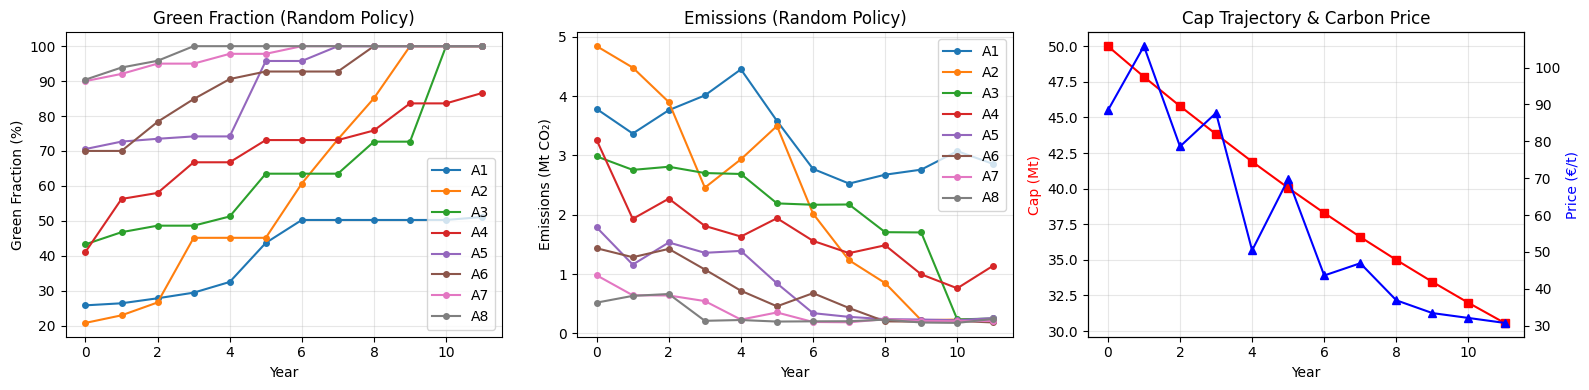

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

ax = axes[0]
for i in range(n_agents):
    ax.plot(df['year'], df[f'green_A{i+1}'] * 100, label=f'A{i+1}', marker='o', ms=4)
ax.set_xlabel('Year'); ax.set_ylabel('Green Fraction (%)')
ax.set_title('Green Fraction (Random Policy)'); ax.legend(); ax.grid(True, alpha=0.3)

ax = axes[1]
for i in range(n_agents):
    ax.plot(df['year'], df[f'emissions_A{i+1}'], label=f'A{i+1}', marker='o', ms=4)
ax.set_xlabel('Year'); ax.set_ylabel('Emissions (Mt CO\u2082)')
ax.set_title('Emissions (Random Policy)'); ax.legend(); ax.grid(True, alpha=0.3)

ax = axes[2]
ax.plot(df['year'], df['cap'], label='Cap (Mt)', marker='s', color='red')
ax2 = ax.twinx()
ax2.plot(df['year'], df['price'], label='Price (\u20ac/t)', marker='^', color='blue')
ax.set_xlabel('Year'); ax.set_ylabel('Cap (Mt)', color='red')
ax2.set_ylabel('Price (\u20ac/t)', color='blue')
ax.set_title('Cap Trajectory & Carbon Price'); ax.grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

## 5. Train PPO Agents (Short Run)

In [7]:
from scripts.train import train_one_seed

train_config = config.copy()
train_config['simulation'] = dict(config['simulation'])
train_config['simulation']['n_episodes'] = 1500
train_config['logging'] = dict(config['logging'])
train_config['logging']['log_interval'] = 50
train_config['logging']['save_interval'] = 100

train_one_seed(train_config, seed=42)


Training — seed 42, 8 learning agents + 8 bots, HAPPO (sequential update, centralized critic), two-phase
v5.1: MAC switching | Electricity revenue | Carry-forward | CF-cap=2.0×
Clipped Gaussian (no tanh) + P1-P8 active | ε-greedy 25%→5%

══════════════════════════════════════════════════════════════════════════════════
  TRAINING CONSOLE — COLUMN GUIDE
══════════════════════════════════════════════════════════════════════════════════

  EPISODE HEADER
    Ep / elapsed / ETA  : Episode number, wall-clock time, estimated remaining
    ent / shp / eps     : Entropy coef, shaping weight, epsilon-greedy
    [ENT-DECAY]         : Entropy decay triggered
    [cyc=Ax]            : Active agent (soft cycling)

  YEAR-BY-YEAR TRAJECTORIES
    Price/yr   : Clearing price each year (€/t), with std dev
    Emiss/yr   : Total emissions each year (Mt), with avg
    Cap/yr     : Cap each year (Mt), with final TNAC

  MARKET & SECONDARY SUMMARY
    comply / green      : Compliance rate, avg green frac

## 6. Quick Results Check

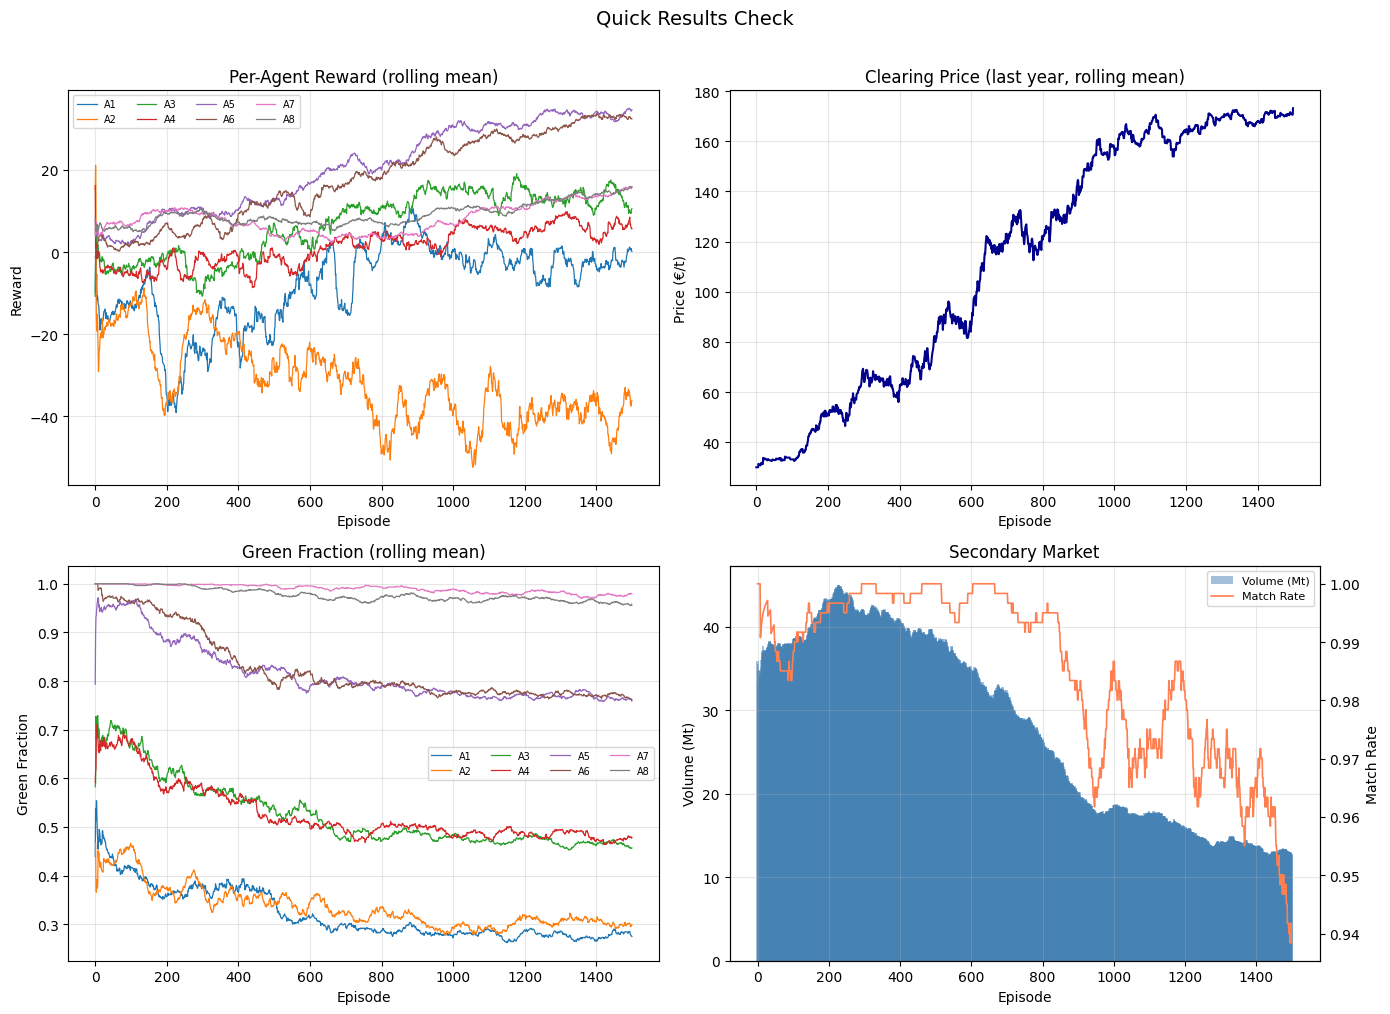

In [8]:
ep_df = pd.read_csv('results/training_log_s42.csv')
yr_df = pd.read_csv('results/year_log_s42.csv')
n_agents = config['companies']['n_agents']
agent_colors = [plt.cm.tab10(i) for i in range(n_agents)]
ROLL = 50

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

ax = axes[0, 0]
for i in range(n_agents):
    ax.plot(ep_df['episode'], ep_df[f'reward_A{i+1}'].rolling(ROLL, min_periods=1).mean(),
            color=agent_colors[i], label=f'A{i+1}', lw=0.9)
ax.set_xlabel('Episode'); ax.set_ylabel('Reward')
ax.set_title('Per-Agent Reward (rolling mean)'); ax.legend(fontsize=7, ncol=4); ax.grid(True, alpha=0.3)

ax = axes[0, 1]
ax.plot(ep_df['episode'], ep_df['clearing_price_last'].rolling(ROLL, min_periods=1).mean(), color='darkblue')
ax.set_xlabel('Episode'); ax.set_ylabel('Price (\u20ac/t)')
ax.set_title('Clearing Price (last year, rolling mean)'); ax.grid(True, alpha=0.3)

ax = axes[1, 0]
for i in range(n_agents):
    ax.plot(ep_df['episode'], ep_df[f'green_frac_A{i+1}'].rolling(ROLL, min_periods=1).mean(),
            color=agent_colors[i], label=f'A{i+1}', lw=0.9)
ax.set_xlabel('Episode'); ax.set_ylabel('Green Fraction')
ax.set_title('Green Fraction (rolling mean)'); ax.legend(fontsize=7, ncol=4); ax.grid(True, alpha=0.3)

ax = axes[1, 1]
ax.bar(ep_df['episode'], ep_df['secondary_volume'].rolling(ROLL, min_periods=1).mean(),
       width=max(1, len(ep_df)//200), alpha=0.5, color='steelblue', label='Volume (Mt)')
ax2 = ax.twinx()
ax2.plot(ep_df['episode'], ep_df['secondary_match_rate'].rolling(ROLL, min_periods=1).mean(),
         color='coral', lw=1.2, label='Match Rate')
ax.set_xlabel('Episode'); ax.set_ylabel('Volume (Mt)'); ax2.set_ylabel('Match Rate')
ax.set_title('Secondary Market'); ax.grid(True, alpha=0.3)
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, fontsize=8)

plt.suptitle('Quick Results Check', fontsize=14, y=1.01)
plt.tight_layout(); plt.show()

## 7. Full Training Run

Run for more episodes to allow agents to develop meaningful strategies.
The analysis sections below are designed for this longer run.

In [9]:
from scripts.train import train_one_seed

full_config = config.copy()
full_config['simulation'] = dict(config['simulation'])
full_config['simulation']['n_episodes'] = 30000
full_config['logging'] = dict(config['logging'])
full_config['logging']['log_interval'] = 100
full_config['logging']['results_dir'] = 'results/'

train_one_seed(full_config, seed=42)

Output streaming troncato alle ultime 5000 righe.
  Bots (8): bid=112€  emiss=2.30 Mt  comply=96/96yr  sec: 8s
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
              Grn     ΔG  Emiss  Alloc    Sf   Bid€  BidMt InvFr │     Rew  Short     Pen   ALoss   CLoss   LΔ │   MAC │            Secondary
  A1 :    20→29%   +9.1   4.39   3.47  0/12    150   6.60 0.012 │     1.7   0.00       0 -0.0670  0.0438    1 │ 0.660 │ B6y/13.3Mt@57€ S4y/5.8Mt@64€
  A2 :    22→33%  +11.0   4.60   5.54  0/12    188   5.54 0.018 │    -1.1   0.00       0 -0.0470  0.0513    1 │ 0.660 │ B1y/2.8Mt@90€ S6y/12.3Mt@56€
  A3 :    41→50%   +8.6   3.00   2.75  0/12    251   4.00 0.023 │    -5.1   0.00       0 -0.1532  0.0433    1 │ 0.306 │ B4y/8.7Mt@81€ S4y/3.2Mt@51€
  A4 :    42→42%   +0.0   3.33   3.41  0/12    134   4.74 0.006 │     4.6   0.00       0 -0.2744  0.0508    1 │ 0.437 │ B3y/4.9Mt@38€ S2y/2.8Mt@43€
  A5 :    71→86%  +14.8   1.06  

---
# Post-Training Analysis

> **Run the data-loading cell below first**, then jump to either part.

| Part | Purpose |
|------|---------|
| **Part I — Diagnostic** | Is the *simulation itself* realistic and mechanically correct? |
| **Part II — Analytical** | What *strategies* did the agents learn? |

In [10]:
# ── Load & Prepare Data (run this first) ─────────────────────────────
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns

ep_df = pd.read_csv('results/training_log_s42.csv')
yr_df = pd.read_csv('results/year_log_s42.csv')
n_agents = config['companies']['n_agents']

sns.set_style('whitegrid')
agent_colors = [plt.cm.tab10(i) for i in range(n_agents)]
_base_archetypes = ['Coal-Heavy', 'Gas-Dominant', 'Mixed', 'Near-Green']
agent_labels = []
for arch in _base_archetypes:
    for k in range(n_agents // 4):
        agent_labels.append(f'A{len(agent_labels)+1} ({arch})')
while len(agent_labels) < n_agents:
    agent_labels.append(f'A{len(agent_labels)+1}')

LAST_N = min(200, len(ep_df) // 4)
last_episodes = ep_df['episode'].unique()[-LAST_N:]
recent_ep = ep_df[ep_df['episode'].isin(last_episodes)].copy()
recent_yr = yr_df[yr_df['episode'].isin(last_episodes)].copy()
ROLL = 50

n_years_per_ep = yr_df.groupby('episode')['year'].count().mode().iloc[0]

print(f'Loaded {len(ep_df)} episodes, {len(yr_df)} year-rows')
print(f'Converged window: last {LAST_N} episodes  |  {n_years_per_ep} years/episode')
print(f'Agents: {n_agents}  |  Archetypes: {agent_labels}')

Loaded 30000 episodes, 360000 year-rows
Converged window: last 200 episodes  |  12 years/episode
Agents: 8  |  Archetypes: ['A1 (Coal-Heavy)', 'A2 (Coal-Heavy)', 'A3 (Gas-Dominant)', 'A4 (Gas-Dominant)', 'A5 (Mixed)', 'A6 (Mixed)', 'A7 (Near-Green)', 'A8 (Near-Green)']


---
# Part I — Diagnostic Analysis

> *Does the simulation produce economically plausible outcomes?*
>
> We check: price levels, cap-emissions alignment, MSR/TNAC dynamics,
> auction & secondary market mechanics, stochastic shocks (P5/P6),
> and training convergence.

### D1. Carbon Price & Cap Schedule

The clearing price should broadly reflect real EU ETS dynamics:
- Phase 4 prices in the €50–100 range
- Prices rising as the cap tightens under the LRF
- TNAC declining over time as MSR absorbs surplus

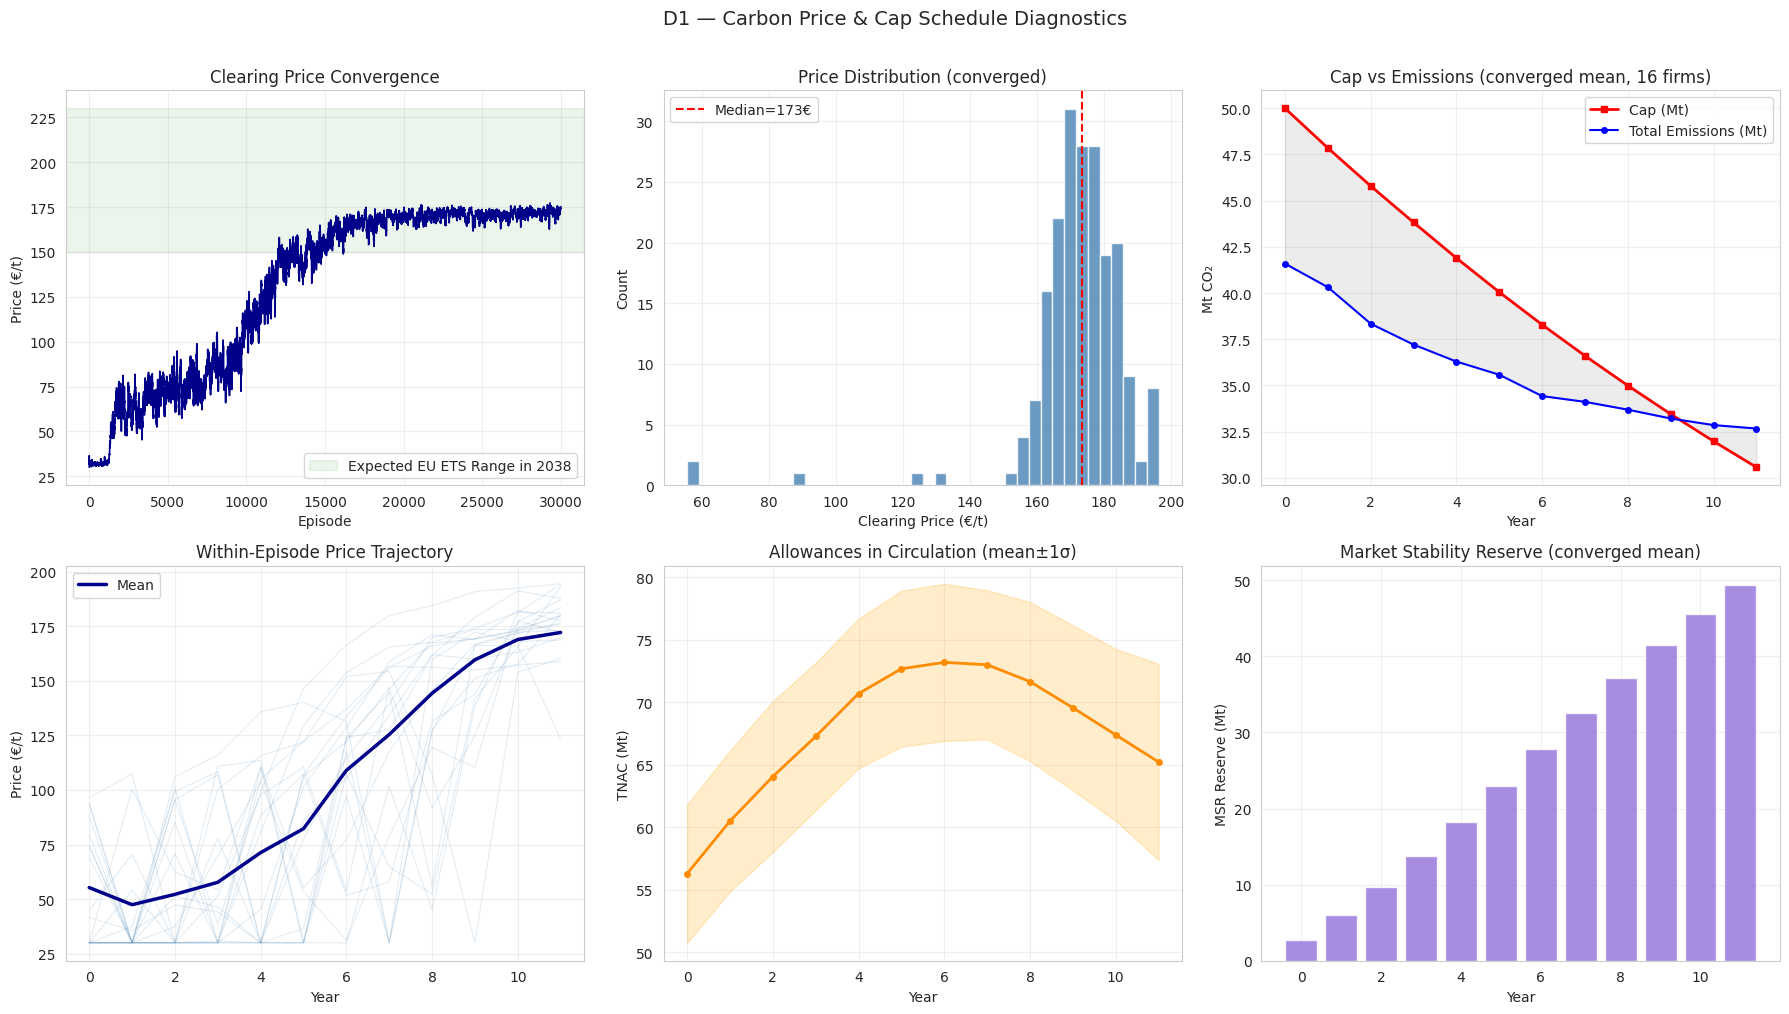

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1 — Clearing price over training
ax = axes[0, 0]
ax.plot(ep_df['episode'], ep_df['clearing_price_last'].rolling(ROLL, min_periods=1).mean(),
    color='darkblue', lw=1.2)
ax.axhspan(150, 230, alpha=0.08, color='green', label='Expected EU ETS Range in 2038')
ax.set_xlabel('Episode'); ax.set_ylabel('Price (€/t)')
ax.set_title('Clearing Price Convergence'); ax.legend(); ax.grid(True, alpha=0.3)

# 2 — Price distribution (converged)
ax = axes[0, 1]
prices_conv = recent_yr.groupby('episode')['clearing_price'].last()
ax.hist(prices_conv, bins=40, color='steelblue', edgecolor='white', alpha=0.8)
ax.axvline(prices_conv.median(), color='red', ls='--', label=f'Median={prices_conv.median():.0f}€')
ax.set_xlabel('Clearing Price (€/t)'); ax.set_ylabel('Count')
ax.set_title('Price Distribution (converged)'); ax.legend(); ax.grid(True, alpha=0.3)

# 3 — Cap schedule vs total emissions (ALL companies incl. bots)
ax = axes[0, 2]
cap_by_yr = recent_yr.groupby('year')['cap'].mean()

emis_cols = sorted(
    [c for c in recent_yr.columns if c.startswith('emissions_A')],
    key=lambda c: int(c.split('_A')[1])
)
total_emis_by_row = recent_yr[emis_cols].sum(axis=1)
emis_by_yr = total_emis_by_row.groupby(recent_yr['year']).mean()

ax.plot(cap_by_yr.index, cap_by_yr.values, 'r-s', ms=5, label='Cap (Mt)', lw=2)
ax.plot(emis_by_yr.index, emis_by_yr.values, 'b-o', ms=4, label='Total Emissions (Mt)', lw=1.5)
ax.fill_between(cap_by_yr.index, cap_by_yr.values, emis_by_yr.values, alpha=0.15, color='gray')
ax.set_xlabel('Year'); ax.set_ylabel('Mt CO₂')
ax.set_title(f'Cap vs Emissions (converged mean, {len(emis_cols)} firms)')
ax.legend(); ax.grid(True, alpha=0.3)

# 4 — Within-episode price trajectory
ax = axes[1, 0]
sample_eps = sorted(recent_yr['episode'].unique()[-20:])
for ep in sample_eps:
    ep_data = recent_yr[recent_yr['episode'] == ep]
    ax.plot(ep_data['year'], ep_data['clearing_price'], color='steelblue', alpha=0.15, lw=0.8)
mean_price_yr = recent_yr.groupby('year')['clearing_price'].mean()
ax.plot(mean_price_yr.index, mean_price_yr.values, 'darkblue', lw=2.5, label='Mean')
ax.set_xlabel('Year'); ax.set_ylabel('Price (€/t)')
ax.set_title('Within-Episode Price Trajectory'); ax.legend(); ax.grid(True, alpha=0.3)

# 5 — TNAC over years
ax = axes[1, 1]
tnac_yr = recent_yr.groupby('year')['tnac'].agg(['mean', 'std'])
std_tnac = tnac_yr['std'].fillna(0.0)
ax.plot(tnac_yr.index, tnac_yr['mean'], 'darkorange', lw=2, marker='o', ms=4)
ax.fill_between(tnac_yr.index, tnac_yr['mean'] - std_tnac, tnac_yr['mean'] + std_tnac,
        alpha=0.2, color='orange')
ax.set_xlabel('Year'); ax.set_ylabel('TNAC (Mt)')
ax.set_title('Allowances in Circulation (mean±1σ)'); ax.grid(True, alpha=0.3)

# 6 — MSR reserve
ax = axes[1, 2]
msr_yr = recent_yr.groupby('year')['msr_reserve'].mean()
ax.bar(msr_yr.index, msr_yr.values, color='mediumpurple', alpha=0.8)
ax.set_xlabel('Year'); ax.set_ylabel('MSR Reserve (Mt)')
ax.set_title('Market Stability Reserve (converged mean)'); ax.grid(True, alpha=0.3)

plt.suptitle('D1 — Carbon Price & Cap Schedule Diagnostics', fontsize=14, y=1.01)
plt.tight_layout(); plt.show()


### D2. Auction Mechanics

Sanity checks for the uniform-price auction:
- Allocations should sum to roughly the auctioned volume
- Bid prices should bracket the clearing price
- No persistent auction failures

/tmp/ipykernel_6324/475511468.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(alloc_data, labels=[f'A{i+1}' for i in range(n_agents)],


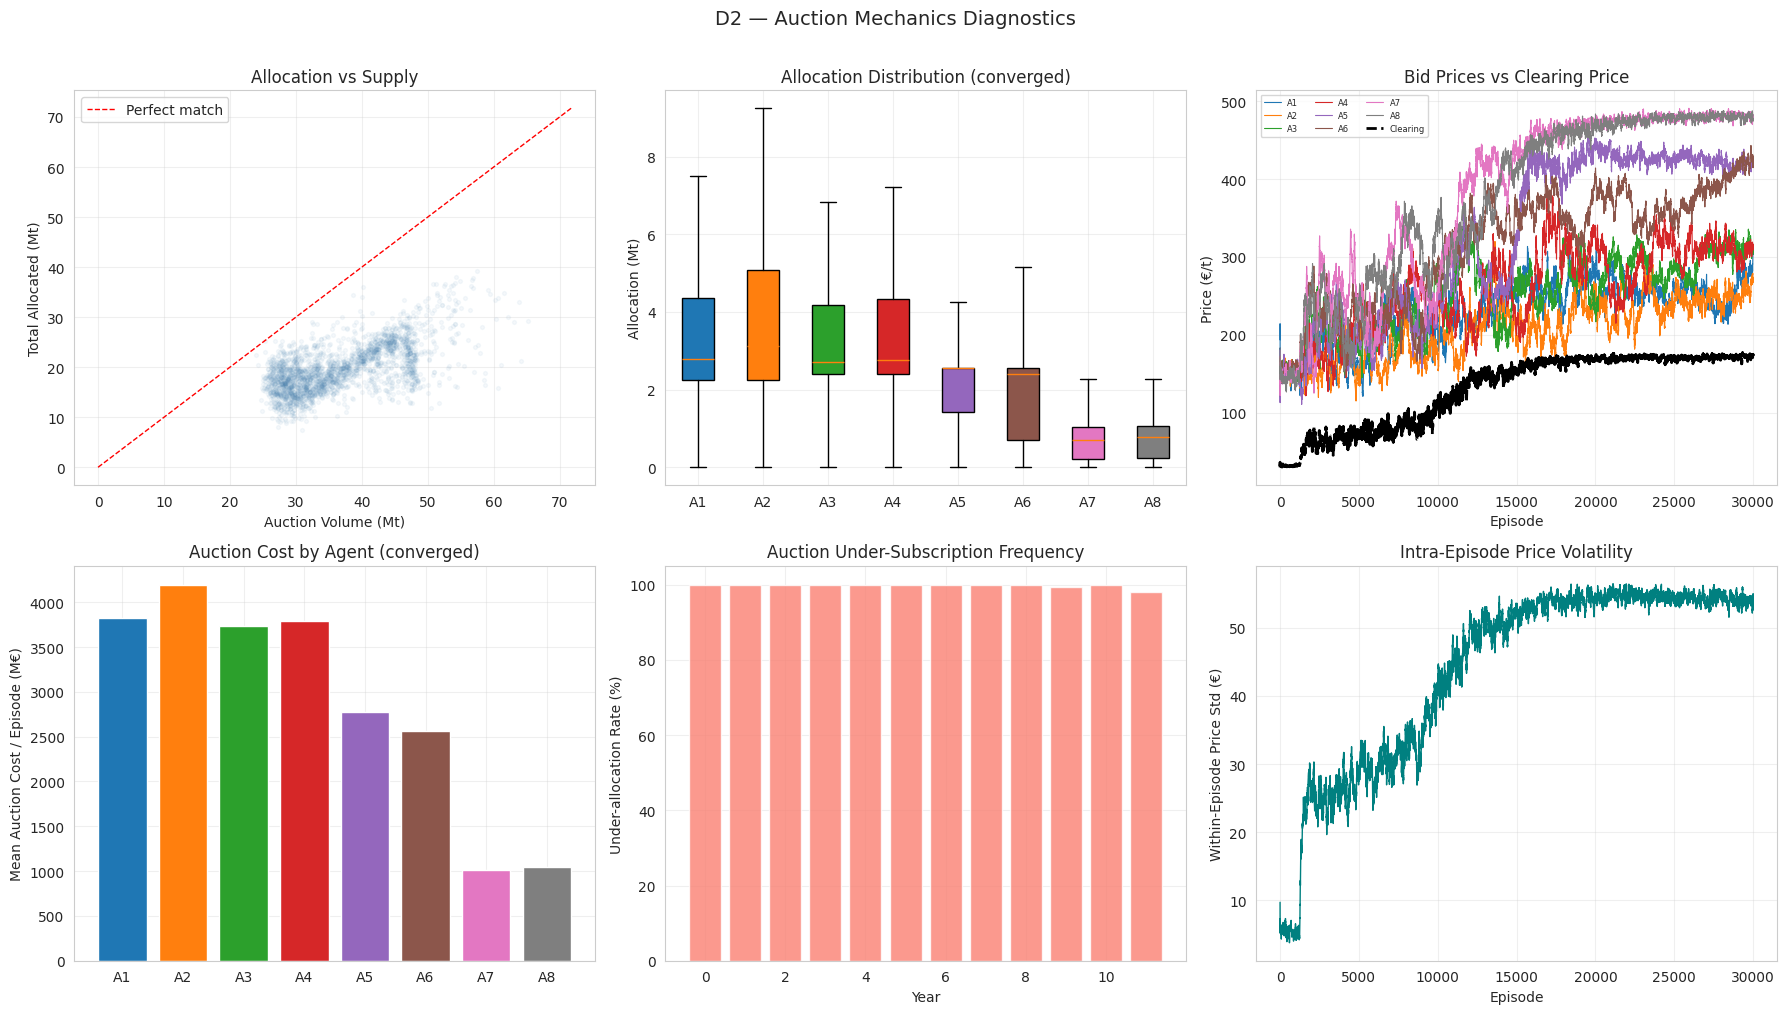

In [12]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1 — Total allocation vs auction volume
ax = axes[0, 0]
alloc_cols = [f'alloc_A{i+1}' for i in range(n_agents)]
alloc_total = recent_yr[alloc_cols].sum(axis=1)
ax.scatter(recent_yr['auction_volume'], alloc_total, alpha=0.05, s=8, color='steelblue')
lims = [0, max(recent_yr['auction_volume'].max(), alloc_total.max()) * 1.1]
ax.plot(lims, lims, 'r--', lw=1, label='Perfect match')
ax.set_xlabel('Auction Volume (Mt)'); ax.set_ylabel('Total Allocated (Mt)')
ax.set_title('Allocation vs Supply'); ax.legend(); ax.grid(True, alpha=0.3)

# 2 — Per-agent allocation distribution
ax = axes[0, 1]
alloc_data = [recent_yr[f'alloc_A{i+1}'].values for i in range(n_agents)]
bp = ax.boxplot(alloc_data, labels=[f'A{i+1}' for i in range(n_agents)],
                patch_artist=True, showfliers=False)
for i, patch in enumerate(bp['boxes']):
    patch.set_facecolor(agent_colors[i])
ax.set_ylabel('Allocation (Mt)'); ax.set_title('Allocation Distribution (converged)')
ax.grid(True, alpha=0.3)

# 3 — Bid price vs clearing price
ax = axes[0, 2]
for i in range(n_agents):
    bid_roll = ep_df[f'bid_price_A{i+1}'].rolling(ROLL, min_periods=1).mean()
    ax.plot(ep_df['episode'], bid_roll, color=agent_colors[i], lw=0.8, label=f'A{i+1}')
clr_roll = ep_df['clearing_price_last'].rolling(ROLL, min_periods=1).mean()
ax.plot(ep_df['episode'], clr_roll, 'k--', lw=2, label='Clearing')
ax.set_xlabel('Episode'); ax.set_ylabel('Price (\u20ac/t)')
ax.set_title('Bid Prices vs Clearing Price'); ax.legend(fontsize=6, ncol=3); ax.grid(True, alpha=0.3)

# 4 — Auction cost per agent (converged)
ax = axes[1, 0]
acost_means = [recent_yr.groupby('episode')[f'auction_cost_A{i+1}'].sum().mean() for i in range(n_agents)]
bars = ax.bar([f'A{i+1}' for i in range(n_agents)], acost_means,
              color=agent_colors)
ax.set_ylabel('Mean Auction Cost / Episode (M\u20ac)')
ax.set_title('Auction Cost by Agent (converged)'); ax.grid(True, alpha=0.3)

# 5 — Under-allocation frequency
ax = axes[1, 1]
# Check how often total allocation < 90% of auction volume
under = alloc_total < 0.9 * recent_yr['auction_volume']
under_rate_yr = under.groupby(recent_yr['year']).mean()
ax.bar(under_rate_yr.index, under_rate_yr.values * 100, color='salmon', alpha=0.8)
ax.set_xlabel('Year'); ax.set_ylabel('Under-allocation Rate (%)')
ax.set_title('Auction Under-Subscription Frequency'); ax.grid(True, alpha=0.3)

# 6 — Price volatility over training
ax = axes[1, 2]
ax.plot(ep_df['episode'], ep_df['price_std'].rolling(ROLL, min_periods=1).mean(),
        color='teal', lw=1)
ax.set_xlabel('Episode'); ax.set_ylabel('Within-Episode Price Std (\u20ac)')
ax.set_title('Intra-Episode Price Volatility'); ax.grid(True, alpha=0.3)

plt.suptitle('D2 \u2014 Auction Mechanics Diagnostics', fontsize=14, y=1.01)
plt.tight_layout(); plt.show()

### D3. Secondary Market Mechanics

Does the double-auction secondary market function properly?
- Reasonable match rates (not all-or-nothing)
- Secondary prices tracking auction prices
- Both buyers and sellers participating

/tmp/ipykernel_6324/1823370206.py:59: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(snet_data, labels=[f'A{i+1}' for i in range(n_agents)],


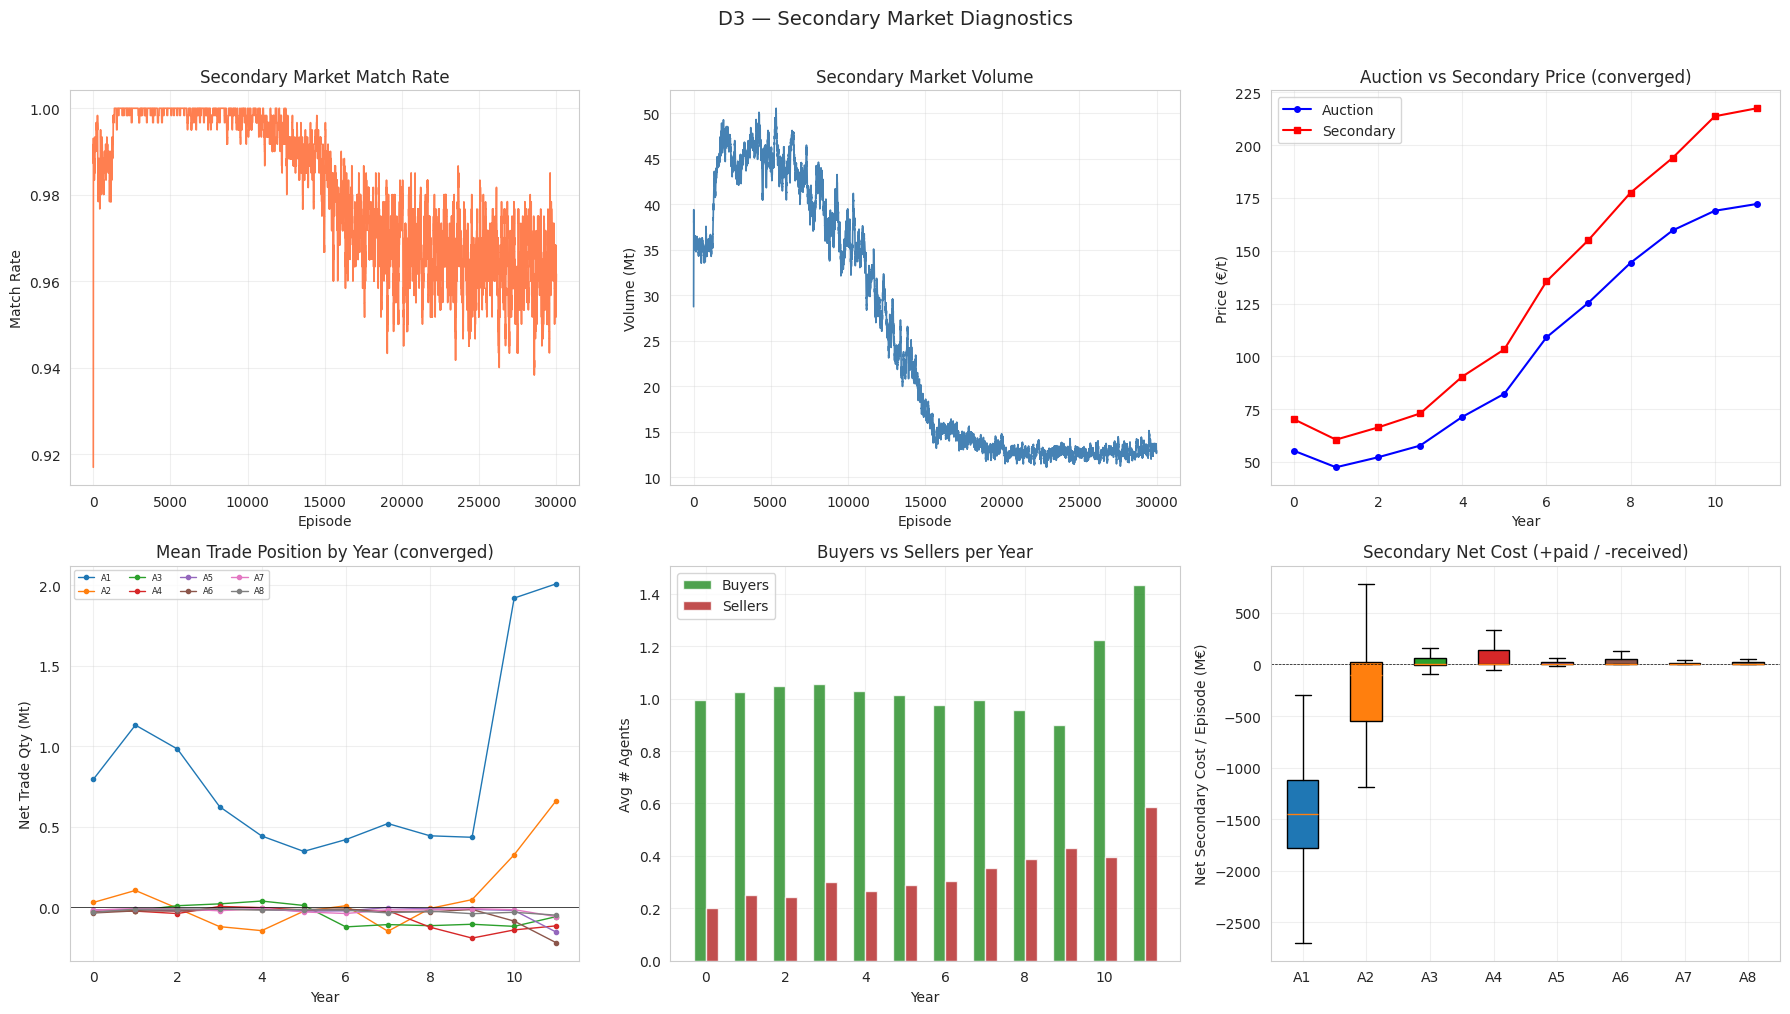

In [13]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1 — Match rate over training
ax = axes[0, 0]
ax.plot(ep_df['episode'], ep_df['secondary_match_rate'].rolling(ROLL, min_periods=1).mean(),
        color='coral', lw=1.2)
ax.set_xlabel('Episode'); ax.set_ylabel('Match Rate')
ax.set_title('Secondary Market Match Rate'); ax.grid(True, alpha=0.3)

# 2 — Secondary volume over training
ax = axes[0, 1]
ax.plot(ep_df['episode'], ep_df['secondary_volume'].rolling(ROLL, min_periods=1).mean(),
        color='steelblue', lw=1.2)
ax.set_xlabel('Episode'); ax.set_ylabel('Volume (Mt)')
ax.set_title('Secondary Market Volume'); ax.grid(True, alpha=0.3)

# 3 — Secondary vs Auction price
ax = axes[0, 2]
sec_mean_yr = recent_yr.groupby('year')['secondary_price'].mean()
auc_mean_yr = recent_yr.groupby('year')['clearing_price'].mean()
ax.plot(auc_mean_yr.index, auc_mean_yr.values, 'b-o', ms=4, label='Auction', lw=1.5)
ax.plot(sec_mean_yr.index, sec_mean_yr.values, 'r-s', ms=4, label='Secondary', lw=1.5)
ax.set_xlabel('Year'); ax.set_ylabel('Price (\u20ac/t)')
ax.set_title('Auction vs Secondary Price (converged)'); ax.legend(); ax.grid(True, alpha=0.3)

# 4 — Net trade by agent by year (who buys/sells)
ax = axes[1, 0]
for i in range(n_agents):
    trade_by_yr = recent_yr.groupby('year')[f'trade_qty_A{i+1}'].mean()
    ax.plot(trade_by_yr.index, trade_by_yr.values, color=agent_colors[i],
            marker='o', ms=3, label=f'A{i+1}', lw=1)
ax.axhline(0, color='black', ls='-', lw=0.5)
ax.set_xlabel('Year'); ax.set_ylabel('Net Trade Qty (Mt)')
ax.set_title('Mean Trade Position by Year (converged)')
ax.legend(fontsize=6, ncol=4); ax.grid(True, alpha=0.3)

# 5 — Buy/sell balance: count of buyers vs sellers per year
ax = axes[1, 1]
buy_count_yr = []
sell_count_yr = []
for yr in range(n_years_per_ep):
    yr_data = recent_yr[recent_yr['year'] == yr]
    n_buy = sum((yr_data[f'trade_qty_A{i+1}'] > 0.01).mean() for i in range(n_agents))
    n_sell = sum((yr_data[f'trade_qty_A{i+1}'] < -0.01).mean() for i in range(n_agents))
    buy_count_yr.append(n_buy)
    sell_count_yr.append(n_sell)
x = np.arange(n_years_per_ep)
ax.bar(x - 0.15, buy_count_yr, 0.3, color='forestgreen', alpha=0.8, label='Buyers')
ax.bar(x + 0.15, sell_count_yr, 0.3, color='firebrick', alpha=0.8, label='Sellers')
ax.set_xlabel('Year'); ax.set_ylabel('Avg # Agents')
ax.set_title('Buyers vs Sellers per Year'); ax.legend(); ax.grid(True, alpha=0.3)

# 6 — Secondary net cost distribution
ax = axes[1, 2]
snet_data = []
for i in range(n_agents):
    ep_snet = recent_yr.groupby('episode')[f'secondary_net_A{i+1}'].sum()
    snet_data.append(ep_snet.values)
bp = ax.boxplot(snet_data, labels=[f'A{i+1}' for i in range(n_agents)],
                patch_artist=True, showfliers=False)
for i, patch in enumerate(bp['boxes']):
    patch.set_facecolor(agent_colors[i])
ax.axhline(0, color='black', ls='--', lw=0.5)
ax.set_ylabel('Net Secondary Cost / Episode (M\u20ac)')
ax.set_title('Secondary Net Cost (+paid / -received)')
ax.grid(True, alpha=0.3)

plt.suptitle('D3 \u2014 Secondary Market Diagnostics', fontsize=14, y=1.01)
plt.tight_layout(); plt.show()

### D4. Stochastic Shocks (P5 & P6)

Verify that emission demand shocks (P5) and construction uncertainty (P6) are
active and producing the intended distributions.

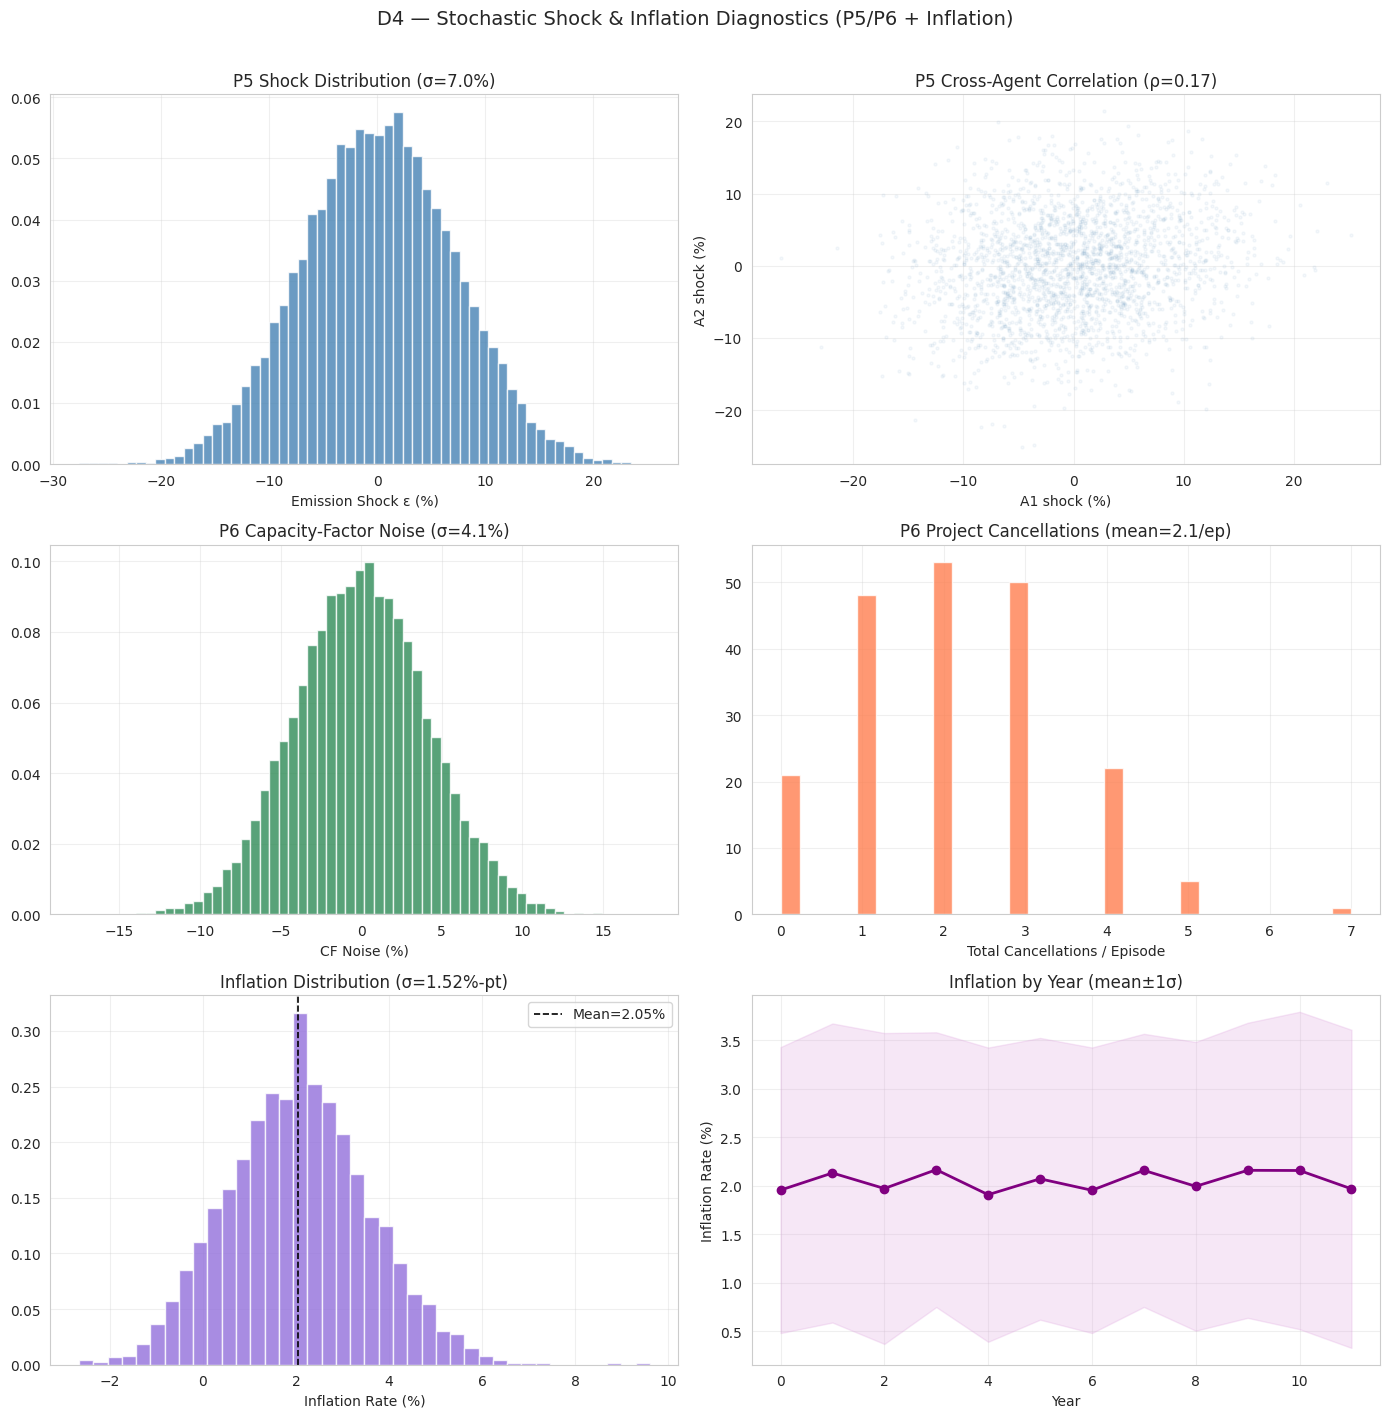

P5 emission shock active: True
P6 CF-noise active:       True
P6 cancellation active:   True
Inflation logged:         True
Inflation mean:           2.050%
Inflation std:            1.515%-pt


In [14]:
fig, axes = plt.subplots(3, 2, figsize=(14, 14))

shock_cols = [f'emission_shock_A{i+1}' for i in range(n_agents)]
cf_cols = [f'cf_shock_A{i+1}' for i in range(n_agents)]
cancel_cols = [f'cancellation_A{i+1}' for i in range(n_agents)]

has_shocks = any(c in recent_yr.columns for c in shock_cols) and recent_yr[shock_cols[0]].std() > 1e-6

# 1 — P5 shock distribution
ax = axes[0, 0]
if has_shocks:
    all_shocks = pd.concat([recent_yr[c] * 100 for c in shock_cols if c in recent_yr.columns])
    ax.hist(all_shocks, bins=60, color='steelblue', edgecolor='white', alpha=0.8, density=True)
    ax.set_xlabel('Emission Shock ε (%)')
    ax.set_title(f'P5 Shock Distribution (σ={all_shocks.std():.1f}%)')
else:
    ax.text(0.5, 0.5, 'P5 shocks inactive', ha='center', va='center', transform=ax.transAxes)
    ax.set_title('P5 — Inactive')
ax.grid(True, alpha=0.3)

# 2 — P5 cross-agent correlation
ax = axes[0, 1]
if has_shocks and n_agents >= 2:
    s1 = recent_yr[shock_cols[0]] * 100
    s2 = recent_yr[shock_cols[1]] * 100
    ax.scatter(s1, s2, alpha=0.05, s=5, color='steelblue')
    corr = s1.corr(s2)
    ax.set_xlabel('A1 shock (%)'); ax.set_ylabel('A2 shock (%)')
    ax.set_title(f'P5 Cross-Agent Correlation (ρ={corr:.2f})')
else:
    ax.text(0.5, 0.5, 'P5 inactive or <2 agents', ha='center', va='center', transform=ax.transAxes)
ax.grid(True, alpha=0.3)

# 3 — P6 CF noise
ax = axes[1, 0]
has_cf = any(c in recent_yr.columns for c in cf_cols) and recent_yr[cf_cols[0]].std() > 1e-8
if has_cf:
    all_cf = pd.concat([recent_yr[c] * 100 for c in cf_cols if c in recent_yr.columns])
    ax.hist(all_cf, bins=60, color='seagreen', edgecolor='white', alpha=0.8, density=True)
    ax.set_xlabel('CF Noise (%)')
    ax.set_title(f'P6 Capacity-Factor Noise (σ={all_cf.std():.1f}%)')
else:
    ax.text(0.5, 0.5, 'P6 CF-noise inactive', ha='center', va='center', transform=ax.transAxes)
    ax.set_title('P6 CF — Inactive')
ax.grid(True, alpha=0.3)

# 4 — P6 cancellations
ax = axes[1, 1]
has_cancel = any(c in recent_yr.columns for c in cancel_cols) and recent_yr[cancel_cols[0]].sum() > 0
if has_cancel:
    cancel_per_ep = recent_yr.groupby('episode')[cancel_cols].sum().sum(axis=1)
    ax.hist(cancel_per_ep, bins=30, color='coral', edgecolor='white', alpha=0.8)
    ax.set_xlabel('Total Cancellations / Episode')
    ax.set_title(f'P6 Project Cancellations (mean={cancel_per_ep.mean():.1f}/ep)')
else:
    ax.text(0.5, 0.5, 'P6 cancellations inactive', ha='center', va='center', transform=ax.transAxes)
    ax.set_title('P6 Cancellations — Inactive')
ax.grid(True, alpha=0.3)

# 5 — Inflation rate distribution
ax = axes[2, 0]
has_infl = 'inflation_rate' in recent_yr.columns and recent_yr['inflation_rate'].notna().any()
if has_infl:
    infl_pct = recent_yr['inflation_rate'] * 100
    ax.hist(infl_pct, bins=40, color='mediumpurple', edgecolor='white', alpha=0.8, density=True)
    ax.axvline(infl_pct.mean(), color='black', ls='--', lw=1.2, label=f'Mean={infl_pct.mean():.2f}%')
    ax.set_xlabel('Inflation Rate (%)')
    ax.set_title(f'Inflation Distribution (σ={infl_pct.std():.2f}%-pt)')
    ax.legend()
else:
    ax.text(0.5, 0.5, 'Inflation not logged in year_log', ha='center', va='center', transform=ax.transAxes)
    ax.set_title('Inflation — Not Available')
ax.grid(True, alpha=0.3)

# 6 — Inflation profile by year
ax = axes[2, 1]
if has_infl:
    infl_by_year = recent_yr.groupby('year')['inflation_rate'].agg(['mean', 'std']) * 100
    ax.plot(infl_by_year.index, infl_by_year['mean'], color='purple', marker='o', lw=2)
    std_fill = infl_by_year['std'].fillna(0.0)
    ax.fill_between(
        infl_by_year.index,
        infl_by_year['mean'] - std_fill,
        infl_by_year['mean'] + std_fill,
        color='plum', alpha=0.25
    )
    ax.set_xlabel('Year')
    ax.set_ylabel('Inflation Rate (%)')
    ax.set_title('Inflation by Year (mean±1σ)')
else:
    ax.text(0.5, 0.5, 'Inflation not logged in year_log', ha='center', va='center', transform=ax.transAxes)
    ax.set_title('Inflation by Year — Not Available')
ax.grid(True, alpha=0.3)

plt.suptitle('D4 — Stochastic Shock & Inflation Diagnostics (P5/P6 + Inflation)', fontsize=14, y=1.01)
plt.tight_layout(); plt.show()

# Summary
print(f'P5 emission shock active: {has_shocks}')
print(f'P6 CF-noise active:       {has_cf}')
print(f'P6 cancellation active:   {has_cancel}')
print(f'Inflation logged:         {has_infl}')
if has_infl:
    infl_pct = recent_yr['inflation_rate'] * 100
    print(f'Inflation mean:           {infl_pct.mean():.3f}%')
    print(f'Inflation std:            {infl_pct.std():.3f}%-pt')

### D5. Compliance & Penalty Mechanics

Verify that compliance mechanics work:
- Shortfalls are detected and penalized
- Penalties are proportional to shortfall
- Banking (carry-over) functions correctly

/tmp/ipykernel_6324/2704993469.py:35: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(surp_data, labels=[f'A{i+1}' for i in range(n_agents)],


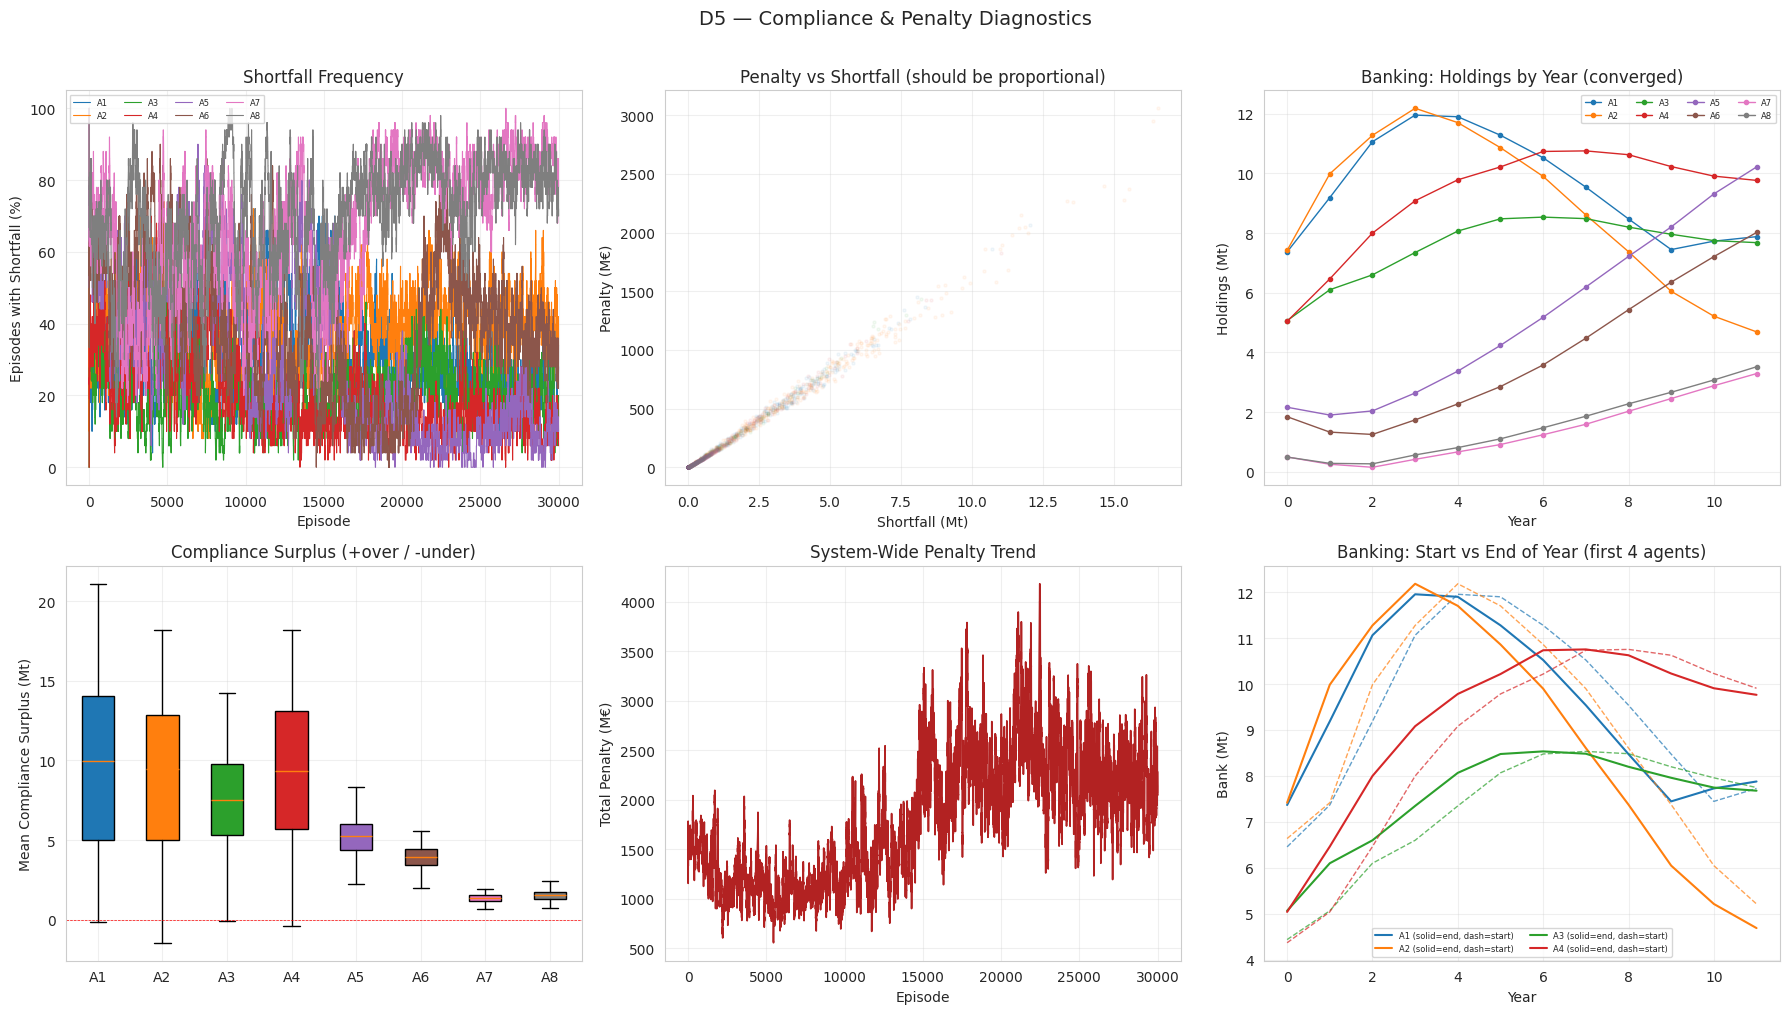

In [15]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1 — Shortfall rate over training
ax = axes[0, 0]
for i in range(n_agents):
    sf = (ep_df[f'shortfall_A{i+1}'] > 1e-6).astype(float).rolling(ROLL, min_periods=1).mean()
    ax.plot(ep_df['episode'], sf * 100, color=agent_colors[i], lw=0.8, label=f'A{i+1}')
ax.set_xlabel('Episode'); ax.set_ylabel('Episodes with Shortfall (%)')
ax.set_title('Shortfall Frequency'); ax.legend(fontsize=6, ncol=4); ax.grid(True, alpha=0.3)

# 2 — Penalty vs shortfall (should be correlated)
ax = axes[0, 1]
for i in range(n_agents):
    ax.scatter(recent_yr[f'shortfall_A{i+1}'], recent_yr[f'penalty_A{i+1}'],
               alpha=0.05, s=5, color=agent_colors[i], label=f'A{i+1}')
ax.set_xlabel('Shortfall (Mt)'); ax.set_ylabel('Penalty (M\u20ac)')
ax.set_title('Penalty vs Shortfall (should be proportional)')
ax.grid(True, alpha=0.3)

# 3 — Holdings by year (banking)
ax = axes[0, 2]
for i in range(n_agents):
    hold_yr = recent_yr.groupby('year')[f'holdings_A{i+1}'].mean()
    ax.plot(hold_yr.index, hold_yr.values, color=agent_colors[i], marker='o', ms=3,
            label=f'A{i+1}', lw=1)
ax.set_xlabel('Year'); ax.set_ylabel('Holdings (Mt)')
ax.set_title('Banking: Holdings by Year (converged)')
ax.legend(fontsize=6, ncol=4); ax.grid(True, alpha=0.3)

# 4 — Compliance surplus distribution
ax = axes[1, 0]
if f'compliance_surplus_A1' in recent_yr.columns:
    surp_data = [recent_yr.groupby('episode')[f'compliance_surplus_A{i+1}'].mean().values
                 for i in range(n_agents)]
    bp = ax.boxplot(surp_data, labels=[f'A{i+1}' for i in range(n_agents)],
                    patch_artist=True, showfliers=False)
    for i, patch in enumerate(bp['boxes']):
        patch.set_facecolor(agent_colors[i])
    ax.axhline(0, color='red', ls='--', lw=0.5)
    ax.set_ylabel('Mean Compliance Surplus (Mt)')
    ax.set_title('Compliance Surplus (+over / -under)')
else:
    ax.text(0.5, 0.5, 'compliance_surplus not logged', ha='center', va='center',
            transform=ax.transAxes)
ax.grid(True, alpha=0.3)

# 5 — Total penalty over training
ax = axes[1, 1]
pen_cols = [f'penalty_A{i+1}' for i in range(n_agents)]
total_pen = ep_df[pen_cols].sum(axis=1)
ax.plot(ep_df['episode'], total_pen.rolling(ROLL, min_periods=1).mean(), color='firebrick', lw=1.2)
ax.set_xlabel('Episode'); ax.set_ylabel('Total Penalty (M\u20ac)')
ax.set_title('System-Wide Penalty Trend'); ax.grid(True, alpha=0.3)

# 6 — Carry-forward: bank_end vs bank_start
ax = axes[1, 2]
if 'bank_end_A1' in recent_yr.columns and 'bank_start_A1' in recent_yr.columns:
    for i in range(min(4, n_agents)):
        bs = recent_yr.groupby('year')[f'bank_start_A{i+1}'].mean()
        be = recent_yr.groupby('year')[f'bank_end_A{i+1}'].mean()
        ax.plot(bs.index, bs.values, color=agent_colors[i], ls='--', lw=1, alpha=0.7)
        ax.plot(be.index, be.values, color=agent_colors[i], ls='-', lw=1.5,
                label=f'A{i+1} (solid=end, dash=start)')
    ax.set_xlabel('Year'); ax.set_ylabel('Bank (Mt)')
    ax.set_title('Banking: Start vs End of Year (first 4 agents)')
    ax.legend(fontsize=6, ncol=2)
else:
    ax.text(0.5, 0.5, 'bank_end not logged', ha='center', va='center', transform=ax.transAxes)
ax.grid(True, alpha=0.3)

plt.suptitle('D5 \u2014 Compliance & Penalty Diagnostics', fontsize=14, y=1.01)
plt.tight_layout(); plt.show()

### D6. Training Convergence

Check that neural networks are learning stably:
- Losses decreasing
- Entropy decay triggered at the right time
- Rewards stabilizing

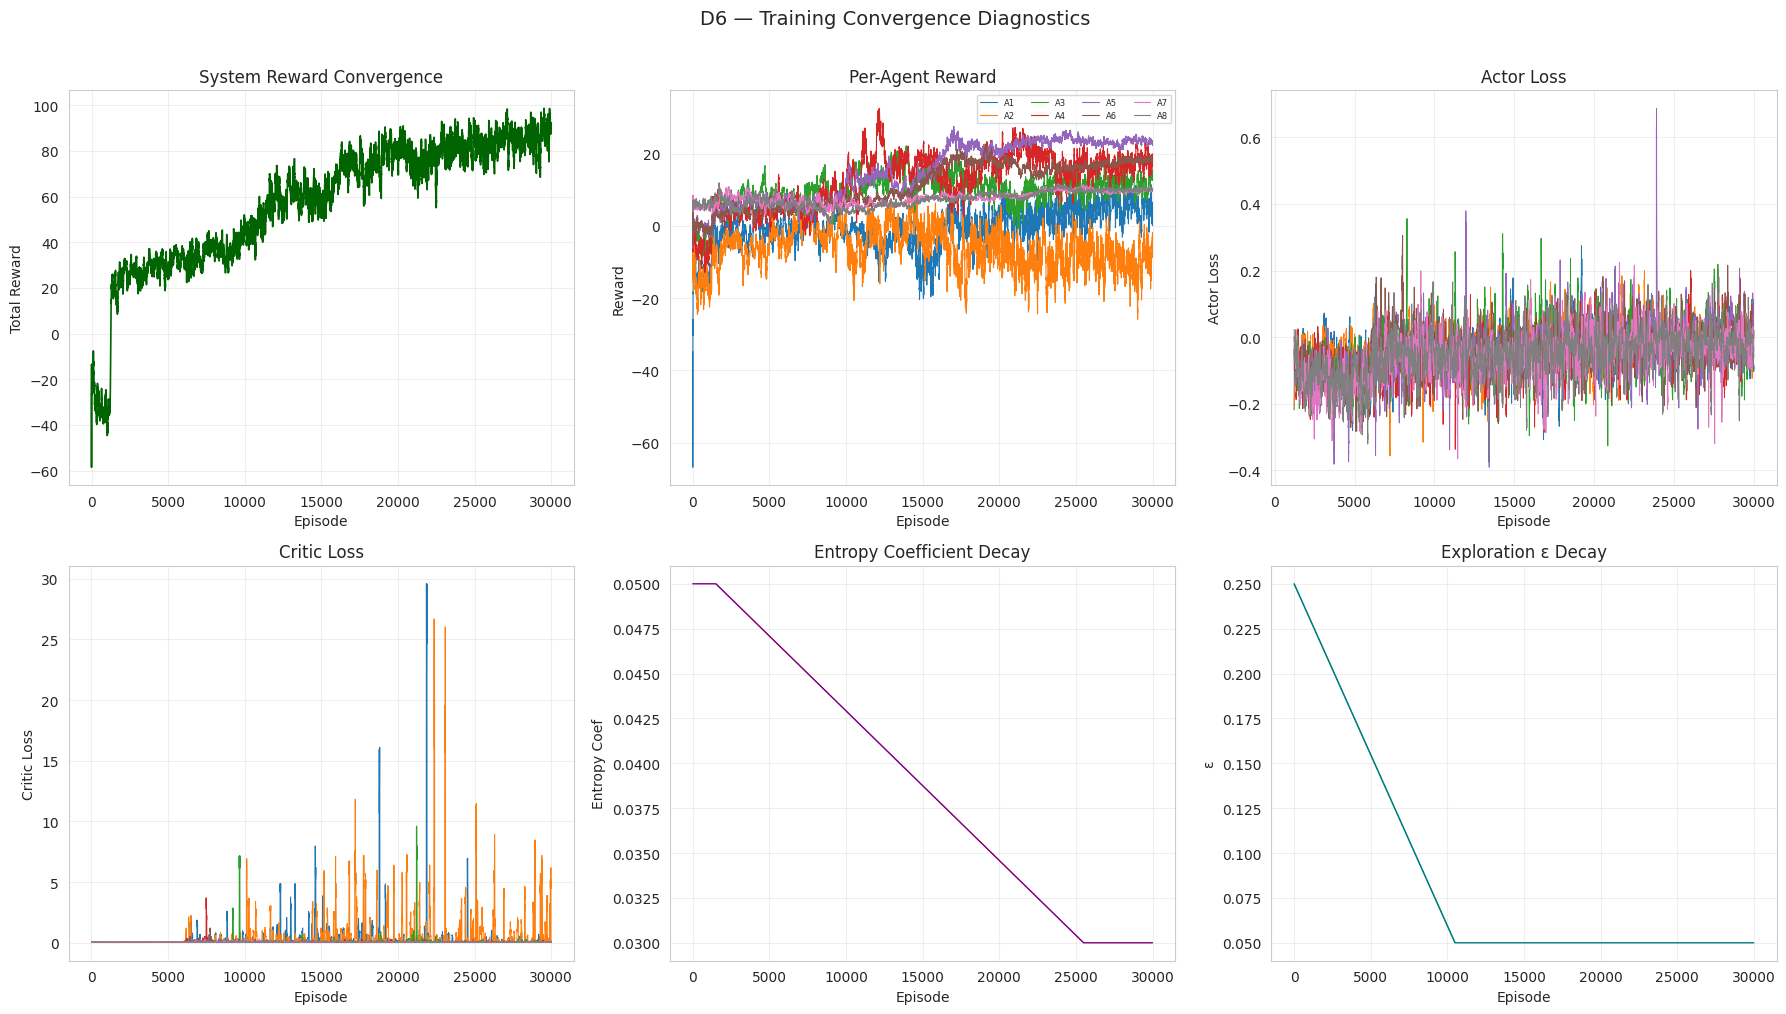

In [16]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1 — Total reward
ax = axes[0, 0]
rew_cols = [f'reward_A{i+1}' for i in range(n_agents)]
total_rew = ep_df[rew_cols].sum(axis=1)
ax.plot(ep_df['episode'], total_rew.rolling(ROLL, min_periods=1).mean(), color='darkgreen', lw=1.2)
ax.set_xlabel('Episode'); ax.set_ylabel('Total Reward')
ax.set_title('System Reward Convergence'); ax.grid(True, alpha=0.3)

# 2 — Per-agent reward
ax = axes[0, 1]
for i in range(n_agents):
    ax.plot(ep_df['episode'], ep_df[f'reward_A{i+1}'].rolling(ROLL, min_periods=1).mean(),
            color=agent_colors[i], lw=0.8, label=f'A{i+1}')
ax.set_xlabel('Episode'); ax.set_ylabel('Reward')
ax.set_title('Per-Agent Reward'); ax.legend(fontsize=6, ncol=4); ax.grid(True, alpha=0.3)

# 3 — Actor loss
ax = axes[0, 2]
for i in range(n_agents):
    col = f'actor_loss_A{i+1}'
    if col in ep_df.columns:
        vals = ep_df[col].replace(0, np.nan).rolling(ROLL, min_periods=1).mean()
        ax.plot(ep_df['episode'], vals, color=agent_colors[i], lw=0.7)
ax.set_xlabel('Episode'); ax.set_ylabel('Actor Loss')
ax.set_title('Actor Loss'); ax.grid(True, alpha=0.3)

# 4 — Critic loss
ax = axes[1, 0]
for i in range(n_agents):
    col = f'critic_loss_A{i+1}'
    if col in ep_df.columns:
        vals = ep_df[col].replace(0, np.nan).rolling(ROLL, min_periods=1).mean()
        ax.plot(ep_df['episode'], vals, color=agent_colors[i], lw=0.7)
ax.set_xlabel('Episode'); ax.set_ylabel('Critic Loss')
ax.set_title('Critic Loss'); ax.grid(True, alpha=0.3)

# 5 — Entropy coefficient
ax = axes[1, 1]
ax.plot(ep_df['episode'], ep_df['entropy_coef'], color='purple', lw=1)
ax.set_xlabel('Episode'); ax.set_ylabel('Entropy Coef')
ax.set_title('Entropy Coefficient Decay'); ax.grid(True, alpha=0.3)

# 6 — Epsilon
ax = axes[1, 2]
ax.plot(ep_df['episode'], ep_df['epsilon'], color='teal', lw=1)
ax.set_xlabel('Episode'); ax.set_ylabel('\u03b5')
ax.set_title('Exploration \u03b5 Decay'); ax.grid(True, alpha=0.3)

plt.suptitle('D6 \u2014 Training Convergence Diagnostics', fontsize=14, y=1.01)
plt.tight_layout(); plt.show()

### D7. Green Investing

Overall green investment behavior across training (trend, distribution, and efficiency).

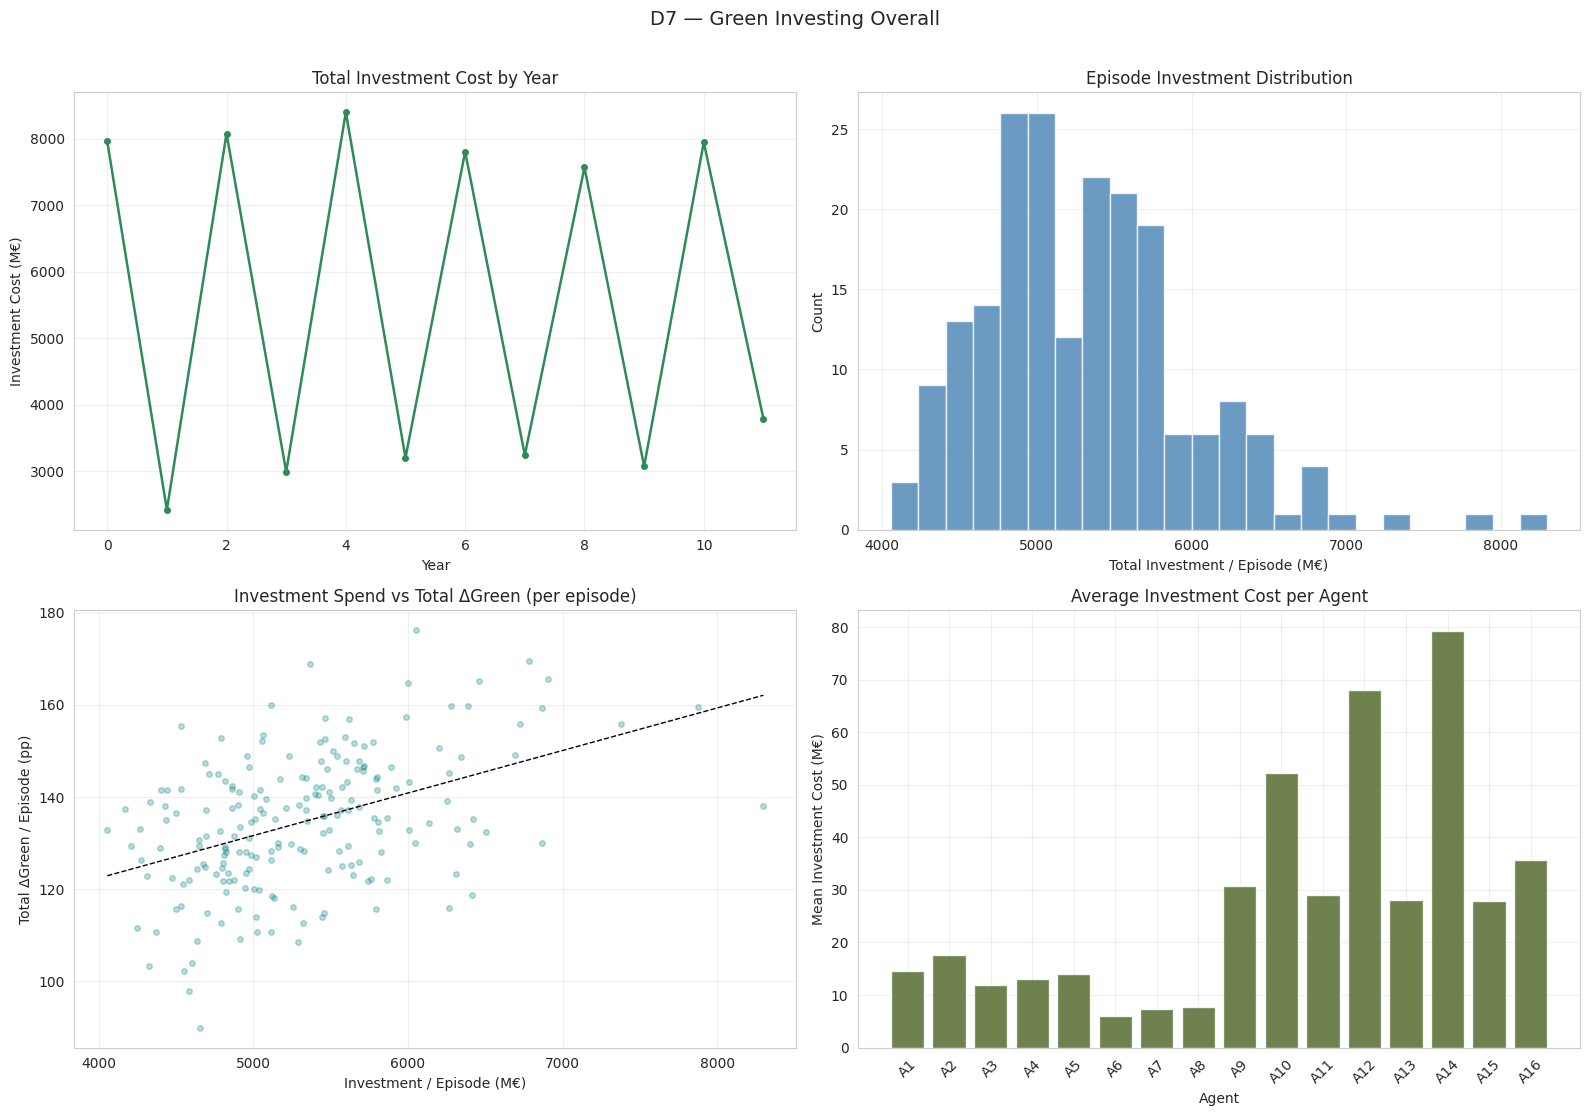

D7 SUMMARY — GREEN INVESTING OVERALL
Mean investment / episode: 5320.10 M€
Median investment / episode: 5251.25 M€
P90 investment / episode: 6263.76 M€
Corr(episode investment, episode Δgreen): 0.436


In [17]:
# ── D7: Green Investing   ───────────────────────────
reward_cols_all = sorted(
    [c for c in recent_yr.columns if c.startswith('reward_A')],
    key=lambda x: int(x.split('_A')[1])
)
n_logged = max(int(c.split('_A')[1]) for c in reward_cols_all) if reward_cols_all else n_agents
agent_ids_logged = list(range(1, n_logged + 1))

invest_cols = [f'invest_cost_A{i}' for i in agent_ids_logged if f'invest_cost_A{i}' in recent_yr.columns]
dgreen_cols = [f'delta_green_A{i}' for i in agent_ids_logged if f'delta_green_A{i}' in recent_yr.columns]

fig, axes = plt.subplots(2, 2, figsize=(16, 11))

# 1) System investment trend by year
ax = axes[0, 0]
if invest_cols:
    invest_by_year = recent_yr.groupby('year')[invest_cols].sum().mean(axis=1)
    ax.plot(invest_by_year.index, invest_by_year.values, 'o-', color='seagreen', lw=1.8, ms=4)
    ax.set_title('Total Investment Cost by Year')
else:
    ax.text(0.5, 0.5, 'Investment columns not available', ha='center', va='center', transform=ax.transAxes)
ax.set_xlabel('Year'); ax.set_ylabel('Investment Cost (M€)'); ax.grid(True, alpha=0.3)

# 2) Investment distribution per episode
ax = axes[0, 1]
if invest_cols:
    ep_invest = recent_yr.groupby('episode')[invest_cols].sum().sum(axis=1)
    ax.hist(ep_invest.values, bins=24, color='steelblue', alpha=0.8, edgecolor='white')
    ax.set_title('Episode Investment Distribution')
else:
    ax.text(0.5, 0.5, 'Investment columns not available', ha='center', va='center', transform=ax.transAxes)
ax.set_xlabel('Total Investment / Episode (M€)'); ax.set_ylabel('Count'); ax.grid(True, alpha=0.3)

# 3) Investment vs greening efficiency
ax = axes[1, 0]
if invest_cols and dgreen_cols:
    ep_invest = recent_yr.groupby('episode')[invest_cols].sum().sum(axis=1)
    ep_dgreen = recent_yr.groupby('episode')[dgreen_cols].sum().sum(axis=1) * 100
    ax.scatter(ep_invest, ep_dgreen, alpha=0.28, s=16, color='teal')
    if len(ep_invest) > 2:
        m = np.polyfit(ep_invest.values, ep_dgreen.values, 1)
        xfit = np.linspace(ep_invest.min(), ep_invest.max(), 60)
        ax.plot(xfit, m[0] * xfit + m[1], 'k--', lw=1)
    ax.set_title('Investment Spend vs Total ΔGreen (per episode)')
else:
    ax.text(0.5, 0.5, 'Need invest_cost + delta_green logs', ha='center', va='center', transform=ax.transAxes)
ax.set_xlabel('Investment / Episode (M€)'); ax.set_ylabel('Total ΔGreen / Episode (pp)'); ax.grid(True, alpha=0.3)

# 4) Mean investment by agent
ax = axes[1, 1]
if invest_cols:
    per_agent_inv = []
    labels = []
    for i in agent_ids_logged:
        col = f'invest_cost_A{i}'
        if col in recent_yr.columns:
            per_agent_inv.append(recent_yr[col].mean())
            labels.append(f'A{i}')
    x = np.arange(len(labels))
    ax.bar(x, per_agent_inv, color='darkolivegreen', alpha=0.85)
    ax.set_xticks(x); ax.set_xticklabels(labels, rotation=45)
    ax.set_title('Average Investment Cost per Agent')
else:
    ax.text(0.5, 0.5, 'Investment columns not available', ha='center', va='center', transform=ax.transAxes)
ax.set_xlabel('Agent'); ax.set_ylabel('Mean Investment Cost (M€)'); ax.grid(True, alpha=0.3)

plt.suptitle('D7 — Green Investing Overall', fontsize=14, y=1.01)
plt.tight_layout(); plt.show()

print('=' * 110)
print('D7 SUMMARY — GREEN INVESTING OVERALL')
print('=' * 110)
if invest_cols:
    ep_invest = recent_yr.groupby('episode')[invest_cols].sum().sum(axis=1)
    print(f'Mean investment / episode: {ep_invest.mean():.2f} M€')
    print(f'Median investment / episode: {ep_invest.median():.2f} M€')
    print(f'P90 investment / episode: {ep_invest.quantile(0.90):.2f} M€')
if invest_cols and dgreen_cols:
    ep_dgreen = recent_yr.groupby('episode')[dgreen_cols].sum().sum(axis=1)
    corr_inv_green = ep_invest.corr(ep_dgreen) if len(ep_invest) > 1 else np.nan
    print(f'Corr(episode investment, episode Δgreen): {corr_inv_green:.3f}')

### D8. Final-Year Invested Assets, Queue State, and Liquidation Payoff

> This cell now prioritizes liquidation values logged directly from the environment reward computation into year_log CSV.

> Fallback behavior:
> - If `terminal_*_value_A*` columns are absent (older logs), bank liquidation is reconstructed from bank_end × clearing_price / 1000.
> - Queue liquidation is shown only if logged columns exist.

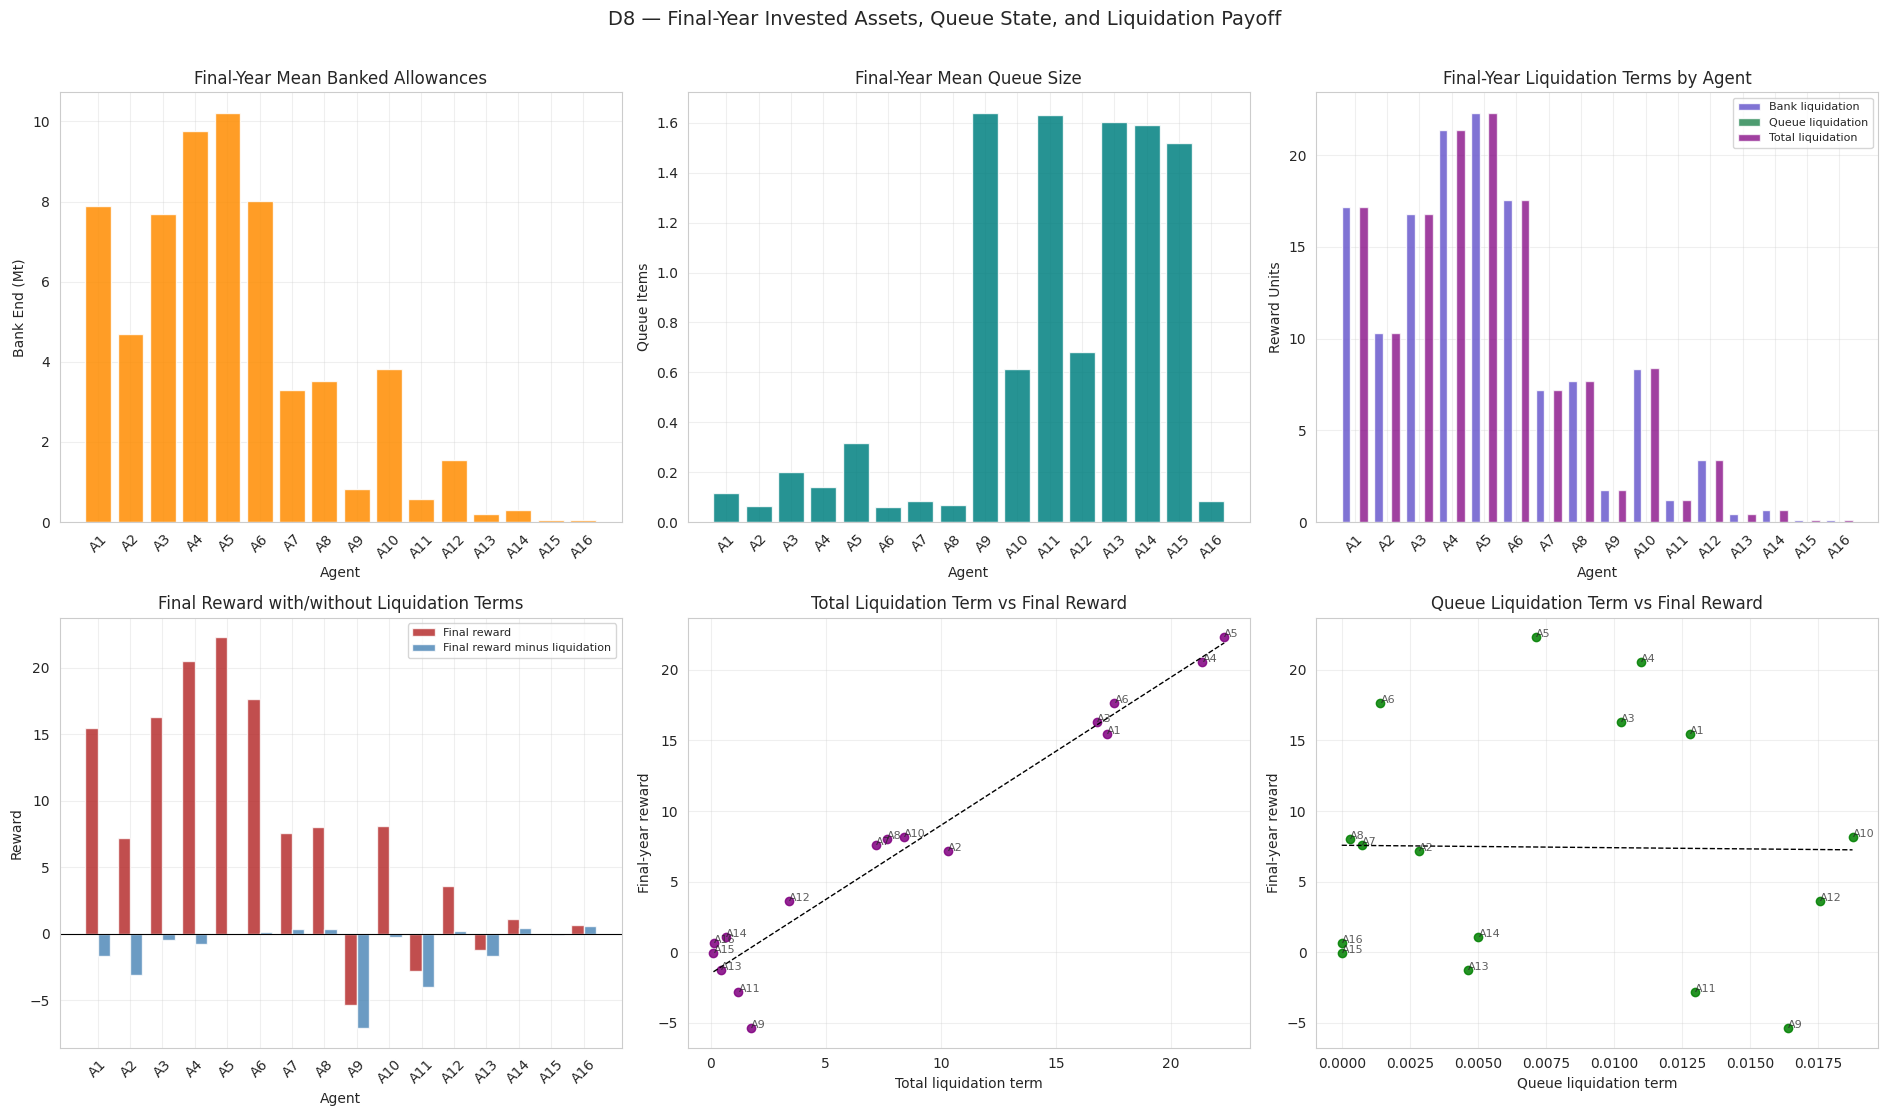

D8 SUMMARY — FINAL-YEAR INVESTED ASSETS, QUEUE STATE, AND LIQUIDATION PAYOFF
terminal_bank_value enabled (config): True
terminal_queue_value enabled (config): True
terminal_payoff_years: 5, gamma: 0.99
Liquidation source: logged terminal_*_value columns
Final-year system reward: 119.14
Pre-final mean system reward: -3.92
Final-year payoff uplift: +123.06
Final-year total bank_end (mean over episodes): 62.46 Mt
Final-year total queue size (mean over episodes): 10.41
Final-year total investment cost (mean over episodes): 303.18 M€
Final-year total liquidation term (mean over episodes): 136.494
 - Bank component: 136.372
 - Queue component: 0.122


In [18]:
# ── D8: Final-Year Invested Assets, Queue State, and Liquidation Payoff ─────
reward_cols_all = sorted(
    [c for c in recent_yr.columns if c.startswith('reward_A')],
    key=lambda x: int(x.split('_A')[1])
)
n_logged = max(int(c.split('_A')[1]) for c in reward_cols_all) if reward_cols_all else n_agents
agent_ids_logged = list(range(1, n_logged + 1))

reward_cols = [f'reward_A{i}' for i in agent_ids_logged if f'reward_A{i}' in recent_yr.columns]
invest_cols = [f'invest_cost_A{i}' for i in agent_ids_logged if f'invest_cost_A{i}' in recent_yr.columns]
bank_cols = [f'bank_end_A{i}' for i in agent_ids_logged if f'bank_end_A{i}' in recent_yr.columns]
queue_cols = [f'queue_size_A{i}' for i in agent_ids_logged if f'queue_size_A{i}' in recent_yr.columns]

reward_cfg = config.get('reward', {}) if isinstance(config, dict) else {}
terminal_bank_enabled = bool(reward_cfg.get('terminal_bank_value', False))
terminal_queue_enabled = bool(reward_cfg.get('terminal_queue_value', False))
terminal_payoff_years = reward_cfg.get('terminal_payoff_years', 5)
gamma_discount = config.get('ppo', {}).get('gamma', 0.99) if isinstance(config, dict) else 0.99

y_last = int(recent_yr['year'].max())
final_slice = recent_yr[recent_yr['year'] == y_last].copy()

# Logged liquidation columns (new schema)
bank_liq_cols = [f'terminal_bank_value_A{i}' for i in agent_ids_logged if f'terminal_bank_value_A{i}' in final_slice.columns]
queue_liq_cols = [f'terminal_queue_value_A{i}' for i in agent_ids_logged if f'terminal_queue_value_A{i}' in final_slice.columns]
total_liq_cols = [f'terminal_liquidation_value_A{i}' for i in agent_ids_logged if f'terminal_liquidation_value_A{i}' in final_slice.columns]

has_logged_liq = len(total_liq_cols) > 0 or (len(bank_liq_cols) > 0 and len(queue_liq_cols) > 0)

agent_labels = []
final_reward_vals = []
bank_end_vals = []
queue_end_vals = []
bank_liq_vals = []
queue_liq_vals = []
total_liq_vals = []

for i in agent_ids_logged:
    a = f'A{i}'
    r_col = f'reward_A{i}'
    b_col = f'bank_end_A{i}'
    q_col = f'queue_size_A{i}'
    b_liq_col = f'terminal_bank_value_A{i}'
    q_liq_col = f'terminal_queue_value_A{i}'
    t_liq_col = f'terminal_liquidation_value_A{i}'

    if r_col not in final_slice.columns:
        continue

    rf = final_slice[r_col].mean()
    be = final_slice[b_col].mean() if b_col in final_slice.columns else np.nan
    qe = final_slice[q_col].mean() if q_col in final_slice.columns else np.nan

    # Prefer directly logged liquidation terms (auto-tracks formula changes).
    if t_liq_col in final_slice.columns:
        t_liq = final_slice[t_liq_col].mean()
        b_liq = final_slice[b_liq_col].mean() if b_liq_col in final_slice.columns else np.nan
        q_liq = final_slice[q_liq_col].mean() if q_liq_col in final_slice.columns else np.nan
    else:
        # Fallback for old logs: only bank term can be reconstructed exactly.
        if terminal_bank_enabled and b_col in final_slice.columns and 'clearing_price' in final_slice.columns:
            b_liq = (final_slice[b_col] * final_slice['clearing_price'] / 1000.0).mean()
        else:
            b_liq = 0.0
        q_liq = 0.0
        t_liq = b_liq + q_liq

    agent_labels.append(a)
    final_reward_vals.append(rf)
    bank_end_vals.append(be)
    queue_end_vals.append(qe)
    bank_liq_vals.append(b_liq)
    queue_liq_vals.append(q_liq)
    total_liq_vals.append(t_liq)

fig, axes = plt.subplots(2, 3, figsize=(19, 11))

# 1) Final-year banked allowances by agent
ax = axes[0, 0]
if len(bank_end_vals) > 0:
    x = np.arange(len(agent_labels))
    ax.bar(x, bank_end_vals, color='darkorange', alpha=0.85)
    ax.set_xticks(x); ax.set_xticklabels(agent_labels, rotation=45)
    ax.set_title('Final-Year Mean Banked Allowances')
else:
    ax.text(0.5, 0.5, 'bank_end columns not available', ha='center', va='center', transform=ax.transAxes)
ax.set_xlabel('Agent'); ax.set_ylabel('Bank End (Mt)'); ax.grid(True, alpha=0.3)

# 2) Final-year queue size by agent (end-of-simulation queue look)
ax = axes[0, 1]
if len(queue_end_vals) > 0:
    x = np.arange(len(agent_labels))
    ax.bar(x, queue_end_vals, color='teal', alpha=0.85)
    ax.set_xticks(x); ax.set_xticklabels(agent_labels, rotation=45)
    ax.set_title('Final-Year Mean Queue Size')
else:
    ax.text(0.5, 0.5, 'queue_size columns not available', ha='center', va='center', transform=ax.transAxes)
ax.set_xlabel('Agent'); ax.set_ylabel('Queue Items'); ax.grid(True, alpha=0.3)

# 3) Liquidation decomposition (bank / queue / total)
ax = axes[0, 2]
if len(total_liq_vals) > 0:
    x = np.arange(len(agent_labels))
    w = 0.27
    ax.bar(x - w, bank_liq_vals, w, color='slateblue', alpha=0.85, label='Bank liquidation')
    ax.bar(x, queue_liq_vals, w, color='seagreen', alpha=0.85, label='Queue liquidation')
    ax.bar(x + w, total_liq_vals, w, color='purple', alpha=0.75, label='Total liquidation')
    ax.set_xticks(x); ax.set_xticklabels(agent_labels, rotation=45)
    ax.set_title('Final-Year Liquidation Terms by Agent')
    ax.legend(fontsize=8)
else:
    ax.text(0.5, 0.5, 'No liquidation values available', ha='center', va='center', transform=ax.transAxes)
ax.set_xlabel('Agent'); ax.set_ylabel('Reward Units'); ax.grid(True, alpha=0.3)

# 4) Final reward with/without total liquidation
ax = axes[1, 0]
if len(final_reward_vals) > 0:
    rew_minus_liq = [r - l for r, l in zip(final_reward_vals, total_liq_vals)]
    x = np.arange(len(agent_labels))
    w = 0.38
    ax.bar(x - w / 2, final_reward_vals, w, color='firebrick', alpha=0.8, label='Final reward')
    ax.bar(x + w / 2, rew_minus_liq, w, color='steelblue', alpha=0.8, label='Final reward minus liquidation')
    ax.axhline(0, color='black', lw=0.8)
    ax.set_xticks(x); ax.set_xticklabels(agent_labels, rotation=45)
    ax.set_title('Final Reward with/without Liquidation Terms')
    ax.legend(fontsize=8)
else:
    ax.text(0.5, 0.5, 'reward columns not available', ha='center', va='center', transform=ax.transAxes)
ax.set_xlabel('Agent'); ax.set_ylabel('Reward'); ax.grid(True, alpha=0.3)

# 5) Total liquidation term vs final reward
ax = axes[1, 1]
if len(total_liq_vals) > 0 and len(final_reward_vals) > 0:
    tmp = pd.DataFrame({
        'agent': agent_labels,
        'total_liquidation': total_liq_vals,
        'final_reward': final_reward_vals,
    })
    ax.scatter(tmp['total_liquidation'], tmp['final_reward'], s=36, color='purple', alpha=0.85)
    for _, r in tmp.iterrows():
        ax.text(r['total_liquidation'], r['final_reward'], r['agent'], fontsize=8, alpha=0.75)
    if len(tmp) > 2 and tmp['total_liquidation'].std() > 1e-12:
        m = np.polyfit(tmp['total_liquidation'].values, tmp['final_reward'].values, 1)
        xfit = np.linspace(tmp['total_liquidation'].min(), tmp['total_liquidation'].max(), 50)
        ax.plot(xfit, m[0] * xfit + m[1], 'k--', lw=1)
    ax.set_title('Total Liquidation Term vs Final Reward')
else:
    ax.text(0.5, 0.5, 'Need liquidation + reward values', ha='center', va='center', transform=ax.transAxes)
ax.set_xlabel('Total liquidation term'); ax.set_ylabel('Final-year reward'); ax.grid(True, alpha=0.3)

# 6) Queue liquidation term vs final reward
ax = axes[1, 2]
has_queue_liq_signal = np.isfinite(np.array(queue_liq_vals, dtype=float)).any() and np.nansum(np.abs(queue_liq_vals)) > 0
if len(queue_liq_vals) > 0 and len(final_reward_vals) > 0 and has_queue_liq_signal:
    tmpq = pd.DataFrame({
        'agent': agent_labels,
        'queue_liquidation': queue_liq_vals,
        'final_reward': final_reward_vals,
    })
    ax.scatter(tmpq['queue_liquidation'], tmpq['final_reward'], s=36, color='green', alpha=0.85)
    for _, r in tmpq.iterrows():
        ax.text(r['queue_liquidation'], r['final_reward'], r['agent'], fontsize=8, alpha=0.75)
    if len(tmpq) > 2 and tmpq['queue_liquidation'].std() > 1e-12:
        m = np.polyfit(tmpq['queue_liquidation'].values, tmpq['final_reward'].values, 1)
        xfit = np.linspace(tmpq['queue_liquidation'].min(), tmpq['queue_liquidation'].max(), 50)
        ax.plot(xfit, m[0] * xfit + m[1], 'k--', lw=1)
    ax.set_title('Queue Liquidation Term vs Final Reward')
else:
    if has_logged_liq:
        ax.text(0.5, 0.5, 'Queue liquidation logged but near-zero in this run', ha='center', va='center', transform=ax.transAxes)
    else:
        ax.text(0.5, 0.5, 'Queue liquidation not available in old logs', ha='center', va='center', transform=ax.transAxes)
ax.set_xlabel('Queue liquidation term'); ax.set_ylabel('Final-year reward'); ax.grid(True, alpha=0.3)

plt.suptitle('D8 — Final-Year Invested Assets, Queue State, and Liquidation Payoff', fontsize=14, y=1.01)
plt.tight_layout(); plt.show()

print('=' * 118)
print('D8 SUMMARY — FINAL-YEAR INVESTED ASSETS, QUEUE STATE, AND LIQUIDATION PAYOFF')
print('=' * 118)
print(f'terminal_bank_value enabled (config): {terminal_bank_enabled}')
print(f'terminal_queue_value enabled (config): {terminal_queue_enabled}')
print(f'terminal_payoff_years: {terminal_payoff_years}, gamma: {gamma_discount}')
print(f'Liquidation source: {'logged terminal_*_value columns' if has_logged_liq else 'fallback reconstruction (bank only)'}')

if reward_cols:
    final_sys_rew = final_slice[reward_cols].sum(axis=1).mean()
    pre_sys_rew = recent_yr[recent_yr['year'] < y_last][reward_cols].sum(axis=1).mean()
    print(f'Final-year system reward: {final_sys_rew:.2f}')
    print(f'Pre-final mean system reward: {pre_sys_rew:.2f}')
    print(f'Final-year payoff uplift: {final_sys_rew - pre_sys_rew:+.2f}')

if len(bank_end_vals) > 0:
    print(f'Final-year total bank_end (mean over episodes): {np.nansum(bank_end_vals):.2f} Mt')
if len(queue_end_vals) > 0:
    print(f'Final-year total queue size (mean over episodes): {np.nansum(queue_end_vals):.2f}')
if invest_cols:
    final_inv = final_slice[invest_cols].sum(axis=1).mean()
    print(f'Final-year total investment cost (mean over episodes): {final_inv:.2f} M€')

if len(total_liq_vals) > 0:
    print(f'Final-year total liquidation term (mean over episodes): {np.nansum(total_liq_vals):.3f}')
    print(f' - Bank component: {np.nansum(bank_liq_vals):.3f}')
    print(f' - Queue component: {np.nansum(queue_liq_vals):.3f}')

if (not has_logged_liq) and terminal_queue_enabled:
    print('Queue liquidation is enabled in config but not available in old logs; rerun training after logger patch to capture it exactly.')

---
# Part II — Analytical: Agent Strategy Analysis

> *What strategies did the agents learn and why?*
>
> We decompose agent behaviour across the five decision phases:
> auction bidding, secondary-market trading, green investment,
> compliance/banking, and overall reward structure.

### A1. Auction Bidding Strategy

How agents bid in the primary EUA auction:
- **Price discovery** — do bids converge to a common clearing price?
- **Quantity strategy** — do agents bid for what they need or over/under-bid?
- **Archetype differences** — do coal-heavy agents bid differently from near-green?

/tmp/ipykernel_6324/614541907.py:60: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(cov_data, labels=[f'A{i+1}' for i in range(n_agents)],


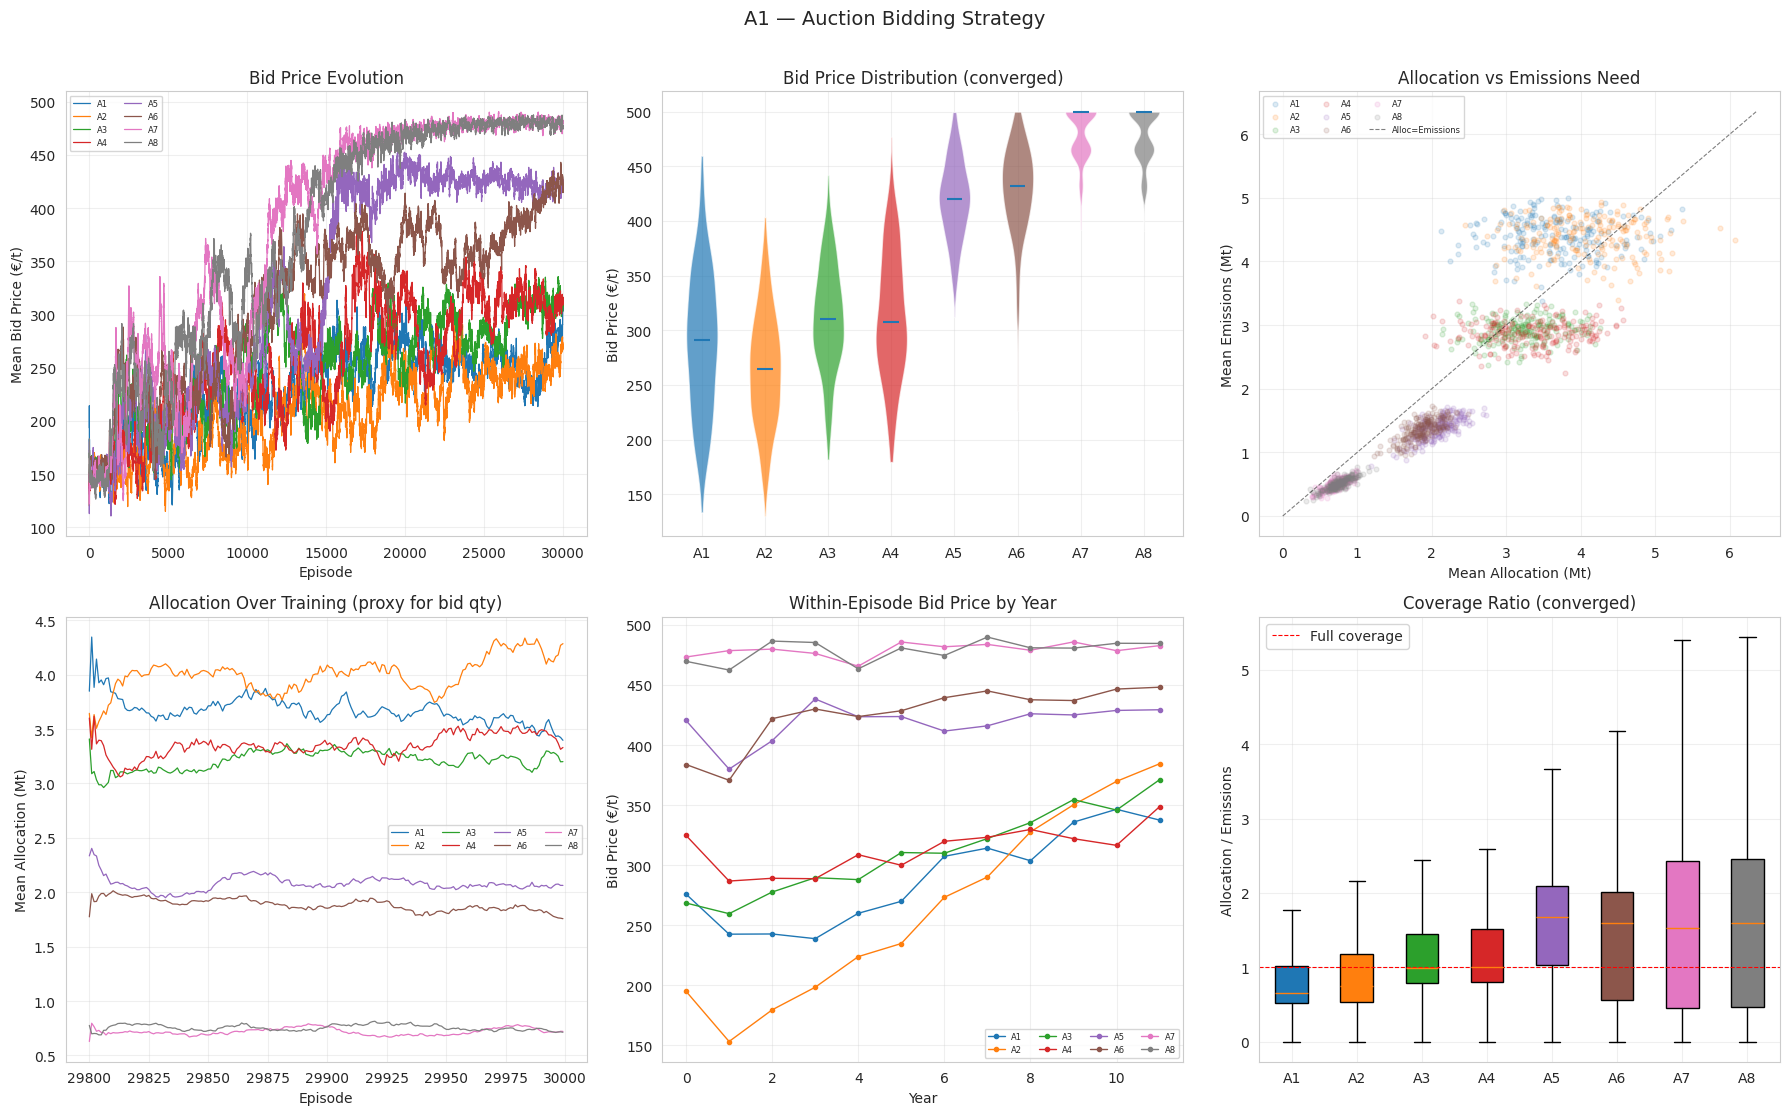

In [19]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11))

# 1 — Bid price evolution per agent
ax = axes[0, 0]
for i in range(n_agents):
    ax.plot(ep_df['episode'], ep_df[f'bid_price_A{i+1}'].rolling(ROLL, min_periods=1).mean(),
            color=agent_colors[i], lw=0.9, label=agent_labels[i])
ax.set_xlabel('Episode'); ax.set_ylabel('Mean Bid Price (\u20ac/t)')
ax.set_title('Bid Price Evolution'); ax.legend(fontsize=6, ncol=2); ax.grid(True, alpha=0.3)

# 2 — Bid price distribution (converged)
ax = axes[0, 1]
bid_data = [recent_ep[f'bid_price_A{i+1}'].values for i in range(n_agents)]
parts = ax.violinplot(bid_data, positions=range(n_agents), showmedians=True, showextrema=False)
for i, pc in enumerate(parts['bodies']):
    pc.set_facecolor(agent_colors[i]); pc.set_alpha(0.7)
ax.set_xticks(range(n_agents)); ax.set_xticklabels([f'A{i+1}' for i in range(n_agents)])
ax.set_ylabel('Bid Price (\u20ac/t)')
ax.set_title('Bid Price Distribution (converged)'); ax.grid(True, alpha=0.3)

# 3 — Allocation vs Emissions scatter (converged)
ax = axes[0, 2]
for i in range(n_agents):
    allocs = recent_yr.groupby('episode')[f'alloc_A{i+1}'].mean()
    emiss = recent_yr.groupby('episode')[f'emissions_A{i+1}'].mean()
    ax.scatter(allocs, emiss, alpha=0.15, s=12, color=agent_colors[i], label=f'A{i+1}')
lims = [0, max(ax.get_xlim()[1], ax.get_ylim()[1])]
ax.plot(lims, lims, 'k--', lw=0.8, alpha=0.5, label='Alloc=Emissions')
ax.set_xlabel('Mean Allocation (Mt)'); ax.set_ylabel('Mean Emissions (Mt)')
ax.set_title('Allocation vs Emissions Need')
ax.legend(fontsize=6, ncol=3); ax.grid(True, alpha=0.3)

# 4 — Bid quantity evolution
ax = axes[1, 0]
for i in range(n_agents):
    alloc_roll = recent_yr.groupby('episode')[f'alloc_A{i+1}'].mean()
    alloc_smooth = alloc_roll.rolling(ROLL // 2, min_periods=1).mean()
    ax.plot(alloc_smooth.index, alloc_smooth.values, color=agent_colors[i], lw=0.9, label=f'A{i+1}')
ax.set_xlabel('Episode'); ax.set_ylabel('Mean Allocation (Mt)')
ax.set_title('Allocation Over Training (proxy for bid qty)'); ax.legend(fontsize=6, ncol=4)
ax.grid(True, alpha=0.3)

# 5 — Bid price by year within episode (converged)
ax = axes[1, 1]
for i in range(n_agents):
    bid_yr = recent_yr.groupby('year')[f'bid_price_A{i+1}'].mean()
    ax.plot(bid_yr.index, bid_yr.values, color=agent_colors[i], marker='o', ms=3,
            lw=1, label=f'A{i+1}')
ax.set_xlabel('Year'); ax.set_ylabel('Bid Price (\u20ac/t)')
ax.set_title('Within-Episode Bid Price by Year')
ax.legend(fontsize=6, ncol=4); ax.grid(True, alpha=0.3)

# 6 — Coverage ratio: allocation / emissions
ax = axes[1, 2]
cov_data = []
for i in range(n_agents):
    a = recent_yr[f'alloc_A{i+1}']
    e = recent_yr[f'emissions_A{i+1}'].replace(0, np.nan)
    cov_data.append((a / e).dropna().values)
bp = ax.boxplot(cov_data, labels=[f'A{i+1}' for i in range(n_agents)],
                patch_artist=True, showfliers=False)
for i, patch in enumerate(bp['boxes']):
    patch.set_facecolor(agent_colors[i])
ax.axhline(1.0, color='red', ls='--', lw=0.8, label='Full coverage')
ax.set_ylabel('Allocation / Emissions')
ax.set_title('Coverage Ratio (converged)'); ax.legend(); ax.grid(True, alpha=0.3)

plt.suptitle('A1 \u2014 Auction Bidding Strategy', fontsize=14, y=1.01)
plt.tight_layout(); plt.show()

### A2. Secondary Market Strategy

How agents trade on the secondary market:
- **Role evolution** — who becomes a net buyer vs seller over training?
- **Year-by-year patterns** — do roles shift within an episode as the cap tightens?
- **Price premiums** — secondary vs auction price spread
- **Cost/revenue** — who profits from secondary trading?

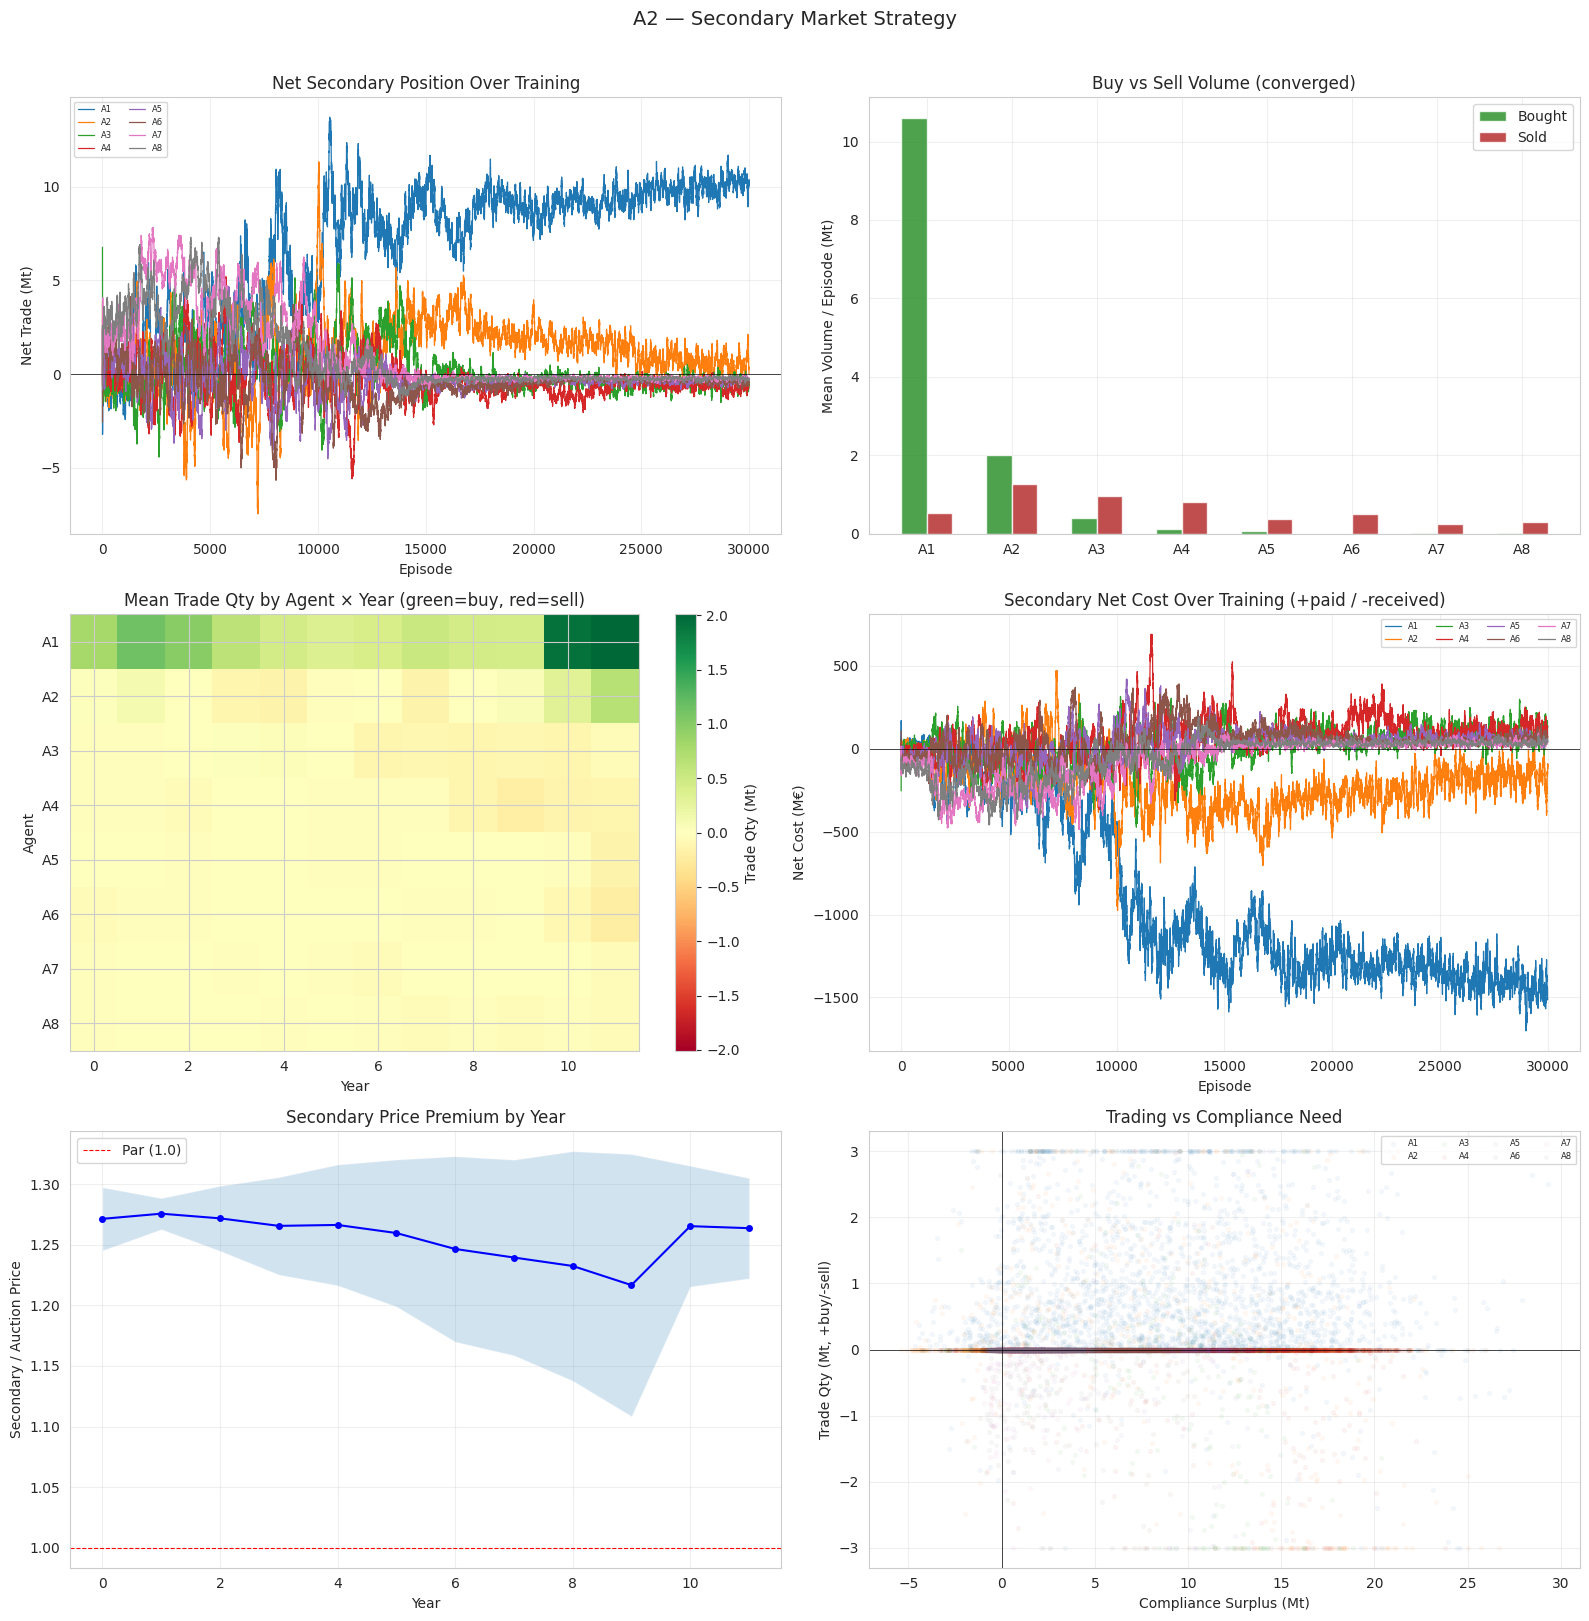

In [20]:
fig, axes = plt.subplots(3, 2, figsize=(16, 16))

# 1 — Net trade position over training (rolling)
ax = axes[0, 0]
for i in range(n_agents):
    net_trade = yr_df.groupby('episode')[f'trade_qty_A{i+1}'].sum()
    ax.plot(net_trade.index, net_trade.rolling(ROLL, min_periods=1).mean(),
            color=agent_colors[i], lw=0.9, label=agent_labels[i])
ax.axhline(0, color='black', ls='-', lw=0.5)
ax.set_xlabel('Episode'); ax.set_ylabel('Net Trade (Mt)')
ax.set_title('Net Secondary Position Over Training')
ax.legend(fontsize=6, ncol=2); ax.grid(True, alpha=0.3)

# 2 — Buy vs Sell volume per agent (converged)
ax = axes[0, 1]
buy_vols = []
sell_vols = []
for i in range(n_agents):
    tq = recent_yr[f'trade_qty_A{i+1}']
    buy_vols.append(tq[tq > 0.01].sum() / LAST_N)
    sell_vols.append(abs(tq[tq < -0.01].sum()) / LAST_N)
x = np.arange(n_agents)
ax.bar(x - 0.15, buy_vols, 0.3, color='forestgreen', alpha=0.8, label='Bought')
ax.bar(x + 0.15, sell_vols, 0.3, color='firebrick', alpha=0.8, label='Sold')
ax.set_xticks(x); ax.set_xticklabels([f'A{i+1}' for i in range(n_agents)])
ax.set_ylabel('Mean Volume / Episode (Mt)')
ax.set_title('Buy vs Sell Volume (converged)'); ax.legend(); ax.grid(True, alpha=0.3)

# 3 — Trade position by year within episode (heatmap)
ax = axes[1, 0]
trade_matrix = np.zeros((n_agents, n_years_per_ep))
for i in range(n_agents):
    trade_by_yr = recent_yr.groupby('year')[f'trade_qty_A{i+1}'].mean()
    trade_matrix[i, :len(trade_by_yr)] = trade_by_yr.values
vmax = max(abs(trade_matrix.min()), abs(trade_matrix.max()))
im = ax.imshow(trade_matrix, aspect='auto', cmap='RdYlGn', vmin=-vmax, vmax=vmax)
ax.set_xlabel('Year'); ax.set_ylabel('Agent')
ax.set_yticks(range(n_agents)); ax.set_yticklabels([f'A{i+1}' for i in range(n_agents)])
ax.set_title('Mean Trade Qty by Agent \u00d7 Year (green=buy, red=sell)')
plt.colorbar(im, ax=ax, label='Trade Qty (Mt)')

# 4 — Net secondary cost over training
ax = axes[1, 1]
for i in range(n_agents):
    snet = yr_df.groupby('episode')[f'secondary_net_A{i+1}'].sum()
    ax.plot(snet.index, snet.rolling(ROLL, min_periods=1).mean(),
            color=agent_colors[i], lw=0.9, label=f'A{i+1}')
ax.axhline(0, color='black', ls='-', lw=0.5)
ax.set_xlabel('Episode'); ax.set_ylabel('Net Cost (M\u20ac)')
ax.set_title('Secondary Net Cost Over Training (+paid / -received)')
ax.legend(fontsize=6, ncol=4); ax.grid(True, alpha=0.3)

# 5 — Secondary price premium over auction
ax = axes[2, 0]
premium = recent_yr['secondary_price'] / recent_yr['clearing_price'].replace(0, np.nan)
premium_yr = premium.groupby(recent_yr['year']).agg(['mean', 'std'])
ax.plot(premium_yr.index, premium_yr['mean'], 'b-o', ms=4, lw=1.5)
ax.fill_between(premium_yr.index,
                premium_yr['mean'] - premium_yr['std'],
                premium_yr['mean'] + premium_yr['std'], alpha=0.2)
ax.axhline(1.0, color='red', ls='--', lw=0.8, label='Par (1.0)')
ax.set_xlabel('Year'); ax.set_ylabel('Secondary / Auction Price')
ax.set_title('Secondary Price Premium by Year'); ax.legend(); ax.grid(True, alpha=0.3)

# 6 — Trade qty vs compliance surplus (who trades based on need?)
ax = axes[2, 1]
if 'compliance_surplus_A1' in recent_yr.columns:
    for i in range(n_agents):
        ax.scatter(recent_yr[f'compliance_surplus_A{i+1}'],
                   recent_yr[f'trade_qty_A{i+1}'],
                   alpha=0.04, s=8, color=agent_colors[i], label=f'A{i+1}')
    ax.axhline(0, color='black', ls='-', lw=0.5)
    ax.axvline(0, color='black', ls='-', lw=0.5)
    ax.set_xlabel('Compliance Surplus (Mt)')
    ax.set_ylabel('Trade Qty (Mt, +buy/-sell)')
    ax.set_title('Trading vs Compliance Need')
    ax.legend(fontsize=6, ncol=4)
else:
    ax.text(0.5, 0.5, 'compliance_surplus not logged', ha='center', va='center',
            transform=ax.transAxes)
ax.grid(True, alpha=0.3)

plt.suptitle('A2 \u2014 Secondary Market Strategy', fontsize=14, y=1.01)
plt.tight_layout(); plt.show()

### A3. Green Transition Strategy

Investment patterns in renewable energy:
- **Transition speed** — how quickly does each archetype green its portfolio?
- **Investment intensity** — how aggressively do agents invest?
- **Technology preference** — onshore wind, offshore wind, or solar?
- **Construction pipeline** — queuing effects and timing

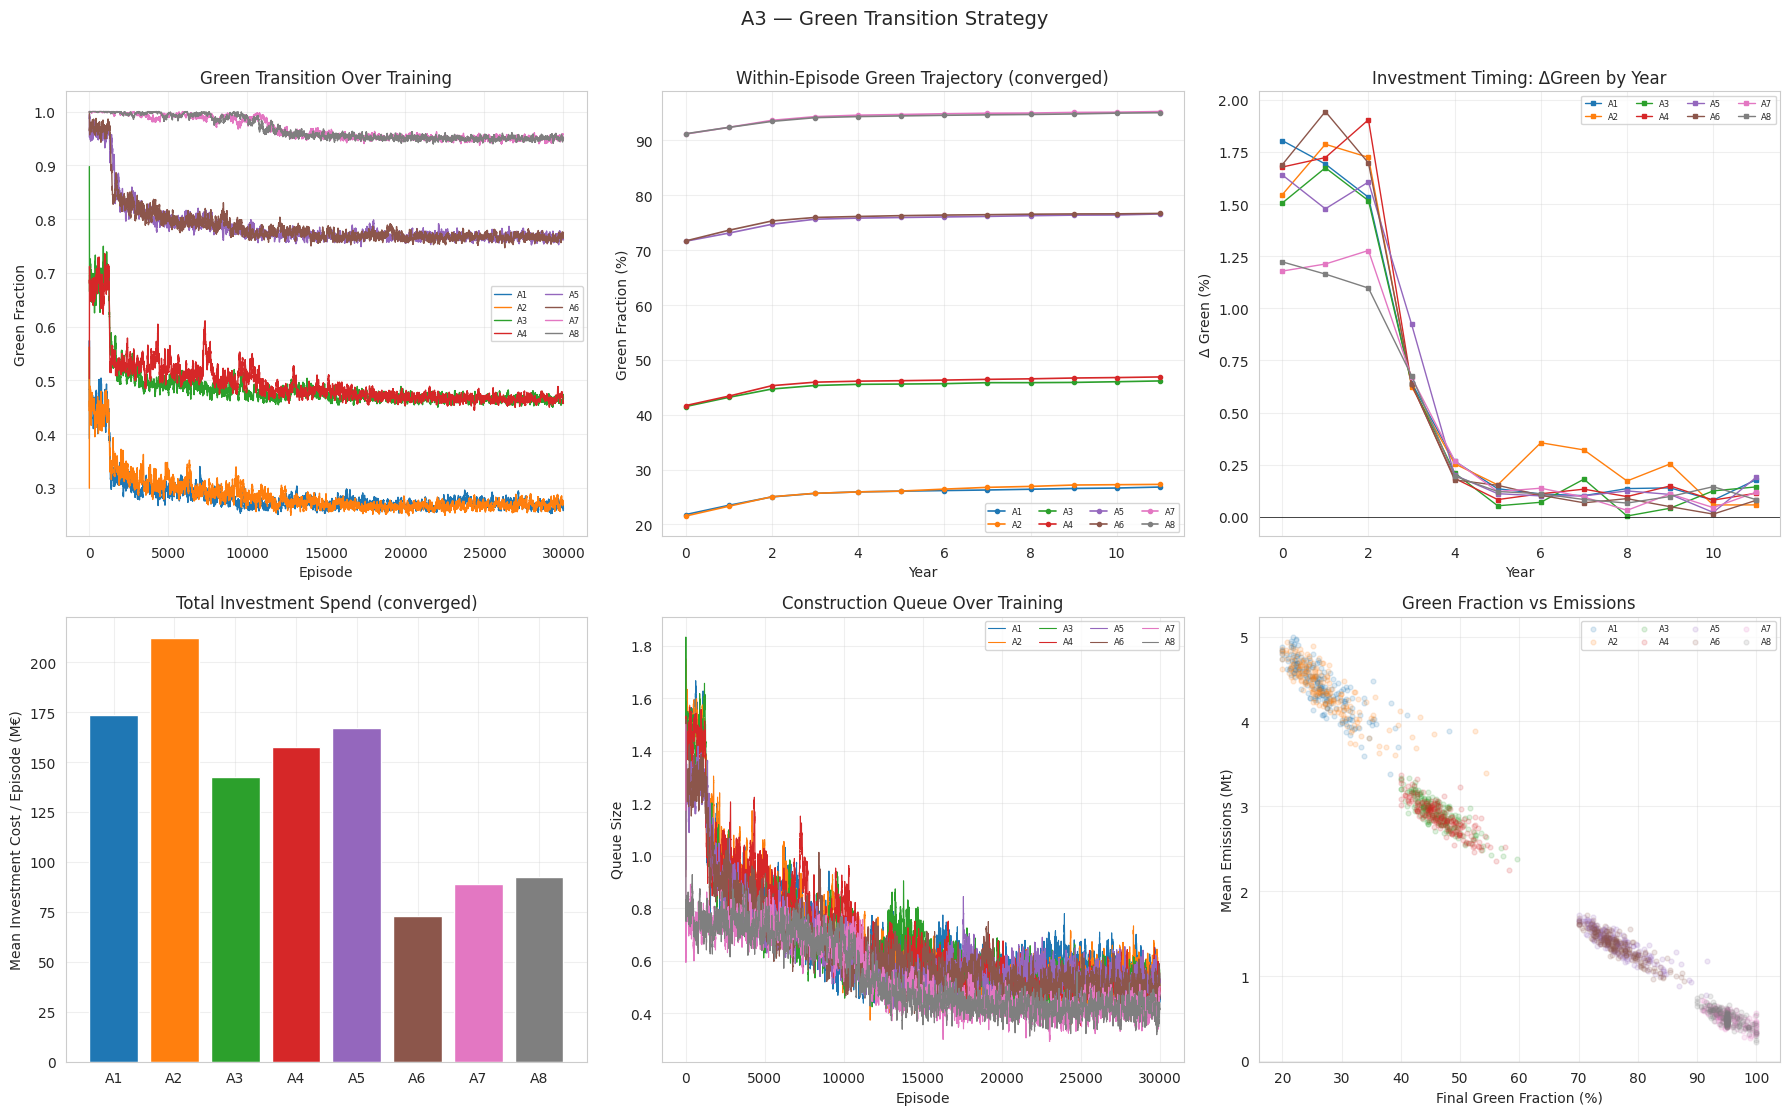

In [21]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11))

# 1 — Green fraction evolution over training
ax = axes[0, 0]
for i in range(n_agents):
    ax.plot(ep_df['episode'], ep_df[f'green_frac_A{i+1}'].rolling(ROLL, min_periods=1).mean(),
            color=agent_colors[i], lw=1, label=agent_labels[i])
ax.set_xlabel('Episode'); ax.set_ylabel('Green Fraction')
ax.set_title('Green Transition Over Training')
ax.legend(fontsize=6, ncol=2); ax.grid(True, alpha=0.3)

# 2 — Green fraction by year within episode (converged)
ax = axes[0, 1]
for i in range(n_agents):
    gf_yr = recent_yr.groupby('year')[f'green_frac_A{i+1}'].mean()
    ax.plot(gf_yr.index, gf_yr.values * 100, color=agent_colors[i], marker='o', ms=3,
            lw=1.2, label=f'A{i+1}')
ax.set_xlabel('Year'); ax.set_ylabel('Green Fraction (%)')
ax.set_title('Within-Episode Green Trajectory (converged)')
ax.legend(fontsize=6, ncol=4); ax.grid(True, alpha=0.3)

# 3 — Delta green by year (when do agents invest?)
ax = axes[0, 2]
for i in range(n_agents):
    dg_yr = recent_yr.groupby('year')[f'delta_green_A{i+1}'].mean() * 100
    ax.plot(dg_yr.index, dg_yr.values, color=agent_colors[i], marker='s', ms=3,
            lw=1, label=f'A{i+1}')
ax.axhline(0, color='black', ls='-', lw=0.5)
ax.set_xlabel('Year'); ax.set_ylabel('\u0394 Green (%)')
ax.set_title('Investment Timing: \u0394Green by Year')
ax.legend(fontsize=6, ncol=4); ax.grid(True, alpha=0.3)

# 4 — Investment cost per agent (converged)
ax = axes[1, 0]
inv_means = [recent_yr.groupby('episode')[f'invest_cost_A{i+1}'].sum().mean()
             for i in range(n_agents)]
ax.bar([f'A{i+1}' for i in range(n_agents)], inv_means, color=agent_colors)
ax.set_ylabel('Mean Investment Cost / Episode (M\u20ac)')
ax.set_title('Total Investment Spend (converged)'); ax.grid(True, alpha=0.3)

# 5 — Construction queue over training
ax = axes[1, 1]
for i in range(n_agents):
    col = f'queue_size_A{i+1}'
    if col in ep_df.columns:
        ax.plot(ep_df['episode'], ep_df[col].rolling(ROLL, min_periods=1).mean(),
                color=agent_colors[i], lw=0.8, label=f'A{i+1}')
ax.set_xlabel('Episode'); ax.set_ylabel('Queue Size')
ax.set_title('Construction Queue Over Training')
ax.legend(fontsize=6, ncol=4); ax.grid(True, alpha=0.3)

# 6 — Green fraction vs emissions (converged)
ax = axes[1, 2]
for i in range(n_agents):
    gf = recent_yr.groupby('episode')[f'green_frac_A{i+1}'].last()
    em = recent_yr.groupby('episode')[f'emissions_A{i+1}'].mean()
    ax.scatter(gf * 100, em, alpha=0.15, s=12, color=agent_colors[i], label=f'A{i+1}')
ax.set_xlabel('Final Green Fraction (%)'); ax.set_ylabel('Mean Emissions (Mt)')
ax.set_title('Green Fraction vs Emissions')
ax.legend(fontsize=6, ncol=4); ax.grid(True, alpha=0.3)

plt.suptitle('A3 \u2014 Green Transition Strategy', fontsize=14, y=1.01)
plt.tight_layout(); plt.show()

### A4. Compliance & Banking Strategy

How agents manage their allowance portfolio:
- **Banking** — accumulating surplus for future compliance
- **Shortfall avoidance** — learning to stay compliant
- **Risk management** — holdings buffer vs cost minimization

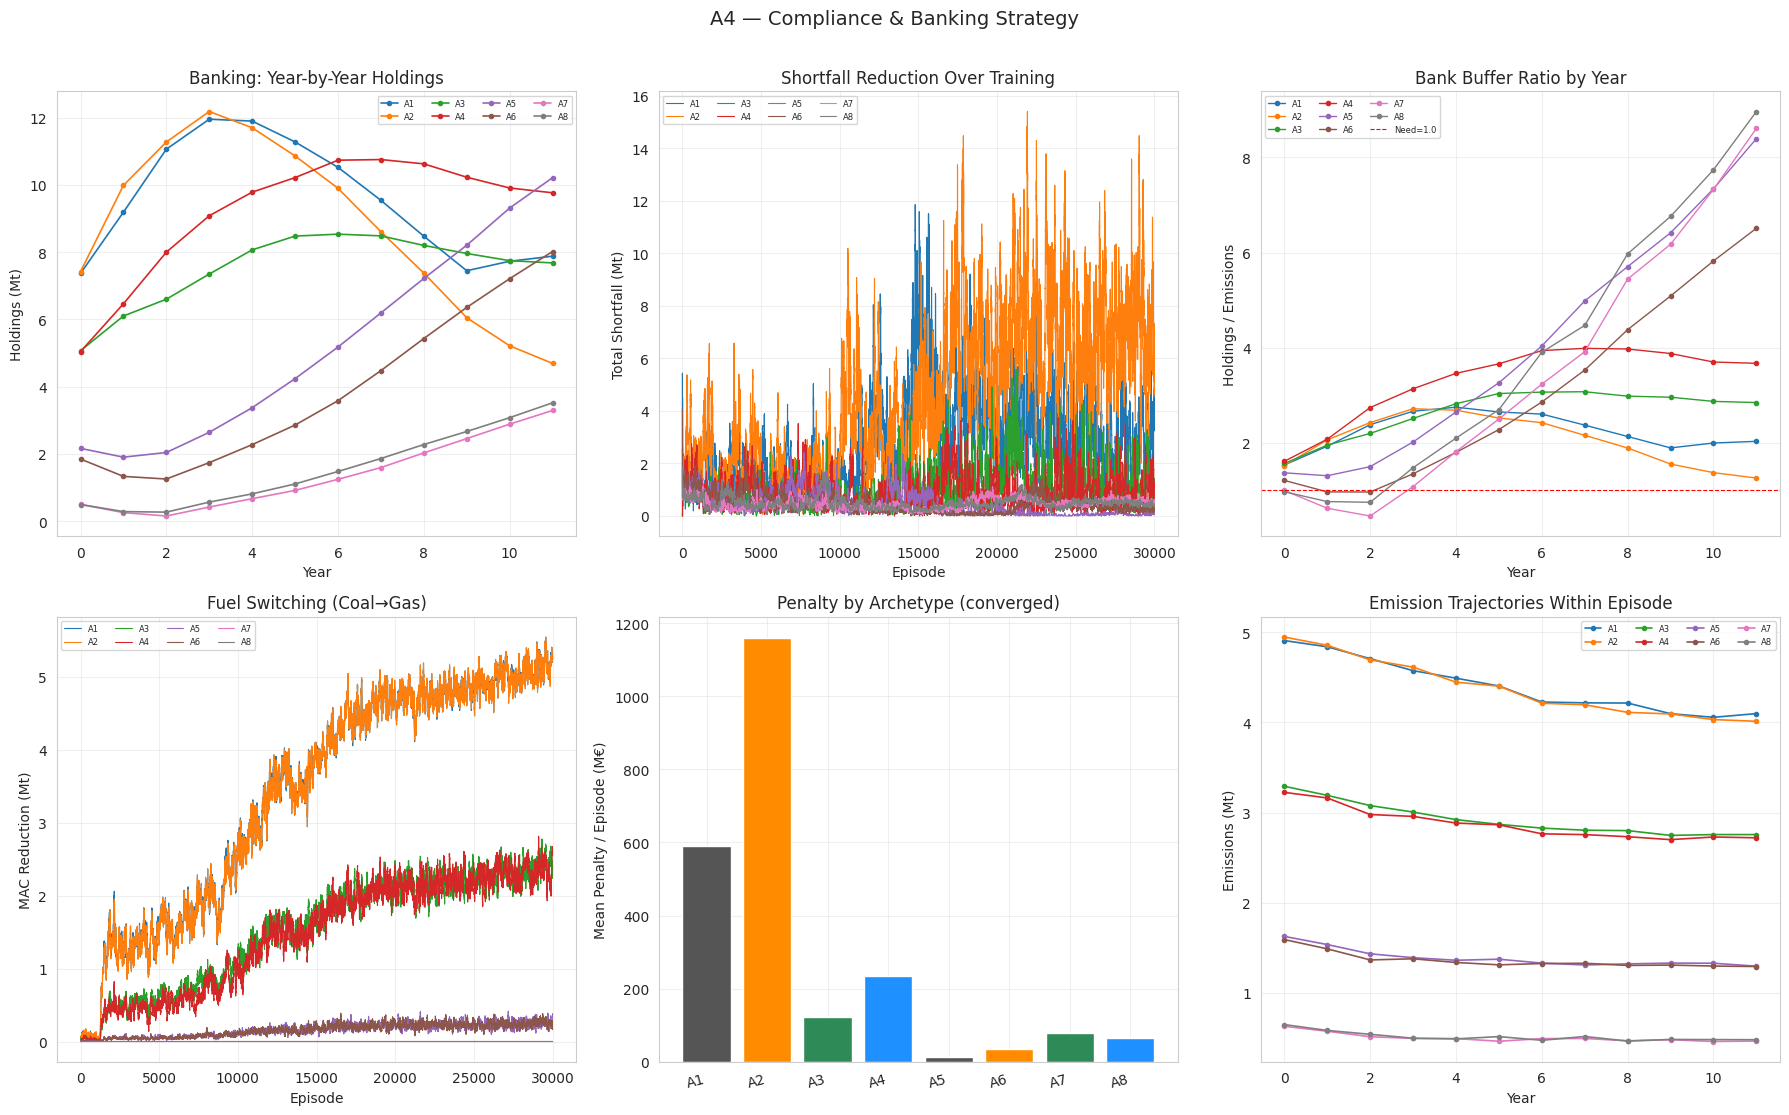

In [22]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11))

# 1 — Holdings trajectory by year (converged)
ax = axes[0, 0]
for i in range(n_agents):
    h_yr = recent_yr.groupby('year')[f'holdings_A{i+1}'].mean()
    ax.plot(h_yr.index, h_yr.values, color=agent_colors[i], marker='o', ms=3,
            lw=1.2, label=f'A{i+1}')
ax.set_xlabel('Year'); ax.set_ylabel('Holdings (Mt)')
ax.set_title('Banking: Year-by-Year Holdings')
ax.legend(fontsize=6, ncol=4); ax.grid(True, alpha=0.3)

# 2 — Shortfall per agent over training
ax = axes[0, 1]
for i in range(n_agents):
    sf = ep_df[f'shortfall_A{i+1}'].rolling(ROLL, min_periods=1).mean()
    ax.plot(ep_df['episode'], sf, color=agent_colors[i], lw=0.8, label=f'A{i+1}')
ax.set_xlabel('Episode'); ax.set_ylabel('Total Shortfall (Mt)')
ax.set_title('Shortfall Reduction Over Training')
ax.legend(fontsize=6, ncol=4); ax.grid(True, alpha=0.3)

# 3 — Holdings vs emissions need (buffer ratio)
ax = axes[0, 2]
for i in range(n_agents):
    h = recent_yr[f'holdings_A{i+1}']
    e = recent_yr[f'emissions_A{i+1}'].replace(0, np.nan)
    buffer = (h / e).dropna()
    buf_yr = buffer.groupby(recent_yr.loc[buffer.index, 'year']).mean()
    ax.plot(buf_yr.index, buf_yr.values, color=agent_colors[i], marker='o', ms=3,
            lw=1, label=f'A{i+1}')
ax.axhline(1.0, color='red', ls='--', lw=0.8, label='Need=1.0')
ax.set_xlabel('Year'); ax.set_ylabel('Holdings / Emissions')
ax.set_title('Bank Buffer Ratio by Year')
ax.legend(fontsize=6, ncol=3); ax.grid(True, alpha=0.3)

# 4 — MAC fuel-switching usage
ax = axes[1, 0]
mac_cols_ep = [f'total_mac_reduction_A{i+1}' for i in range(n_agents)
               if f'total_mac_reduction_A{i+1}' in ep_df.columns]
if mac_cols_ep:
    for i, col in enumerate(mac_cols_ep):
        ax.plot(ep_df['episode'], ep_df[col].rolling(ROLL, min_periods=1).mean(),
                color=agent_colors[i], lw=0.8, label=f'A{i+1}')
    ax.set_xlabel('Episode'); ax.set_ylabel('MAC Reduction (Mt)')
    ax.set_title('Fuel Switching (Coal\u2192Gas)')
    ax.legend(fontsize=6, ncol=4)
else:
    ax.text(0.5, 0.5, 'MAC data not available', ha='center', va='center',
            transform=ax.transAxes)
ax.grid(True, alpha=0.3)

# 5 — Penalty by archetype
ax = axes[1, 1]
pen_by_arch = {}
for i in range(n_agents):
    arch = agent_labels[i].split('(')[1].rstrip(')') if '(' in agent_labels[i] else f'A{i+1}'
    pen = recent_ep[f'penalty_A{i+1}'].mean()
    pen_by_arch.setdefault(arch, []).append(pen)
arch_names = list(pen_by_arch.keys())
arch_means = [np.mean(v) for v in pen_by_arch.values()]
ax.bar(arch_names, arch_means, color=['#555555', '#FF8C00', '#2E8B57', '#1E90FF'][:len(arch_names)])
ax.set_ylabel('Mean Penalty / Episode (M\u20ac)')
ax.set_title('Penalty by Archetype (converged)')
plt.setp(ax.get_xticklabels(), rotation=15, ha='right')
ax.grid(True, alpha=0.3)

# 6 — Emissions trajectory by year (converged)
ax = axes[1, 2]
for i in range(n_agents):
    em_yr = recent_yr.groupby('year')[f'emissions_A{i+1}'].mean()
    ax.plot(em_yr.index, em_yr.values, color=agent_colors[i], marker='o', ms=3,
            lw=1.2, label=f'A{i+1}')
ax.set_xlabel('Year'); ax.set_ylabel('Emissions (Mt)')
ax.set_title('Emission Trajectories Within Episode')
ax.legend(fontsize=6, ncol=4); ax.grid(True, alpha=0.3)

plt.suptitle('A4 \u2014 Compliance & Banking Strategy', fontsize=14, y=1.01)
plt.tight_layout(); plt.show()

### A5. Reward Decomposition & Cost Structure

What drives agent rewards? Decompose into cost components to understand
the economic trade-offs agents face.

/tmp/ipykernel_6324/1362448480.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(rew_data, labels=[f'A{i+1}' for i in range(n_agents)],


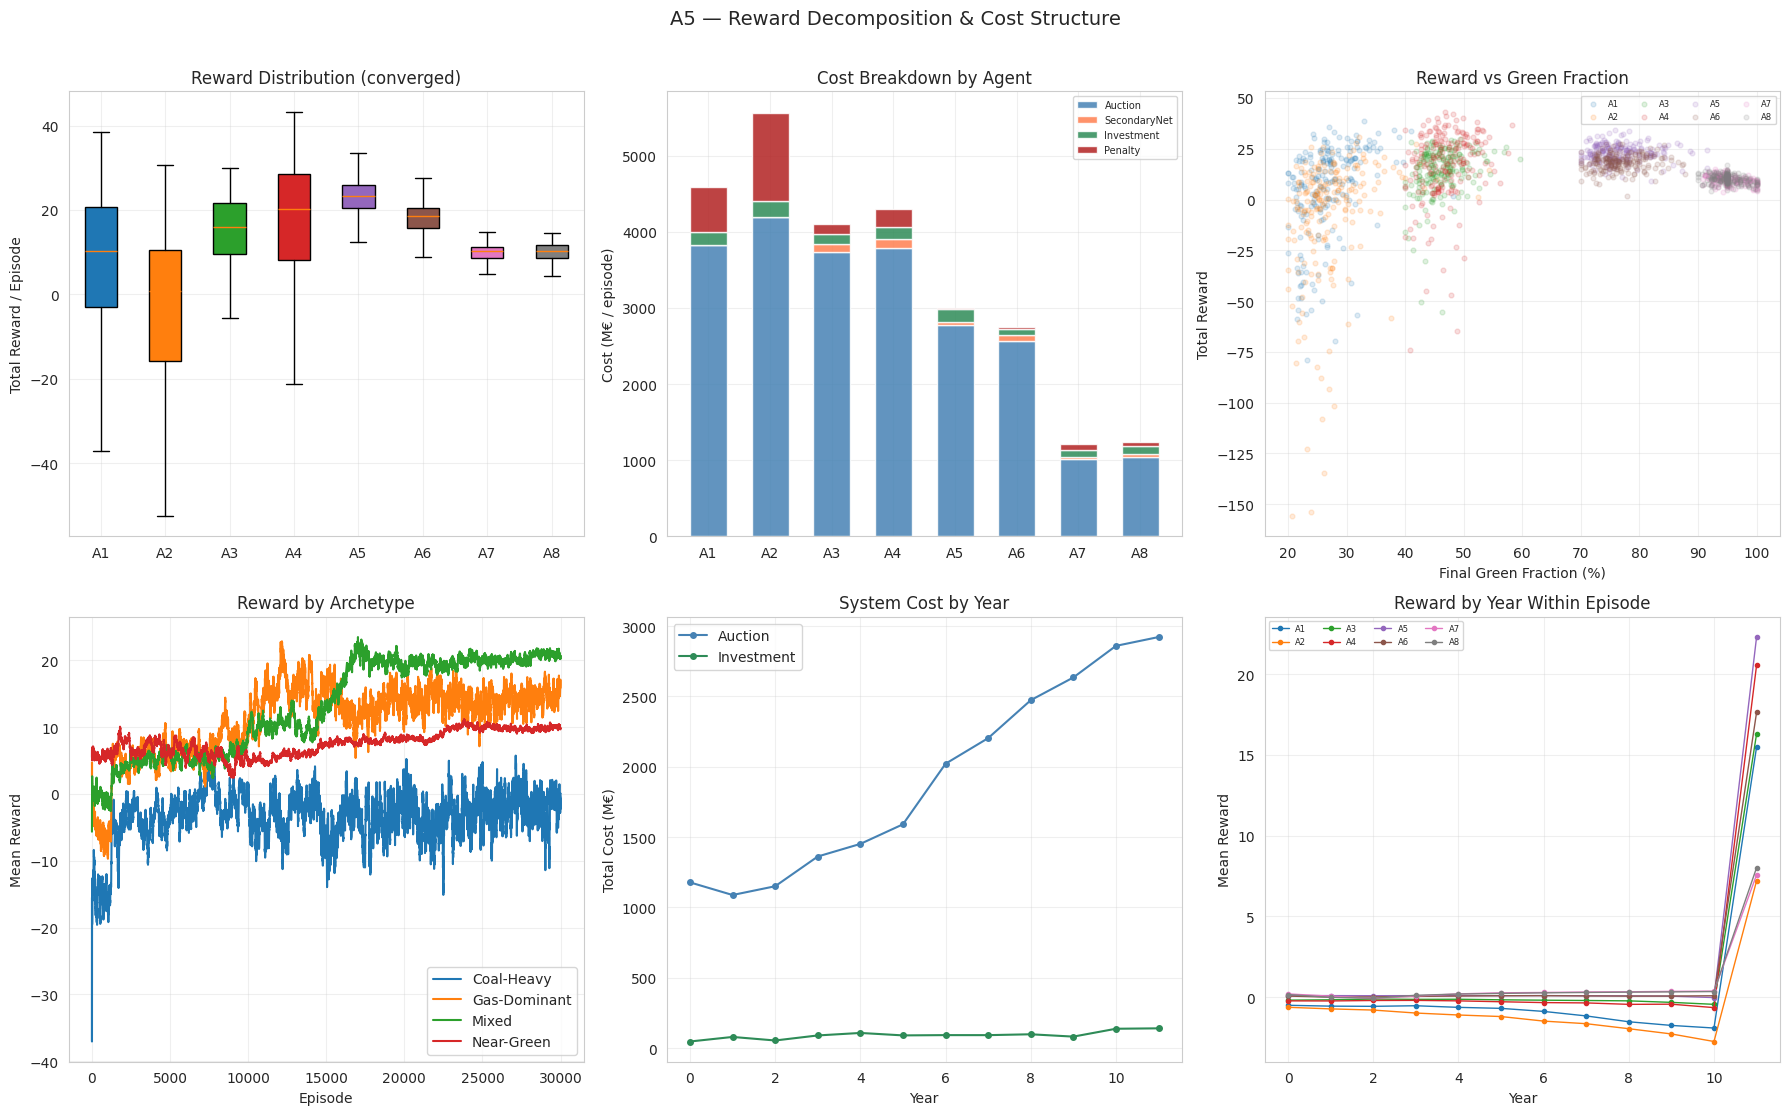

In [23]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11))

# 1 — Reward distribution (converged)
ax = axes[0, 0]
rew_data = [recent_ep[f'reward_A{i+1}'].values for i in range(n_agents)]
bp = ax.boxplot(rew_data, labels=[f'A{i+1}' for i in range(n_agents)],
                patch_artist=True, showfliers=False)
for i, patch in enumerate(bp['boxes']):
    patch.set_facecolor(agent_colors[i])
ax.set_ylabel('Total Reward / Episode')
ax.set_title('Reward Distribution (converged)'); ax.grid(True, alpha=0.3)

# 2 — Cost breakdown per agent (converged means)
ax = axes[0, 1]
cost_components = {}
for comp, col_tmpl in [('Auction', 'auction_cost_A{}'),
                        ('SecondaryNet', 'secondary_net_A{}'),
                        ('Investment', 'invest_cost_A{}'),
                        ('Penalty', 'penalty_A{}')]:
    means = []
    for i in range(n_agents):
        col = col_tmpl.format(i+1)
        if col in recent_yr.columns:
            means.append(recent_yr.groupby('episode')[col].sum().mean())
        else:
            means.append(0)
    cost_components[comp] = means

x = np.arange(n_agents)
bottom = np.zeros(n_agents)
comp_colors = {'Auction': 'steelblue', 'SecondaryNet': 'coral',
               'Investment': 'seagreen', 'Penalty': 'firebrick'}
for comp, vals in cost_components.items():
    vals_pos = np.maximum(vals, 0)
    ax.bar(x, vals_pos, 0.6, bottom=bottom, label=comp, color=comp_colors[comp], alpha=0.85)
    bottom += vals_pos
ax.set_xticks(x); ax.set_xticklabels([f'A{i+1}' for i in range(n_agents)])
ax.set_ylabel('Cost (M\u20ac / episode)')
ax.set_title('Cost Breakdown by Agent'); ax.legend(fontsize=7); ax.grid(True, alpha=0.3)

# 3 — Reward vs green fraction
ax = axes[0, 2]
for i in range(n_agents):
    gf = recent_ep[f'green_frac_A{i+1}']
    rw = recent_ep[f'reward_A{i+1}']
    ax.scatter(gf * 100, rw, alpha=0.15, s=12, color=agent_colors[i], label=f'A{i+1}')
ax.set_xlabel('Final Green Fraction (%)'); ax.set_ylabel('Total Reward')
ax.set_title('Reward vs Green Fraction')
ax.legend(fontsize=6, ncol=4); ax.grid(True, alpha=0.3)

# 4 — Reward by archetype over training
ax = axes[1, 0]
n_per_arch = n_agents // 4
for a_idx, arch in enumerate(_base_archetypes):
    agent_ids = list(range(a_idx * n_per_arch, (a_idx + 1) * n_per_arch))
    if not agent_ids:
        continue
    arch_rew = sum(ep_df[f'reward_A{i+1}'] for i in agent_ids) / len(agent_ids)
    ax.plot(ep_df['episode'], arch_rew.rolling(ROLL, min_periods=1).mean(),
            lw=1.5, label=arch)
ax.set_xlabel('Episode'); ax.set_ylabel('Mean Reward')
ax.set_title('Reward by Archetype'); ax.legend(); ax.grid(True, alpha=0.3)

# 5 — Cost by year within episode
ax = axes[1, 1]
if 'auction_cost_A1' in recent_yr.columns:
    for comp, col_tmpl, color in [('Auction', 'auction_cost_A{}', 'steelblue'),
                                   ('Investment', 'invest_cost_A{}', 'seagreen')]:
        total = sum(recent_yr[col_tmpl.format(i+1)] for i in range(n_agents))
        by_yr = total.groupby(recent_yr['year']).mean()
        ax.plot(by_yr.index, by_yr.values, marker='o', ms=4, lw=1.5, color=color, label=comp)
    ax.set_xlabel('Year'); ax.set_ylabel('Total Cost (M\u20ac)')
    ax.set_title('System Cost by Year'); ax.legend(); ax.grid(True, alpha=0.3)

# 6 — Reward per year within episode
ax = axes[1, 2]
for i in range(n_agents):
    rew_yr = recent_yr.groupby('year')[f'reward_A{i+1}'].mean()
    ax.plot(rew_yr.index, rew_yr.values, color=agent_colors[i], marker='o', ms=3,
            lw=1, label=f'A{i+1}')
ax.set_xlabel('Year'); ax.set_ylabel('Mean Reward')
ax.set_title('Reward by Year Within Episode')
ax.legend(fontsize=6, ncol=4); ax.grid(True, alpha=0.3)

plt.suptitle('A5 \u2014 Reward Decomposition & Cost Structure', fontsize=14, y=1.01)
plt.tight_layout(); plt.show()

### A6. Deterministic Evaluation of Best Agents

Load the best checkpoint and run a single deterministic episode to see
learned strategies without exploration noise.

In [24]:
from scripts.train import build_agents

eval_env = ETSEnvironment(config, seed=0)
eval_agents = build_agents(eval_env, config, seed=0)
n_agents = config['companies']['n_agents']
tech_names = config['technologies']['names']

ckpt_dir = 'results/checkpoints_s42'
for i, agent in enumerate(eval_agents):
    ckpt_path = os.path.join(ckpt_dir, f'agent_{i}_best.pt')
    if os.path.exists(ckpt_path):
        agent.load(ckpt_path)
        print(f'Loaded agent {i}')
    else:
        print(f'No checkpoint for agent {i}')

obs1, _ = eval_env.reset(seed=0)
eval_data = []

for year in range(config['simulation']['n_years']):
    auction_actions = np.zeros((n_agents, 6), dtype=np.float32)
    for i in range(n_agents):
        action, _, _ = eval_agents[i].select_auction_action(obs1[i], deterministic=True)
        auction_actions[i] = action
    obs2, _ = eval_env.step_auction(auction_actions)

    secondary_actions = np.zeros((n_agents, 2), dtype=np.float32)
    for i in range(n_agents):
        action, _, _ = eval_agents[i].select_secondary_action(obs2[i], deterministic=True)
        secondary_actions[i] = action

    obs1, rewards, terminated, _, info = eval_env.step_secondary(secondary_actions)
    log = info['year_log']

    row = {'year': year, 'cap': log['cap'], 'price': log['clearing_price'],
           'secondary_price': log.get('secondary_clearing', 0), 'tnac': log.get('tnac', 0)}
    for i in range(n_agents):
        row[f'green_A{i+1}'] = log['green_fracs'][i]
        row[f'emissions_A{i+1}'] = log['emissions'][i]
        row[f'alloc_A{i+1}'] = log['allocations'][i]
        row[f'holdings_A{i+1}'] = log['holdings'][i]
        row[f'trade_qty_A{i+1}'] = log['trade_qtys'][i]
        row[f'trade_cost_A{i+1}'] = log['trade_costs'][i]
        row[f'shortfall_A{i+1}'] = log['shortfalls'][i]
        row[f'penalty_A{i+1}'] = log['penalties'][i]
        row[f'reward_A{i+1}'] = log['rewards'][i]
        row[f'invest_cost_A{i+1}'] = log['invest_costs'][i]
        for t in range(5):
            row[f'mix_A{i+1}_{tech_names[t]}'] = log['tech_mixes'][i][t]
    eval_data.append(row)
    if terminated:
        break

eval_df = pd.DataFrame(eval_data)
print(f'Evaluation: {len(eval_df)} years')
print(eval_df[['year', 'cap', 'price', 'tnac']].to_string(index=False))

[ETSEnvironment] 8 learning + 8 bot = 16 total agents | cancel_under_subscribed=False
Loaded agent 0
Loaded agent 1
Loaded agent 2
Loaded agent 3
Loaded agent 4
Loaded agent 5
Loaded agent 6
Loaded agent 7
Evaluation: 12 years
 year       cap      price       tnac
    0 50.000000 121.834702  57.156538
    1 47.850000  86.940140  64.824057
    2 45.792450 127.584030  73.681691
    3 43.823375 148.614868  79.323982
    4 41.895146 151.821014  83.744937
    5 40.051760 153.637543  86.270020
    6 38.289482 165.420792  89.788755
    7 36.604745 171.964844  95.368590
    8 34.994136 177.847107  99.099649
    9 33.454394 179.526688 102.474339
   10 31.982401 179.709579 103.054279
   11 30.575175 181.623642  99.352431


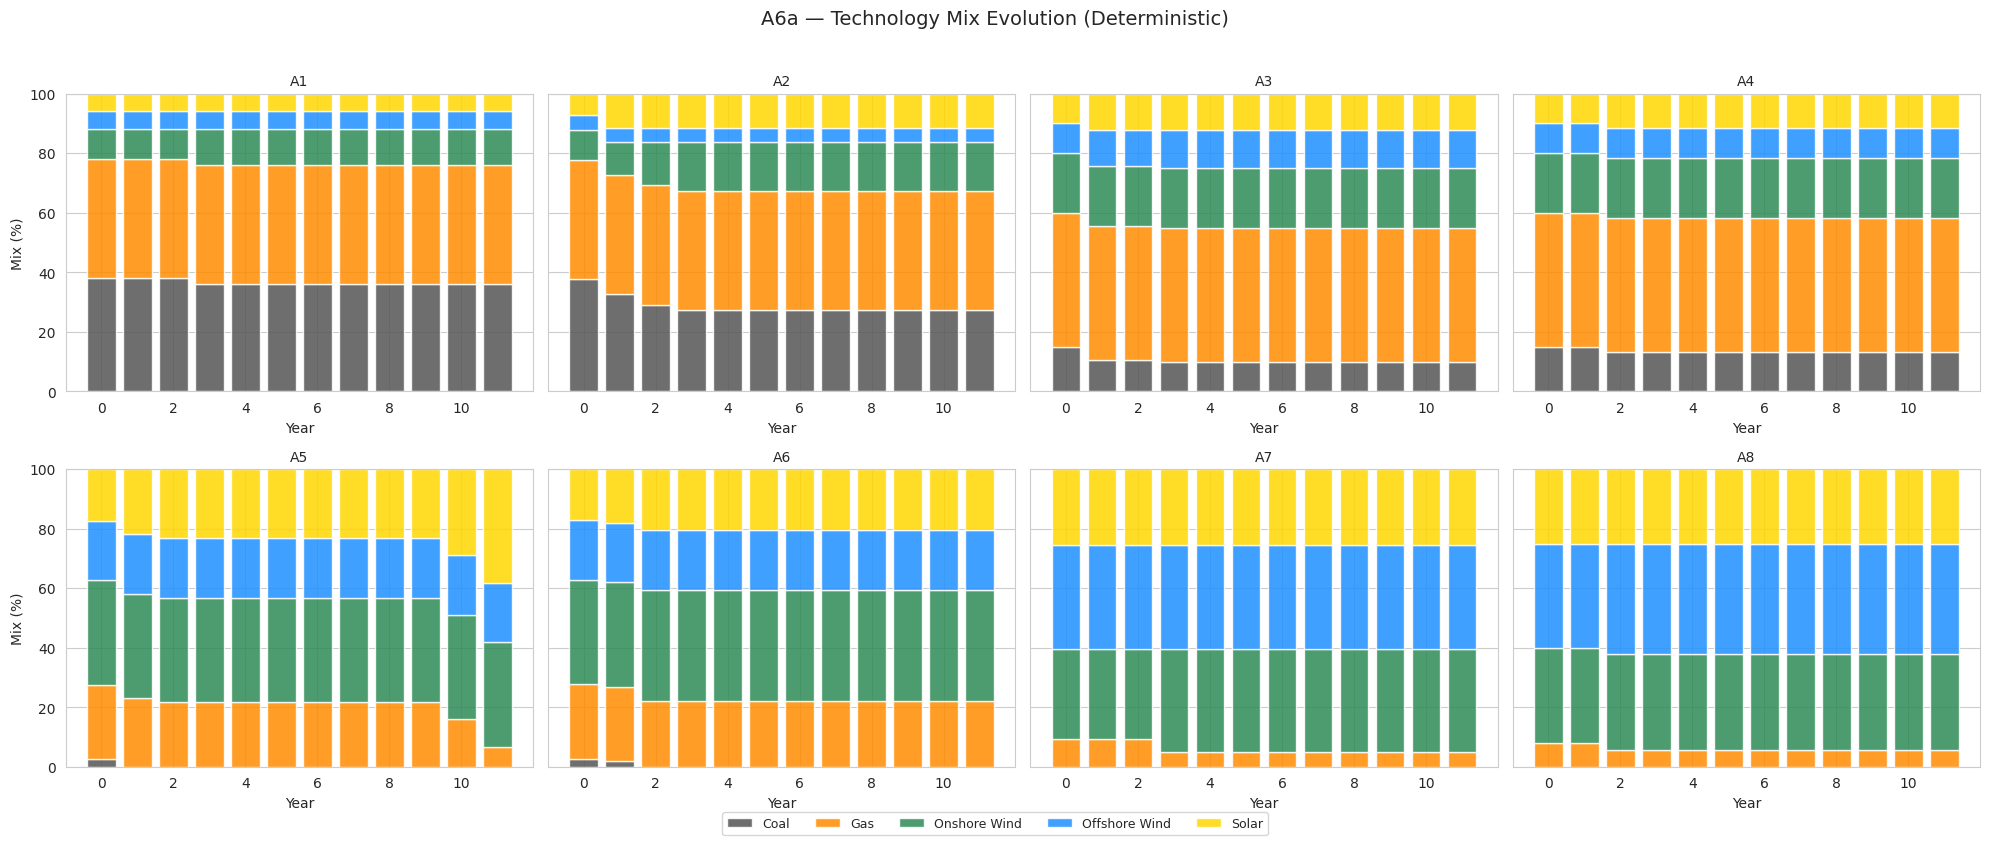

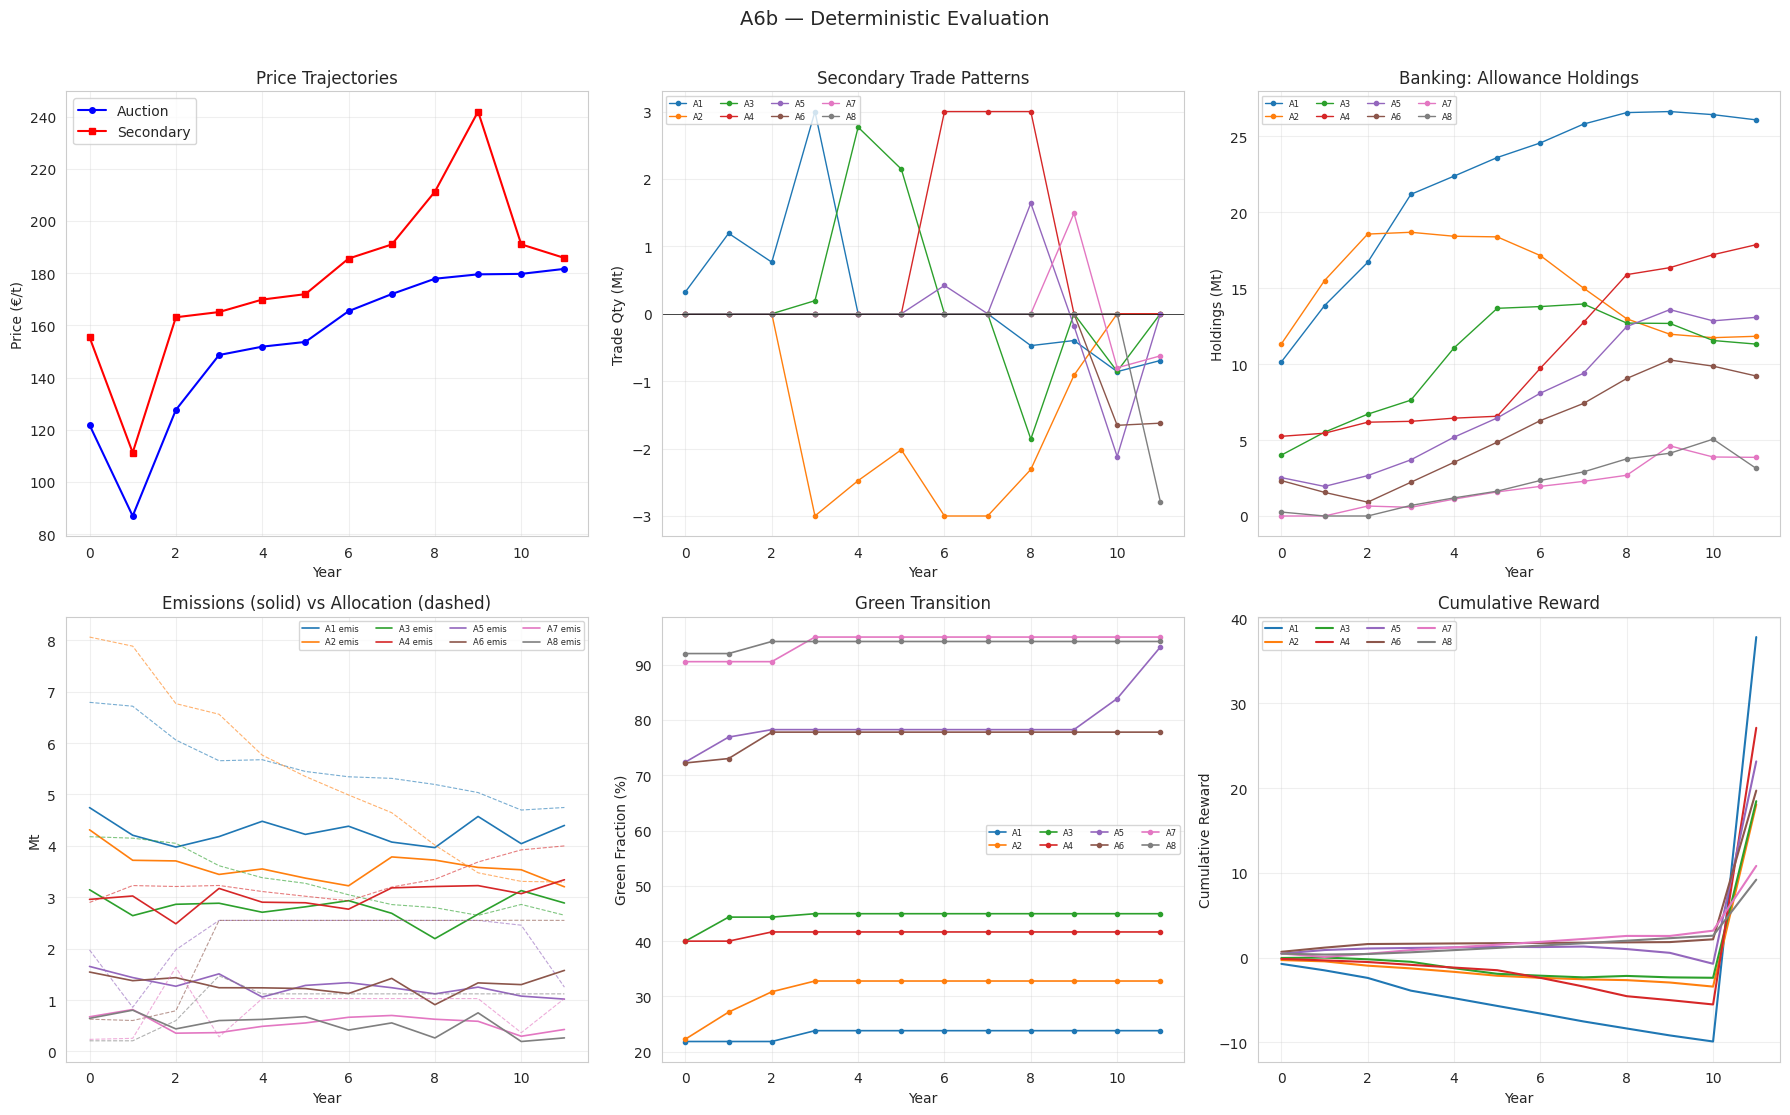

In [25]:
# ── A6 Deterministic Evaluation Plots ─────────────────────────────────
tech_colors = {'coal': '#555555', 'gas': '#FF8C00', 'onshore_wind': '#2E8B57',
               'offshore_wind': '#1E90FF', 'solar': '#FFD700'}

# --- Tech mix: one subplot per agent ---
ncols = min(4, n_agents)
nrows_tech = (n_agents + ncols - 1) // ncols
fig_tech, axes_tech = plt.subplots(nrows_tech, ncols, figsize=(5*ncols, 4*nrows_tech), sharey=True)
axes_tech = np.atleast_1d(axes_tech).flatten()

for i in range(n_agents):
    ax = axes_tech[i]
    bottom_v = np.zeros(len(eval_df))
    for t in range(5):
        vals = eval_df[f'mix_A{i+1}_{tech_names[t]}'].values * 100
        ax.bar(eval_df['year'], vals, bottom=bottom_v,
               color=tech_colors[tech_names[t]], alpha=0.85,
               label=tech_names[t].replace('_', ' ').title())
        bottom_v += vals
    ax.set_title(f'{agent_labels[i]}', fontsize=10)
    ax.set_ylim(0, 100)
    if i % ncols == 0:
        ax.set_ylabel('Mix (%)')
    ax.set_xlabel('Year')

for j in range(n_agents, len(axes_tech)):
    axes_tech[j].set_visible(False)

handles, labels = axes_tech[0].get_legend_handles_labels()
fig_tech.legend(handles, labels, loc='lower center', ncol=5, fontsize=9, bbox_to_anchor=(0.5, -0.02))
fig_tech.suptitle('A6a — Technology Mix Evolution (Deterministic)', fontsize=14, y=1.02)
plt.tight_layout(); plt.show()

# --- Key strategy plots ---
fig, axes = plt.subplots(2, 3, figsize=(18, 11))

# 1 — Prices
ax = axes[0, 0]
ax.plot(eval_df['year'], eval_df['price'], 'b-o', ms=4, label='Auction', lw=1.5)
ax.plot(eval_df['year'], eval_df['secondary_price'], 'r-s', ms=4, label='Secondary', lw=1.5)
ax.set_xlabel('Year'); ax.set_ylabel('Price (\u20ac/t)')
ax.set_title('Price Trajectories'); ax.legend(); ax.grid(True, alpha=0.3)

# 2 — Trade patterns
ax = axes[0, 1]
for i in range(n_agents):
    ax.plot(eval_df['year'], eval_df[f'trade_qty_A{i+1}'], color=agent_colors[i],
            marker='o', ms=3, lw=1, label=f'A{i+1}')
ax.axhline(0, color='black', ls='-', lw=0.5)
ax.set_xlabel('Year'); ax.set_ylabel('Trade Qty (Mt)')
ax.set_title('Secondary Trade Patterns')
ax.legend(fontsize=6, ncol=4); ax.grid(True, alpha=0.3)

# 3 — Holdings
ax = axes[0, 2]
for i in range(n_agents):
    ax.plot(eval_df['year'], eval_df[f'holdings_A{i+1}'], color=agent_colors[i],
            marker='o', ms=3, lw=1, label=f'A{i+1}')
ax.set_xlabel('Year'); ax.set_ylabel('Holdings (Mt)')
ax.set_title('Banking: Allowance Holdings')
ax.legend(fontsize=6, ncol=4); ax.grid(True, alpha=0.3)

# 4 — Emissions vs Allocations
ax = axes[1, 0]
for i in range(n_agents):
    ax.plot(eval_df['year'], eval_df[f'emissions_A{i+1}'], color=agent_colors[i],
            ls='-', lw=1.2, label=f'A{i+1} emis')
    ax.plot(eval_df['year'], eval_df[f'alloc_A{i+1}'], color=agent_colors[i],
            ls='--', lw=0.8, alpha=0.6)
ax.set_xlabel('Year'); ax.set_ylabel('Mt')
ax.set_title('Emissions (solid) vs Allocation (dashed)')
ax.legend(fontsize=6, ncol=4); ax.grid(True, alpha=0.3)

# 5 — Green fraction
ax = axes[1, 1]
for i in range(n_agents):
    ax.plot(eval_df['year'], eval_df[f'green_A{i+1}'] * 100, color=agent_colors[i],
            marker='o', ms=3, lw=1.2, label=f'A{i+1}')
ax.set_xlabel('Year'); ax.set_ylabel('Green Fraction (%)')
ax.set_title('Green Transition'); ax.legend(fontsize=6, ncol=4); ax.grid(True, alpha=0.3)

# 6 — Cumulative reward
ax = axes[1, 2]
for i in range(n_agents):
    cum_rew = eval_df[f'reward_A{i+1}'].cumsum()
    ax.plot(eval_df['year'], cum_rew, color=agent_colors[i], lw=1.5, label=f'A{i+1}')
ax.set_xlabel('Year'); ax.set_ylabel('Cumulative Reward')
ax.set_title('Cumulative Reward')
ax.legend(fontsize=6, ncol=4); ax.grid(True, alpha=0.3)

plt.suptitle('A6b — Deterministic Evaluation', fontsize=14, y=1.01)
plt.tight_layout(); plt.show()

### A7. Learned Agents vs Heuristic Bots (Sanity Check)

This section compares learned agents and heuristic bots directly, and labels each participant by the objective weights used in the environment reward function.

What it reports:

- Per-agent outcomes split by controller (`learned` vs `bot`)
- Objective label from config reward weights (`financial`, `green`, `balanced`)
- Group-level learned-vs-bot head-to-head performance

> Note: if bot columns are absent in your current CSV logs, that means they were not logged in that run. The trainer has now been patched so future runs include all bot metrics.

In [26]:
# ── A7a Behavior-Intent Spreadsheet (bots only: A9-A16) ─────────────────────
import os
import numpy as np
import pandas as pd

# Load logs only if needed, and fail gracefully if they are unavailable.
if 'ep_df' not in globals() or ep_df is None:
    ep_path = 'results/training_log_s42.csv'
    ep_df = pd.read_csv(ep_path) if os.path.exists(ep_path) else pd.DataFrame()
if 'yr_df' not in globals() or yr_df is None:
    yr_path = 'results/year_log_s42.csv'
    yr_df = pd.read_csv(yr_path) if os.path.exists(yr_path) else pd.DataFrame()

if ep_df.empty and yr_df.empty:
    print('A7a: No training/year logs found. Skipping behavior-intent spreadsheet.')
    behavior_sheet = pd.DataFrame()
else:
    last_n_local = LAST_N if 'LAST_N' in globals() else min(200, max(20, len(ep_df) // 4 if len(ep_df) else 20))

    if not ep_df.empty and 'episode' in ep_df.columns:
        recent_eps_local = ep_df['episode'].dropna().unique()[-last_n_local:]
        recent_ep_local = ep_df[ep_df['episode'].isin(recent_eps_local)].copy()
    else:
        recent_ep_local = pd.DataFrame()

    if not yr_df.empty and 'episode' in yr_df.columns:
        eps_for_yr = recent_ep_local['episode'].unique() if 'episode' in recent_ep_local.columns else yr_df['episode'].dropna().unique()[-last_n_local:]
        recent_yr_local = yr_df[yr_df['episode'].isin(eps_for_yr)].copy()
    else:
        recent_yr_local = pd.DataFrame()

    # Infer number of logged participants from any reward_A* columns (episode log preferred).
    reward_cols_local = []
    if not ep_df.empty:
        reward_cols_local = [c for c in ep_df.columns if c.startswith('reward_A')]
    if (not reward_cols_local) and (not yr_df.empty):
        reward_cols_local = [c for c in yr_df.columns if c.startswith('reward_A')]

    if not reward_cols_local:
        print('A7a: No reward_A* columns found. Cannot infer bot IDs; spreadsheet is empty.')
        behavior_sheet = pd.DataFrame()
    else:
        n_total_local = max(int(c.split('_A')[1]) for c in reward_cols_local)

        bot_ids_target = list(range(9, 17))
        bot_ids_logged = [i for i in bot_ids_target if i <= n_total_local]

        if not bot_ids_logged:
            print('A7a: Bot IDs A9-A16 are not present in this log. Spreadsheet is empty.')
            behavior_sheet = pd.DataFrame()
        else:
            def mean_col(df, col):
                if df.empty or col not in df.columns:
                    return np.nan
                return float(pd.to_numeric(df[col], errors='coerce').mean())

            rows = []
            for i in bot_ids_logged:
                avg_bid_mult = mean_col(recent_ep_local, f'avg_bid_mult_A{i}')
                avg_bid_cov = mean_col(recent_ep_local, f'avg_bid_coverage_A{i}')
                sec_buy_share = mean_col(recent_ep_local, f'sec_buy_intent_share_A{i}')
                sec_sell_share = mean_col(recent_ep_local, f'sec_sell_intent_share_A{i}')

                inv_on = mean_col(recent_ep_local, f'inv_onshore_share_A{i}')
                inv_off = mean_col(recent_ep_local, f'inv_offshore_share_A{i}')
                inv_sol = mean_col(recent_ep_local, f'inv_solar_share_A{i}')

                # Year-level diagnostics from newly added columns (if available).
                bid_to_reserve = mean_col(recent_yr_local, f'bid_to_reserve_A{i}')
                est_need = mean_col(recent_yr_local, f'estimate_need_A{i}')

                # Fallback for coverage if new column is unavailable.
                if pd.isna(avg_bid_cov):
                    alloc_col = f'alloc_A{i}'
                    emis_col = f'emissions_A{i}'
                    if (not recent_yr_local.empty and alloc_col in recent_yr_local.columns and emis_col in recent_yr_local.columns):
                        denom = pd.to_numeric(recent_yr_local[emis_col], errors='coerce').replace(0, np.nan)
                        num = pd.to_numeric(recent_yr_local[alloc_col], errors='coerce')
                        avg_bid_cov = float((num / denom).mean())

                # Human-readable intent labels.
                if pd.notna(sec_buy_share) and pd.notna(sec_sell_share):
                    if sec_buy_share - sec_sell_share > 0.10:
                        sec_intent = 'buy-leaning'
                    elif sec_sell_share - sec_buy_share > 0.10:
                        sec_intent = 'sell-leaning'
                    else:
                        sec_intent = 'balanced/hold'
                else:
                    sec_intent = 'n/a'

                tech_shares = {
                    'onshore': inv_on,
                    'offshore': inv_off,
                    'solar': inv_sol,
                }
                if all(pd.isna(v) for v in tech_shares.values()):
                    invest_pref = 'n/a'
                else:
                    invest_pref = max(tech_shares.items(), key=lambda kv: (-1 if pd.isna(kv[1]) else kv[1]))[0]

                rows.append({
                    'Agent': f'A{i}',
                    'AgentId': i,
                    'Controller': 'bot',
                    'AvgBidMultiplier': avg_bid_mult,
                    'AvgBidCoverage': avg_bid_cov,
                    'BidToReserveRatio': bid_to_reserve,
                    'AvgEstimatedNeedMt': est_need,
                    'SecBuyIntentShare': sec_buy_share,
                    'SecSellIntentShare': sec_sell_share,
                    'SecondaryIntent': sec_intent,
                    'InvestPref': invest_pref,
                    'InvOnshoreShare': inv_on,
                    'InvOffshoreShare': inv_off,
                    'InvSolarShare': inv_sol,
                })

            behavior_sheet = pd.DataFrame(rows)

            print('=' * 110)
            print('A7a BEHAVIOR-INTENT SPREADSHEET (BOTS ONLY: A9-A16)')
            print('=' * 110)

            if behavior_sheet.empty:
                print('No bot rows available for behavior-intent spreadsheet.')
            else:
                display_cols = [
                    'Agent', 'Controller', 'AvgBidMultiplier', 'AvgBidCoverage', 'BidToReserveRatio',
                    'AvgEstimatedNeedMt', 'SecBuyIntentShare', 'SecSellIntentShare',
                    'SecondaryIntent', 'InvestPref', 'InvOnshoreShare', 'InvOffshoreShare', 'InvSolarShare'
                ]
                display(
                    behavior_sheet
                    .sort_values('AgentId')
                    .reset_index(drop=True)[display_cols]
                )

                missing_new_ep = [
                    c for c in ['avg_bid_mult_A9', 'avg_bid_coverage_A9', 'sec_buy_intent_share_A9',
                                'inv_onshore_share_A9', 'inv_offshore_share_A9', 'inv_solar_share_A9']
                    if c not in recent_ep_local.columns
                ]
                missing_new_yr = [
                    c for c in ['bid_to_reserve_A9', 'estimate_need_A9']
                    if c not in recent_yr_local.columns
                ]
                if missing_new_ep or missing_new_yr:
                    print('\nNote: Some new behavior columns are missing in this run; fallback values were used where possible.')

A7a BEHAVIOR-INTENT SPREADSHEET (BOTS ONLY: A9-A16)


,Agent,Controller,AvgBidMultiplier,AvgBidCoverage,BidToReserveRatio,AvgEstimatedNeedMt,SecBuyIntentShare,SecSellIntentShare,SecondaryIntent,InvestPref,InvOnshoreShare,InvOffshoreShare,InvSolarShare
0,A9,bot,0.806998,0.806998,4.394187,7.641773,0.472917,0.314582,buy-leaning,solar,0.0,0.0,1.0
1,A10,bot,0.632281,0.632281,4.582204,7.158526,0.138330,0.479167,sell-leaning,solar,0.0,0.0,1.0
2,A11,bot,0.815159,0.815159,4.410150,4.562175,0.370000,0.402500,balanced/hold,solar,0.0,0.0,1.0
3,A12,bot,0.687699,0.687699,4.610853,4.016266,0.086240,0.539999,sell-leaning,solar,0.0,0.0,1.0
4,A13,bot,0.886154,0.886154,4.455554,1.768565,0.312501,0.456252,sell-leaning,solar,0.0,0.0,1.0
5,A14,bot,0.794721,0.794721,4.672061,1.397835,0.084160,0.648753,sell-leaning,solar,0.0,0.0,1.0
6,A15,bot,0.953153,0.953153,4.493361,0.539490,0.272918,0.366248,balanced/hold,solar,0.0,0.0,1.0
7,A16,bot,0.873238,0.873238,4.723029,0.400399,0.043744,0.517916,sell-leaning,solar,0.0,0.0,1.0


In [27]:
# ── A7 Learned vs Heuristic Bot Evaluation (single-row bots, actual rewards) ──
import yaml

if 'ep_df' not in globals() or 'yr_df' not in globals():
    ep_df = pd.read_csv('results/training_log_s42.csv')
    yr_df = pd.read_csv('results/year_log_s42.csv')

LAST_N = LAST_N if 'LAST_N' in globals() else min(200, max(20, len(ep_df) // 4))
recent_eps = ep_df['episode'].unique()[-LAST_N:]
recent_ep = ep_df[ep_df['episode'].isin(recent_eps)].copy()
recent_yr = yr_df[yr_df['episode'].isin(recent_eps)].copy()

reward_cols = sorted([c for c in ep_df.columns if c.startswith('reward_A')], key=lambda c: int(c.split('_A')[1]))
n_total = max([int(c.split('_A')[1]) for c in reward_cols], default=0)

with open('configs/default.yaml') as f:
    cfg = yaml.safe_load(f)

n_learning_cfg = int(cfg.get('companies', {}).get('n_agents', 8))
n_learning = min(n_learning_cfg, n_total)
n_bot = max(0, n_total - n_learning)

labels = agent_labels if ('agent_labels' in globals() and len(agent_labels) >= n_total) else [f'A{i+1}' for i in range(n_total)]
weights = list(cfg.get('companies', {}).get('reward_weights', [])[:n_learning_cfg])

def obj_label(wf, wg):
    if pd.notna(wf) and pd.notna(wg):
        if wf >= 0.60 and wf > wg:
            return 'financial'
        if wg >= 0.60 and wg > wf:
            return 'green'
        return 'balanced'
    return 'unknown'

# Build bot parity templates from learned-agent objectives so bot labels
# match the same learned objective taxonomy for this run.
learned_pairs = []
for idx in range(min(n_learning, len(weights))):
    try:
        learned_pairs.append((float(weights[idx][0]), float(weights[idx][1])))
    except Exception:
        pass

fin_pool = [(a, b) for a, b in learned_pairs if obj_label(a, b) == 'financial']
nonfin_pool = [(a, b) for a, b in learned_pairs if obj_label(a, b) != 'financial']
fin_tpl = tuple(np.mean(fin_pool, axis=0)) if fin_pool else (1.0, 0.0)
nonfin_tpl = tuple(np.mean(nonfin_pool, axis=0)) if nonfin_pool else (0.5, 0.5)

def bot_weights(agent_id):
    # Requested parity rule with objective matching learned setup:
    # even bot IDs -> learned financial template
    # odd bot IDs -> learned non-financial template
    return fin_tpl if agent_id % 2 == 0 else nonfin_tpl

ep_ix = recent_ep.set_index('episode')
yr_g = recent_yr.groupby('episode')
start_year = int(recent_yr['year'].min()) if len(recent_yr) else 0

def ep_s(col, default=0.0):
    return ep_ix[col] if col in ep_ix.columns else pd.Series(default, index=ep_ix.index.unique())

def yr_s(col, agg='sum', default=0.0):
    if col not in recent_yr.columns:
        return pd.Series(default, index=ep_ix.index.unique())
    g = yr_g[col]
    return g.mean() if agg == 'mean' else g.sum()

rows = []
for i in range(1, n_total + 1):
    idx = i - 1
    controller = 'learned' if i <= n_learning else 'bot'

    if controller == 'learned':
        wf, wg = (float(weights[idx][0]), float(weights[idx][1])) if idx < len(weights) else (np.nan, np.nan)
    else:
        wf, wg = bot_weights(i)
    objective = obj_label(wf, wg)

    r = ep_s(f'reward_A{i}')
    g = ep_s(f'green_frac_A{i}')
    p = ep_s(f'penalty_A{i}')
    sf = ep_s(f'shortfall_A{i}')

    net_trade = yr_s(f'trade_qty_A{i}', 'sum', 0.0).mean() if f'trade_qty_A{i}' in recent_yr.columns else 0.0
    sec_role = 'Net Buyer' if net_trade > 0.1 else ('Net Seller' if net_trade < -0.1 else 'Balanced')

    start_green = (
        recent_yr.loc[recent_yr['year'] == start_year, f'green_frac_A{i}'].mean()
        if f'green_frac_A{i}' in recent_yr.columns else np.nan
    )

    rows.append({
        'Agent': labels[idx] if idx < len(labels) else f'A{i}',
        'AgentId': i,
        'Controller': controller,
        'Objective': objective,
        'Weight_financial': wf,
        'Weight_green': wg,
        'MeanReward': float(r.mean()),
        'RewardStd': float(r.std()),
        'AvgGreen': float(g.mean()),
        'StartGreenMix': float(start_green) if pd.notna(start_green) else np.nan,
        'Penalty': float(p.mean()),
        'Shortfall': float(sf.mean()),
        'SecRole': sec_role,
        'SecNet': float(net_trade),
    })

bot_eval_df = pd.DataFrame(rows)
bot_eval_df['Rank'] = bot_eval_df['MeanReward'].rank(ascending=False, method='min').round().astype('Int64')

summary = bot_eval_df.groupby(['Controller', 'Objective'])[['MeanReward', 'AvgGreen', 'StartGreenMix', 'Penalty', 'Shortfall']].mean().round(4)

# Head-to-head check (actual logged rewards only)
learned_ids = list(range(1, n_learning + 1))
bot_ids = list(range(n_learning + 1, n_learning + n_bot + 1))
eps_ix = pd.Index(recent_ep['episode'].drop_duplicates(), name='episode')

def avg_reward(ids):
    if not ids:
        return pd.Series(np.nan, index=eps_ix)
    cols = [f'reward_A{i}' for i in ids if f'reward_A{i}' in recent_ep.columns]
    if not cols:
        return pd.Series(np.nan, index=eps_ix)
    return recent_ep.set_index('episode')[cols].reindex(eps_ix).fillna(0).mean(axis=1)

h2h = pd.DataFrame({'learned': avg_reward(learned_ids), 'bot': avg_reward(bot_ids)}).dropna()
win_rate = float((h2h['learned'] > h2h['bot']).mean()) if len(h2h) else np.nan
gap = float((h2h['learned'] - h2h['bot']).mean()) if len(h2h) else np.nan

print('=' * 100)
print('A7 LEARNED VS HEURISTIC BOTS (CONVERGED WINDOW)')
print('=' * 100)
print(f'Agents in logs: {n_total} | Learned: {n_learning} | Bots: {n_bot} | Start year used for mix: {start_year}')
print('Bot objective rule: even bot IDs = learned financial template, odd bot IDs = learned non-financial template.')
print(f'Learned templates: financial={tuple(round(float(x), 3) for x in fin_tpl)}, non-financial={tuple(round(float(x), 3) for x in nonfin_tpl)}')

display_cols = ['Rank', 'Agent', 'Controller', 'Objective', 'MeanReward', 'StartGreenMix', 'AvgGreen', 'RewardStd', 'Penalty', 'Shortfall', 'SecRole']

# Abbreviate long values in rows while keeping headers descriptive.
tbl = bot_eval_df[display_cols].copy()
tbl['Controller'] = tbl['Controller'].map({'learned': 'Lrn', 'bot': 'Bot'}).fillna(tbl['Controller'])
tbl['Objective'] = tbl['Objective'].map({
    'financial': 'Fin',
    'green': 'Green',
    'balanced': 'Bal',
    'unknown': 'Unk'
}).fillna(tbl['Objective'])
tbl['SecRole'] = tbl['SecRole'].map({'Net Buyer': 'N-Buy', 'Net Seller': 'N-Sell', 'Balanced': 'Bal'}).fillna(tbl['SecRole'])

table_headers = {
    'StartGreenMix': 'Start Green Mix',
    'MeanReward': 'Mean Reward',
    'AvgGreen': 'Avg Green',
    'RewardStd': 'Reward Std',
    'SecRole': 'Secondary Role'
}

print('\nPer-agent table (cleaned; sorted by MeanReward):')
print(
    tbl.sort_values(['MeanReward', 'Rank'], ascending=[False, True])
    .rename(columns=table_headers)
    .to_string(index=False, float_format=lambda x: f'{x:,.3f}')
)

print('\nGroup means:')
print(summary.to_string())

print('\nHead-to-head (episode average, actual rewards):')
print(f'- Learned win rate: {win_rate*100:.1f}%' if pd.notna(win_rate) else '- Learned win rate: n/a')
print(f'- Mean reward gap (learned - bots): {gap:+.3f}' if pd.notna(gap) else '- Mean reward gap: n/a')

A7 LEARNED VS HEURISTIC BOTS (CONVERGED WINDOW)
Agents in logs: 16 | Learned: 8 | Bots: 8 | Start year used for mix: 0
Bot objective rule: even bot IDs = learned financial template, odd bot IDs = learned non-financial template.
Learned templates: financial=(1.0, 0.0), non-financial=(0.5, 0.5)

Per-agent table (cleaned; sorted by MeanReward):
 Rank Agent Controller Objective  Mean Reward  Start Green Mix  Avg Green  Reward Std   Penalty  Shortfall Secondary Role
    1    A5        Lrn       Fin       23.075            0.716      0.766       4.258    13.486      0.092         N-Sell
    2    A6        Lrn       Bal       18.231            0.717      0.767       3.997    33.574      0.230         N-Sell
    3    A4        Lrn       Bal       16.861            0.417      0.469      18.093   234.803      1.429         N-Sell
    4    A3        Lrn       Fin       13.925            0.415      0.462      11.972   123.538      0.743         N-Sell
    5    A8        Lrn       Bal       10.091 

### Summary Statistics

Key metrics for thesis reporting.

In [28]:
print('=' * 90)
print('TRAINING SUMMARY (converged: last {} episodes)'.format(LAST_N))
print('=' * 90)

# Per-agent summary
rows = []
for i in range(n_agents):
    row = {
        'Agent': agent_labels[i],
        'Reward': f"{recent_ep[f'reward_A{i+1}'].mean():.1f} \u00b1 {recent_ep[f'reward_A{i+1}'].std():.1f}",
        'Green%': f"{recent_ep[f'green_frac_A{i+1}'].mean()*100:.1f}%",
        'Penalty': f"{recent_ep[f'penalty_A{i+1}'].mean():.2f}",
        'Shortfall': f"{recent_ep[f'shortfall_A{i+1}'].mean():.3f}",
        'BidPrice': f"{recent_ep[f'bid_price_A{i+1}'].mean():.0f}\u20ac",
    }
    # Secondary market role
    net_trade = recent_yr[recent_yr['episode'].isin(last_episodes)].groupby('episode')[f'trade_qty_A{i+1}'].sum()
    mean_net = net_trade.mean()
    row['SecRole'] = 'Buyer' if mean_net > 0.1 else 'Seller' if mean_net < -0.1 else 'Balanced'
    row['SecNetMt'] = f"{mean_net:+.2f}"
    rows.append(row)

summary_df = pd.DataFrame(rows)
print(summary_df.to_string(index=False))

print()
print(f"Mean clearing price (last year): {recent_ep['clearing_price_last'].mean():.1f} \u00b1 {recent_ep['clearing_price_last'].std():.1f} \u20ac/t")
print(f"Secondary match rate:            {recent_ep['secondary_match_rate'].mean()*100:.0f}%")
print(f"Secondary volume:                {recent_ep['secondary_volume'].mean():.1f} Mt/ep")
print(f"Mean system reward:              {recent_ep[[f'reward_A{i+1}' for i in range(n_agents)]].sum(axis=1).mean():.1f}")

TRAINING SUMMARY (converged: last 200 episodes)
Agent      Reward Green% Penalty Shortfall BidPrice SecRole SecNetMt
   A1  4.7 ± 23.3  26.8%  590.85     3.620     290€   Buyer   +10.07
   A2 -8.4 ± 31.9  27.3% 1159.27     7.122     265€   Buyer    +0.74
   A3 13.9 ± 12.0  46.2%  123.54     0.743     311€  Seller    -0.58
   A4 16.9 ± 18.1  46.9%  234.80     1.429     313€  Seller    -0.70
   A5  23.1 ± 4.3  76.6%   13.49     0.092     419€  Seller    -0.31
   A6  18.2 ± 4.0  76.7%   33.57     0.230     426€  Seller    -0.50
   A7   9.9 ± 2.1  95.3%   78.75     0.544     479€  Seller    -0.23
   A8  10.1 ± 2.2  95.1%   64.93     0.450     479€  Seller    -0.28

Mean clearing price (last year): 172.1 ± 16.4 €/t
Secondary match rate:            96%
Secondary volume:                13.2 Mt/ep
Mean system reward:              88.3


### Final Troubleshooting Digest

High-detail, JSON-first troubleshooting summary aligned to the current v5.4 setup: 8 learning agents + 8 heuristic bots, inflation-aware penalties/costs, carry-forward compliance, and terminal value rewards.

This block now includes config consistency checks, inflation-path diagnostics (from yearly logs), market microstructure checks, learned-vs-bot comparisons, and warning telemetry prioritization.

In [29]:
# ── Final Troubleshooting Digest (v5.4-Aligned: 8 Learners + 8 Bots + Inflation) ─────
import json
import numpy as np
import pandas as pd
import yaml

if "ep_df" not in globals() or "yr_df" not in globals():
    ep_df = pd.read_csv("results/training_log_s42.csv")
    yr_df = pd.read_csv("results/year_log_s42.csv")
if "LAST_N" not in globals():
    LAST_N = min(200, max(20, len(ep_df) // 4))

with open("configs/default.yaml", "r", encoding="utf-8") as f:
    _cfg = yaml.safe_load(f)

companies_cfg = _cfg.get("companies", {})
auction_cfg = _cfg.get("auction", {})
ets_cfg = _cfg.get("ets", {})
penalty_cfg = _cfg.get("penalty", {})

n_learning_cfg = int(companies_cfg.get("n_agents", 0))
n_bot_cfg = int(companies_cfg.get("n_bot_agents", 0))
n_total_cfg = n_learning_cfg + n_bot_cfg

reward_cols_all = sorted(
    [c for c in ep_df.columns if c.startswith("reward_A")],
    key=lambda x: int(x.split("_A")[1]),
)
n_total = max(int(c.split("_A")[1]) for c in reward_cols_all) if reward_cols_all else 0
n_learning = min(n_learning_cfg, n_total)
n_bot = max(0, n_total - n_learning)

last_eps = ep_df["episode"].unique()[-LAST_N:]
first_eps = ep_df["episode"].unique()[:LAST_N]
recent_ep = ep_df[ep_df["episode"].isin(last_eps)].copy()
recent_yr = yr_df[yr_df["episode"].isin(last_eps)].copy()
early_ep = ep_df[ep_df["episode"].isin(first_eps)].copy()


def _safe_mean(df, col):
    return float(df[col].mean()) if col in df.columns else np.nan


def _safe_std(df, col):
    return float(df[col].std()) if col in df.columns else np.nan


def _safe_min(df, col):
    return float(df[col].min()) if col in df.columns else np.nan


def _safe_max(df, col):
    return float(df[col].max()) if col in df.columns else np.nan


def _ols_slope(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    m = np.isfinite(x) & np.isfinite(y)
    if m.sum() < 2:
        return np.nan
    x = x[m]
    y = y[m]
    x_c = x - x.mean()
    den = np.sum(x_c * x_c)
    if den <= 1e-12:
        return np.nan
    return float(np.sum(x_c * (y - y.mean())) / den)


def _q(s, q):
    s = pd.to_numeric(s, errors="coerce").dropna()
    return float(s.quantile(q)) if len(s) else np.nan


rew_cols = [f"reward_A{i+1}" for i in range(n_total) if f"reward_A{i+1}" in ep_df.columns]
pen_cols = [f"penalty_A{i+1}" for i in range(n_total) if f"penalty_A{i+1}" in ep_df.columns]
short_cols = [f"shortfall_A{i+1}" for i in range(n_total) if f"shortfall_A{i+1}" in ep_df.columns]

total_reward_recent = float(recent_ep[rew_cols].sum(axis=1).mean()) if rew_cols else np.nan
total_reward_early = float(early_ep[rew_cols].sum(axis=1).mean()) if rew_cols else np.nan
reward_delta = (
    float(total_reward_recent - total_reward_early)
    if np.isfinite(total_reward_recent) and np.isfinite(total_reward_early)
    else np.nan
)

clearing_recent_mean = _safe_mean(recent_ep, "clearing_price_last")
clearing_recent_std = _safe_std(recent_ep, "clearing_price_last")
match_rate_recent = _safe_mean(recent_ep, "secondary_match_rate")
sec_vol_recent = _safe_mean(recent_ep, "secondary_volume")
entropy_recent = _safe_mean(recent_ep, "entropy_coef")
epsilon_recent = _safe_mean(recent_ep, "epsilon")

penalty_total_recent = float(recent_ep[pen_cols].sum(axis=1).mean()) if pen_cols else np.nan
shortfall_total_recent = float(recent_ep[short_cols].sum(axis=1).mean()) if short_cols else np.nan

price_floor_cfg = float(auction_cfg.get("price_min", np.nan))
price_ceiling_cfg = float(auction_cfg.get("price_max", np.nan))
reserve_price_cfg = float(ets_cfg.get("reserve_price", np.nan))

if "clearing_price_last" in recent_ep.columns and np.isfinite(price_floor_cfg):
    floor_stick_share = float((pd.to_numeric(recent_ep["clearing_price_last"], errors="coerce") <= price_floor_cfg + 1e-9).mean())
else:
    floor_stick_share = np.nan

if "clearing_price_last" in recent_ep.columns and np.isfinite(price_ceiling_cfg):
    ceil_stick_share = float((pd.to_numeric(recent_ep["clearing_price_last"], errors="coerce") >= price_ceiling_cfg - 1e-9).mean())
else:
    ceil_stick_share = np.nan


rw_learn = companies_cfg.get("reward_weights", [])
rw_bot = companies_cfg.get("bot_reward_weights", [])
weights_all = list(rw_learn[:n_learning_cfg]) + list(rw_bot[:n_bot_cfg])


def _objective_label(i_1_based):
    idx = i_1_based - 1
    if idx < len(weights_all):
        w_fin, w_green = float(weights_all[idx][0]), float(weights_all[idx][1])
    else:
        return {"objective": "unknown", "w_financial": np.nan, "w_green": np.nan}
    if w_fin >= 0.60 and w_fin > w_green:
        lab = "financial"
    elif w_green >= 0.60 and w_green > w_fin:
        lab = "green"
    else:
        lab = "balanced"
    return {"objective": lab, "w_financial": w_fin, "w_green": w_green}


emis_cols = [f"emissions_A{i+1}" for i in range(n_total) if f"emissions_A{i+1}" in recent_yr.columns]
green_cols = [f"green_frac_A{i+1}" for i in range(n_total) if f"green_frac_A{i+1}" in recent_yr.columns]

year_summary = recent_yr.groupby("year").agg(
    cap=("cap", "mean"),
    clearing_price=("clearing_price", "mean"),
    clearing_price_std=("clearing_price", "std"),
    secondary_price=("secondary_price", "mean") if "secondary_price" in recent_yr.columns else ("clearing_price", "mean"),
    tnac=("tnac", "mean") if "tnac" in recent_yr.columns else ("clearing_price", "mean"),
    msr_reserve=("msr_reserve", "mean") if "msr_reserve" in recent_yr.columns else ("clearing_price", "mean"),
).reset_index()

if emis_cols:
    tmp_em = recent_yr.copy()
    tmp_em["total_emissions"] = tmp_em[emis_cols].sum(axis=1)
    em_by_year = tmp_em.groupby("year")["total_emissions"].mean().rename("total_emissions")
    year_summary = year_summary.merge(em_by_year, on="year", how="left")
else:
    year_summary["total_emissions"] = np.nan

if green_cols:
    tmp_gr = recent_yr.copy()
    tmp_gr["system_green_frac"] = tmp_gr[green_cols].mean(axis=1)
    gr_by_year = tmp_gr.groupby("year")["system_green_frac"].mean().rename("system_green_frac")
    year_summary = year_summary.merge(gr_by_year, on="year", how="left")
else:
    year_summary["system_green_frac"] = np.nan

if "inflation_rate" in recent_yr.columns:
    infl_by_year = recent_yr.groupby("year")["inflation_rate"].mean().rename("inflation_rate")
    year_summary = year_summary.merge(infl_by_year, on="year", how="left")
else:
    year_summary["inflation_rate"] = np.nan

if "inflation_factor" in recent_yr.columns:
    infl_factor_by_year = recent_yr.groupby("year")["inflation_factor"].mean().rename("inflation_factor")
    year_summary = year_summary.merge(infl_factor_by_year, on="year", how="left")
else:
    year_summary["inflation_factor"] = np.nan

year_summary["cap_gap_emis_minus_cap"] = year_summary["total_emissions"] - year_summary["cap"]
year_summary["secondary_to_auction_ratio"] = year_summary["secondary_price"] / year_summary["clearing_price"].replace(0, np.nan)

slopes = {
    "clearing_price_slope_per_year": _ols_slope(year_summary["year"], year_summary["clearing_price"]),
    "secondary_price_slope_per_year": _ols_slope(year_summary["year"], year_summary["secondary_price"]),
    "total_emissions_slope_per_year": _ols_slope(year_summary["year"], year_summary["total_emissions"]),
    "system_green_frac_slope_per_year": _ols_slope(year_summary["year"], year_summary["system_green_frac"]),
    "tnac_slope_per_year": _ols_slope(year_summary["year"], year_summary["tnac"]),
    "msr_reserve_slope_per_year": _ols_slope(year_summary["year"], year_summary["msr_reserve"]),
    "cap_gap_slope_per_year": _ols_slope(year_summary["year"], year_summary["cap_gap_emis_minus_cap"]),
    "inflation_rate_slope_per_year": _ols_slope(year_summary["year"], year_summary["inflation_rate"]),
    "inflation_factor_slope_per_year": _ols_slope(year_summary["year"], year_summary["inflation_factor"]),
}

per_ep = []
for ep, g in recent_yr.groupby("episode"):
    g2 = g.sort_values("year")
    slope_p = _ols_slope(g2["year"], g2["clearing_price"]) if "clearing_price" in g2.columns else np.nan
    p_std = float(g2["clearing_price"].std()) if "clearing_price" in g2.columns else np.nan
    monotonic_increase = np.nan
    if "clearing_price" in g2.columns and len(g2) >= 2:
        dp = np.diff(g2["clearing_price"].values)
        monotonic_increase = float((dp >= 0).mean())
    per_ep.append({
        "episode": int(ep),
        "price_slope": slope_p,
        "price_std": p_std,
        "nonnegative_price_step_share": monotonic_increase,
    })

per_ep_df = pd.DataFrame(per_ep)
trajectory_distribution = {
    "price_slope_mean": float(per_ep_df["price_slope"].mean()) if len(per_ep_df) else np.nan,
    "price_slope_std": float(per_ep_df["price_slope"].std()) if len(per_ep_df) else np.nan,
    "price_slope_p10": _q(per_ep_df["price_slope"], 0.10) if len(per_ep_df) else np.nan,
    "price_slope_p50": _q(per_ep_df["price_slope"], 0.50) if len(per_ep_df) else np.nan,
    "price_slope_p90": _q(per_ep_df["price_slope"], 0.90) if len(per_ep_df) else np.nan,
    "price_std_mean": float(per_ep_df["price_std"].mean()) if len(per_ep_df) else np.nan,
    "mean_nonnegative_price_step_share": float(per_ep_df["nonnegative_price_step_share"].mean()) if len(per_ep_df) else np.nan,
}


infl_mu_cfg = float(penalty_cfg.get("inflation_rate", np.nan))
infl_sigma_cfg = float(penalty_cfg.get("inflation_random_std", np.nan))
inflation_diag = {
    "config_mean_inflation_rate": infl_mu_cfg,
    "config_std_inflation_rate": infl_sigma_cfg,
    "window_mean_inflation_rate": _safe_mean(recent_yr, "inflation_rate"),
    "window_std_inflation_rate": _safe_std(recent_yr, "inflation_rate"),
    "window_min_inflation_rate": _safe_min(recent_yr, "inflation_rate"),
    "window_max_inflation_rate": _safe_max(recent_yr, "inflation_rate"),
    "window_mean_inflation_factor": _safe_mean(recent_yr, "inflation_factor"),
    "window_std_inflation_factor": _safe_std(recent_yr, "inflation_factor"),
}

if "inflation_rate" in recent_yr.columns and "clearing_price" in recent_yr.columns:
    s1 = pd.to_numeric(recent_yr["inflation_rate"], errors="coerce")
    s2 = pd.to_numeric(recent_yr["clearing_price"], errors="coerce")
    mask = s1.notna() & s2.notna()
    inflation_diag["corr_inflation_rate_vs_clearing_price"] = float(s1[mask].corr(s2[mask])) if mask.sum() >= 3 else np.nan
else:
    inflation_diag["corr_inflation_rate_vs_clearing_price"] = np.nan

if "inflation_factor" in recent_yr.columns and "penalty_A1" in recent_yr.columns:
    s1 = pd.to_numeric(recent_yr["inflation_factor"], errors="coerce")
    s2 = pd.to_numeric(recent_yr["penalty_A1"], errors="coerce")
    mask = s1.notna() & s2.notna()
    inflation_diag["corr_inflation_factor_vs_penalty_A1"] = float(s1[mask].corr(s2[mask])) if mask.sum() >= 3 else np.nan
else:
    inflation_diag["corr_inflation_factor_vs_penalty_A1"] = np.nan


trade_cols = [f"trade_qty_A{i+1}" for i in range(n_total) if f"trade_qty_A{i+1}" in recent_yr.columns]
if trade_cols:
    abs_trade_total = recent_yr[trade_cols].abs().sum(axis=1)
    buyers_per_row = (recent_yr[trade_cols] > 0.01).sum(axis=1)
    sellers_per_row = (recent_yr[trade_cols] < -0.01).sum(axis=1)
    hhi_rows = []
    for _, r in recent_yr[trade_cols].iterrows():
        w = np.abs(r.values.astype(float))
        s = w.sum()
        if s <= 1e-12:
            hhi_rows.append(np.nan)
        else:
            share = w / s
            hhi_rows.append(float(np.sum(share * share)))
    secondary_diag = {
        "match_rate_mean": _safe_mean(recent_ep, "secondary_match_rate"),
        "match_rate_std": _safe_std(recent_ep, "secondary_match_rate"),
        "secondary_volume_mean": _safe_mean(recent_ep, "secondary_volume"),
        "secondary_volume_std": _safe_std(recent_ep, "secondary_volume"),
        "secondary_price_mean": _safe_mean(recent_yr, "secondary_price"),
        "secondary_price_std": _safe_std(recent_yr, "secondary_price"),
        "secondary_to_auction_ratio_mean": float((recent_yr["secondary_price"] / recent_yr["clearing_price"].replace(0, np.nan)).mean()) if "secondary_price" in recent_yr.columns and "clearing_price" in recent_yr.columns else np.nan,
        "secondary_to_auction_ratio_std": float((recent_yr["secondary_price"] / recent_yr["clearing_price"].replace(0, np.nan)).std()) if "secondary_price" in recent_yr.columns and "clearing_price" in recent_yr.columns else np.nan,
        "mean_num_buyers": float(buyers_per_row.mean()),
        "mean_num_sellers": float(sellers_per_row.mean()),
        "mean_abs_trade_volume_row_sum": float(abs_trade_total.mean()),
        "trade_hhi_mean": float(np.nanmean(hhi_rows)),
        "trade_hhi_p90": float(np.nanquantile(np.array(hhi_rows, dtype=float), 0.90)) if np.isfinite(np.nanmean(hhi_rows)) else np.nan,
    }
else:
    secondary_diag = {}


alloc_cols = [f"alloc_A{i+1}" for i in range(n_total) if f"alloc_A{i+1}" in recent_yr.columns]
if alloc_cols and "auction_volume" in recent_yr.columns:
    alloc_total = recent_yr[alloc_cols].sum(axis=1)
    under_alloc_rate = float((alloc_total < 0.9 * recent_yr["auction_volume"]).mean())
    alloc_gap = alloc_total - recent_yr["auction_volume"]
    alloc_hhi = []
    for _, r in recent_yr[alloc_cols].iterrows():
        w = np.maximum(r.values.astype(float), 0.0)
        s = w.sum()
        if s <= 1e-12:
            alloc_hhi.append(np.nan)
        else:
            sh = w / s
            alloc_hhi.append(float(np.sum(sh * sh)))
    auction_diag = {
        "under_allocation_rate": under_alloc_rate,
        "allocation_gap_mean": float(alloc_gap.mean()),
        "allocation_gap_std": float(alloc_gap.std()),
        "allocation_hhi_mean": float(np.nanmean(alloc_hhi)),
        "allocation_hhi_p90": float(np.nanquantile(np.array(alloc_hhi, dtype=float), 0.90)) if np.isfinite(np.nanmean(alloc_hhi)) else np.nan,
    }
else:
    auction_diag = {}


cohort = {}
if n_total > 0:
    cohort_rows = []
    for i in range(1, n_total + 1):
        ctype = "learned" if i <= n_learning else "bot"
        obj = _objective_label(i)
        cohort_rows.append({
            "agent": f"A{i}",
            "controller": ctype,
            "objective": obj["objective"],
            "w_financial": obj["w_financial"],
            "w_green": obj["w_green"],
            "reward_mean": _safe_mean(recent_ep, f"reward_A{i}"),
            "reward_std": _safe_std(recent_ep, f"reward_A{i}"),
            "green_mean": _safe_mean(recent_ep, f"green_frac_A{i}"),
            "penalty_mean": _safe_mean(recent_ep, f"penalty_A{i}"),
            "shortfall_mean": _safe_mean(recent_ep, f"shortfall_A{i}"),
        })
    cohort_df = pd.DataFrame(cohort_rows)

    obj_mix_records = []
    if len(cohort_df):
        obj_mix_df = cohort_df.groupby(["controller", "objective"])["agent"].count().reset_index(name="count")
        obj_mix_records = obj_mix_df.to_dict(orient="records")

    cohort = {
        "n_learning_agents": int(n_learning),
        "n_bot_agents": int(n_bot),
        "means_by_controller": cohort_df.groupby("controller")[["reward_mean", "green_mean", "penalty_mean", "shortfall_mean"]].mean().round(6).to_dict(orient="index") if len(cohort_df) else {},
        "objective_mix_by_controller": obj_mix_records,
        "top3_agents_by_reward": cohort_df.sort_values("reward_mean", ascending=False)[["agent", "controller", "objective", "reward_mean", "green_mean", "penalty_mean", "shortfall_mean"]].head(3).to_dict(orient="records"),
        "bottom3_agents_by_reward": cohort_df.sort_values("reward_mean", ascending=True)[["agent", "controller", "objective", "reward_mean", "green_mean", "penalty_mean", "shortfall_mean"]].head(3).to_dict(orient="records"),
    }
    learned_ids = [i for i in range(1, n_learning + 1)]
    bot_ids = [i for i in range(n_learning + 1, n_total + 1)]
    if learned_ids and bot_ids:
        ep_idx = recent_ep[["episode"]].drop_duplicates().set_index("episode")
        l_ep = np.mean([recent_ep.set_index("episode")[f"reward_A{i}"].reindex(ep_idx.index).fillna(0.0) for i in learned_ids], axis=0)
        b_ep = np.mean([recent_ep.set_index("episode")[f"reward_A{i}"].reindex(ep_idx.index).fillna(0.0) for i in bot_ids], axis=0)
        diff = l_ep - b_ep
        cohort["head_to_head"] = {
            "episode_level_win_rate_learning_gt_bots": float((diff > 0).mean()),
            "episode_level_mean_reward_gap_learning_minus_bots": float(np.mean(diff)),
            "episode_level_p10_reward_gap": float(np.quantile(diff, 0.10)),
            "episode_level_p50_reward_gap": float(np.quantile(diff, 0.50)),
            "episode_level_p90_reward_gap": float(np.quantile(diff, 0.90)),
        }


warn_cols = [c for c in recent_ep.columns if c.startswith("warn_")]
streak_cols = [c for c in recent_ep.columns if c.startswith("streak_")]
warning_telemetry = {
    "available": bool(warn_cols),
    "warning_columns_detected": warn_cols,
    "streak_columns_detected": streak_cols,
}

if warn_cols:
    warn_totals = {c: int(pd.to_numeric(recent_ep[c], errors="coerce").fillna(0).sum()) for c in warn_cols}
    warn_mean_per_ep = {c: float(pd.to_numeric(recent_ep[c], errors="coerce").fillna(0).mean()) for c in warn_cols}
    warn_nonzero_episode_share = {
        c: float((pd.to_numeric(recent_ep[c], errors="coerce").fillna(0) > 0).mean())
        for c in warn_cols
    }
    top_warn = sorted(warn_totals.items(), key=lambda kv: kv[1], reverse=True)
    top_warn = [
        {"warning": k, "total_count": int(v), "mean_per_episode": warn_mean_per_ep[k], "nonzero_episode_share": warn_nonzero_episode_share[k]}
        for k, v in top_warn[:12]
    ]
    warning_telemetry.update({
        "totals_over_window": warn_totals,
        "means_per_episode": warn_mean_per_ep,
        "nonzero_episode_share": warn_nonzero_episode_share,
        "top_warning_signals": top_warn,
    })

if streak_cols:
    streak_peaks = {c: float(pd.to_numeric(recent_ep[c], errors="coerce").fillna(0).max()) for c in streak_cols}
    warning_telemetry["streak_peaks"] = streak_peaks


cap_gap_mean = float(year_summary["cap_gap_emis_minus_cap"].mean()) if "cap_gap_emis_minus_cap" in year_summary.columns else np.nan
cap_gap_last = float(year_summary["cap_gap_emis_minus_cap"].iloc[-1]) if len(year_summary) else np.nan

config_consistency = {
    "n_learning_cfg": int(n_learning_cfg),
    "n_bot_cfg": int(n_bot_cfg),
    "n_total_cfg": int(n_total_cfg),
    "n_total_detected_from_logs": int(n_total),
    "reserve_price_cfg": reserve_price_cfg,
    "auction_price_min_cfg": price_floor_cfg,
    "auction_price_max_cfg": price_ceiling_cfg,
    "reserve_equals_price_min": bool(np.isfinite(reserve_price_cfg) and np.isfinite(price_floor_cfg) and abs(reserve_price_cfg - price_floor_cfg) <= 1e-9),
}

issues = []
if n_total_cfg > 0 and n_total != n_total_cfg:
    issues.append("Participant count in logs does not match config (expected n_agents+n_bot_agents).")
if np.isfinite(reward_delta) and reward_delta <= 0:
    issues.append("System reward does not improve from early to converged window.")
if np.isfinite(match_rate_recent) and match_rate_recent < 0.15:
    issues.append("Secondary match rate is very low (<15%).")

shortfall_threshold = max(0.5, 0.03 * max(1, n_total))
if np.isfinite(shortfall_total_recent) and shortfall_total_recent > shortfall_threshold:
    issues.append("High aggregate shortfall persists in converged window (scaled by participant count).")

if np.isfinite(clearing_recent_std) and clearing_recent_std > 60:
    issues.append("Clearing prices are highly volatile late in training.")
if np.isfinite(floor_stick_share) and floor_stick_share > 0.45:
    issues.append("Clearing price sticks to floor too often; market may be over-supplied or bids too conservative.")
if np.isfinite(ceil_stick_share) and ceil_stick_share > 0.20:
    issues.append("Clearing price hits ceiling frequently; scarcity or bidding instability likely.")
if np.isfinite(cap_gap_last) and cap_gap_last > 0.5:
    issues.append("Late-window emissions exceed cap by a notable margin.")

if "head_to_head" in cohort and cohort["head_to_head"]["episode_level_mean_reward_gap_learning_minus_bots"] < 0:
    issues.append("Heuristic bots outperform learned agents on episode-level average reward.")

infl_mu_obs = inflation_diag.get("window_mean_inflation_rate", np.nan)
infl_sd_obs = inflation_diag.get("window_std_inflation_rate", np.nan)
if np.isfinite(infl_mu_cfg) and np.isfinite(infl_mu_obs) and abs(infl_mu_obs - infl_mu_cfg) > 0.02:
    issues.append("Observed inflation mean materially deviates from configured mean.")
if np.isfinite(infl_sigma_cfg) and np.isfinite(infl_sd_obs) and abs(infl_sd_obs - infl_sigma_cfg) > 0.02:
    issues.append("Observed inflation volatility materially deviates from configured std.")

if warning_telemetry.get("available", False):
    wt = warning_telemetry.get("totals_over_window", {})
    if wt.get("warn_priceCeil", 0) > 0:
        issues.append("Price-ceiling warnings detected in training telemetry.")
    if wt.get("warn_lowAlloc", 0) > 0:
        issues.append("Low-allocation warnings are present; agents may be under-bidding quantity.")
    if wt.get("warn_agents_stuck_ceiling", 0) > 0 or wt.get("warn_agents_stuck_floor", 0) > 0:
        issues.append("Agent action sticking detected (floor/ceiling), suggesting policy saturation or weak gradient signal.")
    if wt.get("warn_noTrade", 0) > 0 and wt.get("warn_1sideSec", 0) > 0:
        issues.append("Secondary market is frequently thin or one-sided according to telemetry.")
else:
    issues.append("Warning telemetry columns not found in current logs; rerun training with updated trainer to capture warning counters.")

if not issues:
    issues.append("No high-severity red flags from automated checks; inspect per-agent distributions and trajectory splits manually.")

report = {
    "report_version": "2.2-v54-bot-inflation-aware",
    "window": {
        "episodes_total": int(ep_df["episode"].nunique()) if "episode" in ep_df.columns else int(len(ep_df)),
        "episodes_in_converged_window": int(LAST_N),
        "converged_episode_ids_tail": [int(x) for x in last_eps[-10:]] if len(last_eps) else [],
    },
    "config_consistency": config_consistency,
    "core_system_metrics": {
        "total_reward_mean_early_window": total_reward_early,
        "total_reward_mean_converged_window": total_reward_recent,
        "reward_delta_converged_minus_early": reward_delta,
        "clearing_price_mean_converged": clearing_recent_mean,
        "clearing_price_std_converged": clearing_recent_std,
        "clearing_price_floor_stick_share": floor_stick_share,
        "clearing_price_ceiling_stick_share": ceil_stick_share,
        "secondary_match_rate_mean_converged": match_rate_recent,
        "secondary_volume_mean_converged": sec_vol_recent,
        "total_penalty_mean_converged": penalty_total_recent,
        "total_shortfall_mean_converged": shortfall_total_recent,
        "entropy_coef_mean_converged": entropy_recent,
        "epsilon_mean_converged": epsilon_recent,
        "cap_gap_mean_emissions_minus_cap": cap_gap_mean,
        "cap_gap_last_year_emissions_minus_cap": cap_gap_last,
    },
    "inflation_diagnostics": inflation_diag,
    "trajectory_diagnostics": {
        "yearly_means": year_summary.to_dict(orient="records"),
        "slopes": slopes,
        "within_episode_price_trajectory_distribution": trajectory_distribution,
    },
    "secondary_market_diagnostics": secondary_diag,
    "auction_diagnostics": auction_diag,
    "learned_vs_bot_diagnostics": cohort,
    "warning_telemetry": warning_telemetry,
    "auto_issue_flags": issues,
    "suggested_debug_checks": [
        "Check config_consistency first (participant counts, floor/ceiling settings, reserve alignment).",
        "Inspect inflation_diagnostics and yearly inflation columns for drift from configured mean/std.",
        "Prioritize warning_telemetry top signals by nonzero_episode_share, especially floor/ceiling sticking.",
        "Audit secondary market overlap and spread tolerance when no-trade/one-sided warnings persist.",
        "Compare learned_vs_bot head-to-head gaps by episode and archetype to isolate policy underperformance.",
        "If floor_stick_share or ceil_stick_share is high, tune bid quantity multipliers, reserve logic, or cap path.",
    ],
}

print("=" * 118)
print("FINAL TROUBLESHOOTING DIGEST (v5.4 BOT + INFLATION AWARE)")
print("=" * 118)
print(json.dumps(report, indent=2))
print("=" * 118)

FINAL TROUBLESHOOTING DIGEST (v5.4 BOT + INFLATION AWARE)
{
  "report_version": "2.2-v54-bot-inflation-aware",
  "window": {
    "episodes_total": 30000,
    "episodes_in_converged_window": 200,
    "converged_episode_ids_tail": [
      29990,
      29991,
      29992,
      29993,
      29994,
      29995,
      29996,
      29997,
      29998,
      29999
    ]
  },
  "config_consistency": {
    "n_learning_cfg": 8,
    "n_bot_cfg": 8,
    "n_total_cfg": 16,
    "n_total_detected_from_logs": 16,
    "reserve_price_cfg": 30.0,
    "auction_price_min_cfg": 30.0,
    "auction_price_max_cfg": 500.0,
    "reserve_equals_price_min": true
  },
  "core_system_metrics": {
    "total_reward_mean_early_window": 7.955320499999999,
    "total_reward_mean_converged_window": 76.037908,
    "reward_delta_converged_minus_early": 68.0825875,
    "clearing_price_mean_converged": 172.13037322998048,
    "clearing_price_std_converged": 16.42679720474532,
    "clearing_price_floor_stick_share": 0.0,
    "